# Comp 550 Group Project 

In [1]:
# !pip install gensim conllu numpy biopython
## import the libraries


import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.metrics.pairwise import cosine_similarity
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from Bio import Phylo
import os
from conllu import parse_incr
import os
import matplotlib.pyplot as plt
from Bio import Phylo
from Bio.Phylo.TreeConstruction import DistanceMatrix, DistanceTreeConstructor
from io import StringIO
from copy import deepcopy
from collections import Counter


## Downloads UD Treebank for the 22 Languages of Interest


In [2]:
repos = [
    "UD_English-EWT",
    "UD_Gujarati-GujTB",
    "UD_German-GSD",
    "UD_Dutch-Alpino",
    "UD_Danish-DDT",
    "UD_Norwegian-Bokmaal",
    "UD_Icelandic-Modern",
    "UD_French-GSD",
    "UD_Italian-ISDT",
    "UD_Portuguese-Bosque",
    "UD_Romanian-RRT",
    "UD_Spanish-GSD",
    "UD_Russian-SynTagRus",
    "UD_Ukrainian-IU",
    "UD_Polish-PDB",
    "UD_Czech-PDT",
    "UD_Croatian-SET",
    "UD_Belarusian-HSE",
    "UD_Hindi-HDTB",
    "UD_Bengali-BRU",
    "UD_Gujarati-GujTB",
    "UD_Marathi-UFAL",
    "UD_Nepali-NTB"
]

for repo in repos:
    !git clone https://github.com/UniversalDependencies/{repo}.git


fatal: destination path 'UD_English-EWT' already exists and is not an empty directory.
fatal: destination path 'UD_Gujarati-GujTB' already exists and is not an empty directory.
fatal: destination path 'UD_German-GSD' already exists and is not an empty directory.
fatal: destination path 'UD_Dutch-Alpino' already exists and is not an empty directory.
fatal: destination path 'UD_Danish-DDT' already exists and is not an empty directory.
fatal: destination path 'UD_Norwegian-Bokmaal' already exists and is not an empty directory.
fatal: destination path 'UD_Icelandic-Modern' already exists and is not an empty directory.
fatal: destination path 'UD_French-GSD' already exists and is not an empty directory.
fatal: destination path 'UD_Italian-ISDT' already exists and is not an empty directory.
fatal: destination path 'UD_Portuguese-Bosque' already exists and is not an empty directory.
fatal: destination path 'UD_Romanian-RRT' already exists and is not an empty directory.
fatal: destination path

In [3]:
ud_path = "."

In [4]:
# Word2vec language configuration 
TARGET_LANGS = [
    "English", "German", "Dutch", "Danish", "Norwegian", "Icelandic",
    "French", "Italian", "Portuguese", "Romanian", "Spanish",
    "Russian", "Ukrainian", "Polish", "Czech", "Croatian", "Belarusian",
    "Hindi", "Bengali", "Gujarati", "Marathi", "Nepali"
]

In [5]:
# Fasttext language config
LANG_CODES = {
    "English": "en", "German": "de", "Dutch": "nl", "Danish": "da",
    "Norwegian": "no", "Icelandic": "is", "French": "fr", "Italian": "it",
    "Portuguese": "pt", "Romanian": "ro", "Spanish": "es", "Russian": "ru",
    "Ukrainian": "uk", "Polish": "pl", "Czech": "cs", "Croatian": "hr",
    "Belarusian": "be", "Hindi": "hi", "Bengali": "bn", "Gujarati": "gu",
    "Marathi": "mr"
}

## Function Definitions :

In [6]:
# Loads linguistics of UD data set 
def load_ud_by_language(ud_path):
    language_sentences = {}

    for root, dirs, files in os.walk(ud_path):
        lang = next((l for l in TARGET_LANGS if l in root), None)
        if not lang:
            continue

        if lang not in language_sentences:
            language_sentences[lang] = []

        for file in files:
            if file.endswith(".conllu"):
                file_path = os.path.join(root, file)

                with open(file_path, "r", encoding="utf-8") as f:
                    try:
                        for tokenlist in parse_incr(f):
                            sentence = [
                                token["form"].lower()
                                for token in tokenlist
                                if token["form"]
                            ]
                            if sentence:
                                language_sentences[lang].append(sentence)
                    except Exception:
                        continue  # skip malformed sentences and move on

    return language_sentences

In [7]:
# Loads Structural Features from UD dataset 
def load_ud_structure_by_language(ud_path):
    language_structures = {}

    for root, dirs, files in os.walk(ud_path):
        dirs.sort()
        files.sort()

        lang = next((l for l in TARGET_LANGS if l in root), None)
        if not lang:
            continue

        if lang not in language_structures:
            language_structures[lang] = []

        for file in files:
            if not file.endswith(".conllu"):
                continue

            file_path = os.path.join(root, file)

            with open(file_path, "r", encoding="utf-8") as f:
                try:
                    for tokenlist in parse_incr(f):
                        sentence = []

                        for token in tokenlist:
                            # Skip multiword tokens or empty nodes if present
                            if not isinstance(token["id"], int):
                                continue

                            if not token.get("form"):
                                continue

                            sentence.append({
                                "id": token["id"],
                                "form": token["form"],
                                "lemma": token.get("lemma"),
                                "upos": token.get("upos"),
                                "xpos": token.get("xpos"),
                                "feats": token.get("feats"),
                                "head": token.get("head"),
                                "deprel": token.get("deprel"),
                                "deps": token.get("deps")
                            })

                        if sentence:
                            language_structures[lang].append(sentence)

                except Exception:
                    continue

    return language_structures

In [8]:
# Downloads the fasttext language files 
def download_aligned_fasttext(lang_codes, vec_dir="aligned_fasttext"):
    os.makedirs(vec_dir, exist_ok=True)

    for lang, code in lang_codes.items():
        path = f"{vec_dir}/{code}.vec"
        if os.path.exists(path):
            print(f"Already exists, skipping: {lang}")
            continue
        url = f"https://dl.fbaipublicfiles.com/fasttext/vectors-aligned/wiki.{code}.align.vec"
        print(f"Downloading {lang}...")
        os.system(f"wget -q -O {path} {url}")

In [9]:
# Loads embedding using aligned fast text

def load_aligned_fasttext(lang_codes, vec_dir="aligned_fasttext"):
    language_vectors = {}

    for lang, code in lang_codes.items():
        path = f"{vec_dir}/{code}.vec"
        if not os.path.exists(path):
            print(f"Missing: {lang}")
            continue

        vectors = []
        print(f"Loading {lang}...")

        with open(path, "r", encoding="utf-8") as f:
            next(f)  # skip header
            for line in f:
                parts = line.rstrip().split(" ")
                vec = np.array(parts[1:], dtype=np.float32)
                vectors.append(vec)

        language_vectors[lang] = np.array(vectors)
        print(f"  {lang}: {language_vectors[lang].shape}")

    return language_vectors

In [10]:
# computes mean vectors

def clean_compute_mean(language_vectors):
    language_means = {}
    valid_langs = []

    for lang, vecs in language_vectors.items():
        vecs = np.asarray(vecs)

        # Skip empty or invalid
        if vecs.ndim != 2 or vecs.shape[0] == 0:
            continue

        # Compute mean
        mean_vec = vecs.mean(axis=0)

        # Normalize (important for cosine)
        norm = np.linalg.norm(mean_vec)
        if norm == 0:
            continue

        language_means[lang] = mean_vec / norm
        valid_langs.append(lang)
    print("Languages used:", valid_langs)
    return language_means, valid_langs

In [11]:
# Calculates cos_similarity distance matrix to use for tree generation 

def build_cos_sim_matrix(language_means, valid_langs):
    X = np.vstack([language_means[lang] for lang in valid_langs])

    sim_matrix = cosine_similarity(X)

    sim_df = pd.DataFrame(sim_matrix, index=valid_langs, columns=valid_langs)

    print("\nCosine Similarity:")
    print(sim_df.round(3))

    ## compute distance metric
    dist_matrix = 1 - sim_matrix

    dist_df = pd.DataFrame(dist_matrix, index=valid_langs, columns=valid_langs)

    print("\nCosine Distance:")
    print(dist_df.round(3))
    return dist_df

In [12]:
# Build NJ and UPGMA trees and draw them with colored branches AND colored labels by language family
def build_tree_mean_cos_distance(language_vectors, method_name=" ", output_root="tree_outputs" ,nj_save_path= "nj_tree.png", upgma_save_path = "upgma_tree.png"):
    
    method_dir = os.path.join(output_root, method_name)
    os.makedirs(method_dir, exist_ok=True)
    
    language_means, valid_langs = clean_compute_mean(language_vectors)
    dist_df = build_cos_sim_matrix(language_means, valid_langs)

    names = dist_df.index.tolist()
    matrix = []
    for i in range(len(names)):
        row = []
        for j in range(i + 1):
            row.append(float(dist_df.iloc[i, j]))
        matrix.append(row)

    bio_dm = DistanceMatrix(names, matrix)

    constructor = DistanceTreeConstructor()
    nj_tree = constructor.nj(bio_dm)
    upgma_tree = constructor.upgma(bio_dm)

    nj_tree.ladderize()
    upgma_tree.ladderize()

    # -------------------------------
    # Language family mapping
    # -------------------------------
    family_map = {
        "English": "Germanic", "German": "Germanic", "Dutch": "Germanic",
        "Danish": "Germanic", "Norwegian": "Germanic", "Icelandic": "Germanic",

        "French": "Romance", "Italian": "Romance", "Spanish": "Romance",
        "Portuguese": "Romance", "Romanian": "Romance",

        "Russian": "Slavic", "Ukrainian": "Slavic", "Belarusian": "Slavic",
        "Polish": "Slavic", "Czech": "Slavic", "Croatian": "Slavic",

        "Hindi": "Indo-Iranian", "Bengali": "Indo-Iranian",
        "Gujarati": "Indo-Iranian", "Marathi": "Indo-Iranian",
        "Nepali": "Indo-Iranian",
    }

    family_colors = {
        "Germanic": "#2ca02c",
        "Romance": "#b58900",
        "Slavic": "#d62728",
        "Indo-Iranian": "#4c6ef5",
        "Other": "#444444"
    }

    def clip_negative_branch_lengths(tree):
        for clade in tree.find_clades():
            if clade.branch_length is not None and clade.branch_length < 0:
                clade.branch_length = 0.0

    def color_terminal_branches(tree):
        for clade in tree.find_clades():
            if clade.is_terminal():
                family = family_map.get(clade.name, "Other")
                clade.color = family_colors[family]

    def draw_clean_tree(tree, title, save_path):
        clip_negative_branch_lengths(tree)
        color_terminal_branches(tree)

        fig_height = max(4, 0.6 * len(tree.get_terminals()))
        fig, ax = plt.subplots(figsize=(13, fig_height))

        Phylo.draw(
            tree,
            axes=ax,
            do_show=False,
            label_func=lambda clade: ("  " + clade.name) if clade.is_terminal() else None
        )

        # Color label text
        for text in ax.texts:
            label = text.get_text().strip()
            family = family_map.get(label, "Other")
            text.set_color(family_colors[family])
            text.set_fontsize(11)

        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("Branch length", fontsize=11)
        ax.set_ylabel("")

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        plt.tight_layout()
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
        plt.show()
    nj_save_path = os.path.join(method_dir, f"{method_name}_nj.png")
    upgma_save_path = os.path.join(method_dir, f"{method_name}_upgma.png")
    draw_clean_tree(nj_tree, f"Neighbor Joining Tree ({method_name})", nj_save_path)
    draw_clean_tree(upgma_tree, f"UPGMA Tree ({method_name})" , upgma_save_path)

    return nj_tree, upgma_tree

In [13]:
# Calculates Jaccard distance between different embedding vectores
def build_jaccard_distance_df(language_sets):

    langs = sorted(language_sets.keys())
    dist_df = pd.DataFrame(index=langs, columns=langs, dtype=float)

    for lang1 in langs:
        set1 = language_sets[lang1]

        for lang2 in langs:
            set2 = language_sets[lang2]

            intersection = len(set1 & set2)
            union = len(set1 | set2)

            jaccard_sim = intersection / union if union > 0 else 0.0
            jaccard_dist = 1.0 - jaccard_sim

            dist_df.loc[lang1, lang2] = jaccard_dist

    return dist_df

In [14]:
# Builds tree from precomputed distance metrix

def build_tree_from_distance_df(dist_df, method_name, output_root="tree_outputs"):
    method_dir = os.path.join(output_root, method_name)
    os.makedirs(method_dir, exist_ok=True)

    names = dist_df.index.tolist()
    matrix = []
    for i in range(len(names)):
        row = []
        for j in range(i + 1):
            row.append(float(dist_df.iloc[i, j]))
        matrix.append(row)

    bio_dm = DistanceMatrix(names, matrix)

    constructor = DistanceTreeConstructor()
    nj_tree = constructor.nj(bio_dm)
    upgma_tree = constructor.upgma(bio_dm)

    nj_tree.ladderize()
    upgma_tree.ladderize()

    family_map = {
        "English": "Germanic", "German": "Germanic", "Dutch": "Germanic",
        "Danish": "Germanic", "Norwegian": "Germanic", "Icelandic": "Germanic",

        "French": "Romance", "Italian": "Romance", "Spanish": "Romance",
        "Portuguese": "Romance", "Romanian": "Romance",

        "Russian": "Slavic", "Ukrainian": "Slavic", "Belarusian": "Slavic",
        "Polish": "Slavic", "Czech": "Slavic", "Croatian": "Slavic",

        "Hindi": "Indo-Iranian", "Bengali": "Indo-Iranian",
        "Gujarati": "Indo-Iranian", "Marathi": "Indo-Iranian",
        "Nepali": "Indo-Iranian",
    }

    family_colors = {
        "Germanic": "#2ca02c",
        "Romance": "#b58900",
        "Slavic": "#d62728",
        "Indo-Iranian": "#4c6ef5",
        "Other": "#444444"
    }

    def clip_negative_branch_lengths(tree):
        for clade in tree.find_clades():
            if clade.branch_length is not None and clade.branch_length < 0:
                clade.branch_length = 0.0

    def color_terminal_branches(tree):
        for clade in tree.find_clades():
            if clade.is_terminal():
                family = family_map.get(clade.name, "Other")
                clade.color = family_colors[family]

    def draw_clean_tree(tree, title, save_path):
        clip_negative_branch_lengths(tree)
        color_terminal_branches(tree)

        fig_height = max(4, 0.6 * len(tree.get_terminals()))
        fig, ax = plt.subplots(figsize=(13, fig_height))

        Phylo.draw(
            tree,
            axes=ax,
            do_show=False,
            label_func=lambda clade: ("  " + clade.name) if clade.is_terminal() else None,
            branch_labels=lambda clade: None
        )

        for text in ax.texts:
            label = text.get_text().strip()
            family = family_map.get(label, "Other")
            text.set_color(family_colors[family])
            text.set_fontsize(11)

        ax.set_title(title, fontsize=14, pad=12)
        ax.set_xlabel("Branch length", fontsize=11)
        ax.set_ylabel("")

        for spine in ["top", "right"]:
            ax.spines[spine].set_visible(False)

        fig.tight_layout()
        fig.savefig(save_path, dpi=300, bbox_inches="tight", facecolor="white")
        plt.show()
        plt.close(fig)

    nj_path = os.path.join(method_dir, f"{method_name}_nj.png")
    upgma_path = os.path.join(method_dir, f"{method_name}_upgma.png")

    draw_clean_tree(nj_tree, f"Neighbor Joining Tree ({method_name})", nj_path)
    draw_clean_tree(upgma_tree, f"UPGMA Tree ({method_name})", upgma_path)

    print(f"Saved NJ tree to: {nj_path}")
    print(f"Saved UPGMA tree to: {upgma_path}")

    return nj_tree, upgma_tree

In [15]:
# Prune two Biopython trees to the same leaf set and compare them by shared splits and Robinson–Foulds distance
from copy import deepcopy

def get_leaf_names(tree):
    return sorted(clade.name for clade in tree.get_terminals() if clade.name is not None)

def prune_tree_to_shared_leaves(tree, shared_leaves):
    pruned = deepcopy(tree)
    for leaf in pruned.get_terminals():
        if leaf.name not in shared_leaves:
            pruned.prune(target=leaf)
    pruned.ladderize()
    return pruned

def get_splits(tree):
    leaves = set(get_leaf_names(tree))
    splits = set()

    for clade in tree.get_nonterminals():
        clade_leaves = set(t.name for t in clade.get_terminals() if t.name is not None)

        if 0 < len(clade_leaves) < len(leaves):
            smaller_side = frozenset(clade_leaves) if len(clade_leaves) <= len(leaves - clade_leaves) else frozenset(leaves - clade_leaves)
            splits.add(smaller_side)

    return splits

def compare_trees(tree1, tree2):
    leaves1 = set(get_leaf_names(tree1))
    leaves2 = set(get_leaf_names(tree2))
    shared_leaves = sorted(leaves1 & leaves2)

    if len(shared_leaves) < 3:
        raise ValueError("Need at least 3 shared leaves to compare trees.")

    pruned_tree1 = prune_tree_to_shared_leaves(tree1, shared_leaves)
    pruned_tree2 = prune_tree_to_shared_leaves(tree2, shared_leaves)

    splits1 = get_splits(pruned_tree1)
    splits2 = get_splits(pruned_tree2)

    shared_splits = splits1 & splits2
    only_in_tree1 = splits1 - splits2
    only_in_tree2 = splits2 - splits1

    rf_distance = len(only_in_tree1) + len(only_in_tree2)
    max_rf = len(splits1) + len(splits2)
    normalized_rf = rf_distance / max_rf if max_rf > 0 else 0.0

    return {
        "shared_leaves": shared_leaves,
        "n_shared_leaves": len(shared_leaves),
        "tree1_splits": splits1,
        "tree2_splits": splits2,
        "shared_splits": shared_splits,
        "only_in_tree1": only_in_tree1,
        "only_in_tree2": only_in_tree2,
        "rf_distance": rf_distance,
        "normalized_rf": normalized_rf,
        "pruned_tree1": pruned_tree1,
        "pruned_tree2": pruned_tree2,
    }


In [16]:
# Apply global PCA on sampled language embeddings and choose the smallest number of PCs that reaches the target explained variance
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

def compute_language_pca_vectors_sampled(
    language_vectors_dict,
    n_components=None,
    target_variance=0.95,
    max_words_per_language=20000,
    random_state=42
):
    rng = np.random.default_rng(random_state)

    processed = {}
    valid_langs = []

    for lang, vecs in language_vectors_dict.items():
        if isinstance(vecs, np.ndarray) and vecs.ndim == 2 and vecs.shape[0] > 0:
            if vecs.shape[0] > max_words_per_language:
                idx = rng.choice(vecs.shape[0], size=max_words_per_language, replace=False)
                vecs = vecs[idx]
            processed[lang] = vecs
            valid_langs.append(lang)
        else:
            processed[lang] = None

    all_vectors = np.vstack([processed[lang] for lang in valid_langs])

    scaler = StandardScaler()
    all_vectors_scaled = scaler.fit_transform(all_vectors)

    if n_components is None:
        pca_full = PCA(random_state=random_state)
        pca_full.fit(all_vectors_scaled)
        cumulative_variance = np.cumsum(pca_full.explained_variance_ratio_)
        n_components = np.searchsorted(cumulative_variance, target_variance) + 1

    pca = PCA(n_components=n_components, random_state=random_state)
    all_vectors_pca = pca.fit_transform(all_vectors_scaled)

    lang_pca_vectors = {}
    start = 0
    for lang in valid_langs:
        n = processed[lang].shape[0]
        lang_pca_vectors[lang] = all_vectors_pca[start:start+n]
        start += n

    for lang in language_vectors_dict.keys():
        if lang not in lang_pca_vectors:
            lang_pca_vectors[lang] = np.array([])

    return lang_pca_vectors, pca, scaler

In [17]:
# Draw the full ground-truth tree and the parallel-only ground-truth subtree using the same family-colored visualization style

family_map = {
    "English": "Germanic", "German": "Germanic", "Dutch": "Germanic",
    "Danish": "Germanic", "Norwegian": "Germanic", "Icelandic": "Germanic",

    "French": "Romance", "Italian": "Romance", "Spanish": "Romance",
    "Portuguese": "Romance", "Romanian": "Romance",

    "Russian": "Slavic", "Ukrainian": "Slavic", "Belarusian": "Slavic",
    "Polish": "Slavic", "Czech": "Slavic", "Croatian": "Slavic",

    "Hindi": "Indo-Iranian", "Bengali": "Indo-Iranian",
    "Gujarati": "Indo-Iranian", "Marathi": "Indo-Iranian",
    "Nepali": "Indo-Iranian",
}

family_colors = {
    "Germanic": "#2ca02c",
    "Romance": "#b58900",
    "Slavic": "#d62728",
    "Indo-Iranian": "#4c6ef5",
    "Other": "#444444"
}

def clip_negative_branch_lengths(tree):
    for clade in tree.find_clades():
        if clade.branch_length is not None and clade.branch_length < 0:
            clade.branch_length = 0.0

def color_terminal_branches(tree):
    for clade in tree.find_clades():
        if clade.is_terminal():
            family = family_map.get(clade.name, "Other")
            clade.color = family_colors[family]

def draw_clean_tree(tree, title, save_path=None):
    tree = deepcopy(tree)
    tree.ladderize()
    clip_negative_branch_lengths(tree)
    color_terminal_branches(tree)

    fig_height = max(4, 0.6 * len(tree.get_terminals()))
    fig, ax = plt.subplots(figsize=(13, fig_height))

    Phylo.draw(
        tree,
        axes=ax,
        do_show=False,
        label_func=lambda clade: ("  " + clade.name) if clade.is_terminal() else None
    )

    for text in ax.texts:
        label = text.get_text().strip()
        family = family_map.get(label, "Other")
        text.set_color(family_colors[family])
        text.set_fontsize(11)

    ax.set_title(title, fontsize=14, pad=12)
    ax.set_xlabel("Branch length", fontsize=11)
    ax.set_ylabel("")

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    plt.tight_layout()
    if save_path is not None:
        plt.savefig(save_path, dpi=300, bbox_inches="tight")
    plt.show()

In [18]:
#Trains Fasttext

from gensim.models import FastText
import random

def train_fasttext(language_sentences, max_sentences_per_lang=3000):

    all_sentences = []

    print("Sampling sentences for training...")
    for lang, sentences in language_sentences.items():
        # Sample sentences to speed up training
        if len(sentences) > max_sentences_per_lang:
            sampled = random.sample(sentences, max_sentences_per_lang)
            print(f"  {lang}: Using {max_sentences_per_lang:,} / {len(sentences):,} sentences")
        else:
            sampled = sentences
            print(f"  {lang}: Using all {len(sentences):,} sentences")

        all_sentences.extend(sampled)

    print(f"\nTotal training sentences: {len(all_sentences):,}")
    print("Training FastText (1-2 minutes)...\n")

    model = FastText(
        all_sentences,
        vector_size=300,      
        window=5,
        min_count=5,          
        workers=4,
        epochs=3,             
        sg=1                  
    )

    print("✓ Training complete!")
    return model

In [19]:
def get_unaligned_vectors(language_sentences, model, max_words=20000):

    language_vectors_unaligned = {}

    for lang, sentences in language_sentences.items():
        # First, collect all words for this language
        all_words = []
        for sentence in sentences:
            all_words.extend(sentence)

        total_words = len(all_words)

        # Calculate sample rate to get approximately max_words
        sample_rate = max(1, total_words // max_words)

        print(f"{lang}: Total words: {total_words:,}, sampling every {sample_rate} (target: {max_words})")

        # Sample words and get their vectors
        vectors = []
        for i, word in enumerate(all_words):
            if i % sample_rate == 0:
                # FastText always returns a vector (even for OOV words)
                vec = model.wv[word]
                vectors.append(vec)

                if len(vectors) >= max_words:
                    break

        if len(vectors) > 0:
            language_vectors_unaligned[lang] = np.array(vectors)
            print(f"  ✓ Loaded: {language_vectors_unaligned[lang].shape}")
        else:
            print(f"  ✗ No vectors collected")

    return language_vectors_unaligned

## Defining Ground Truth 

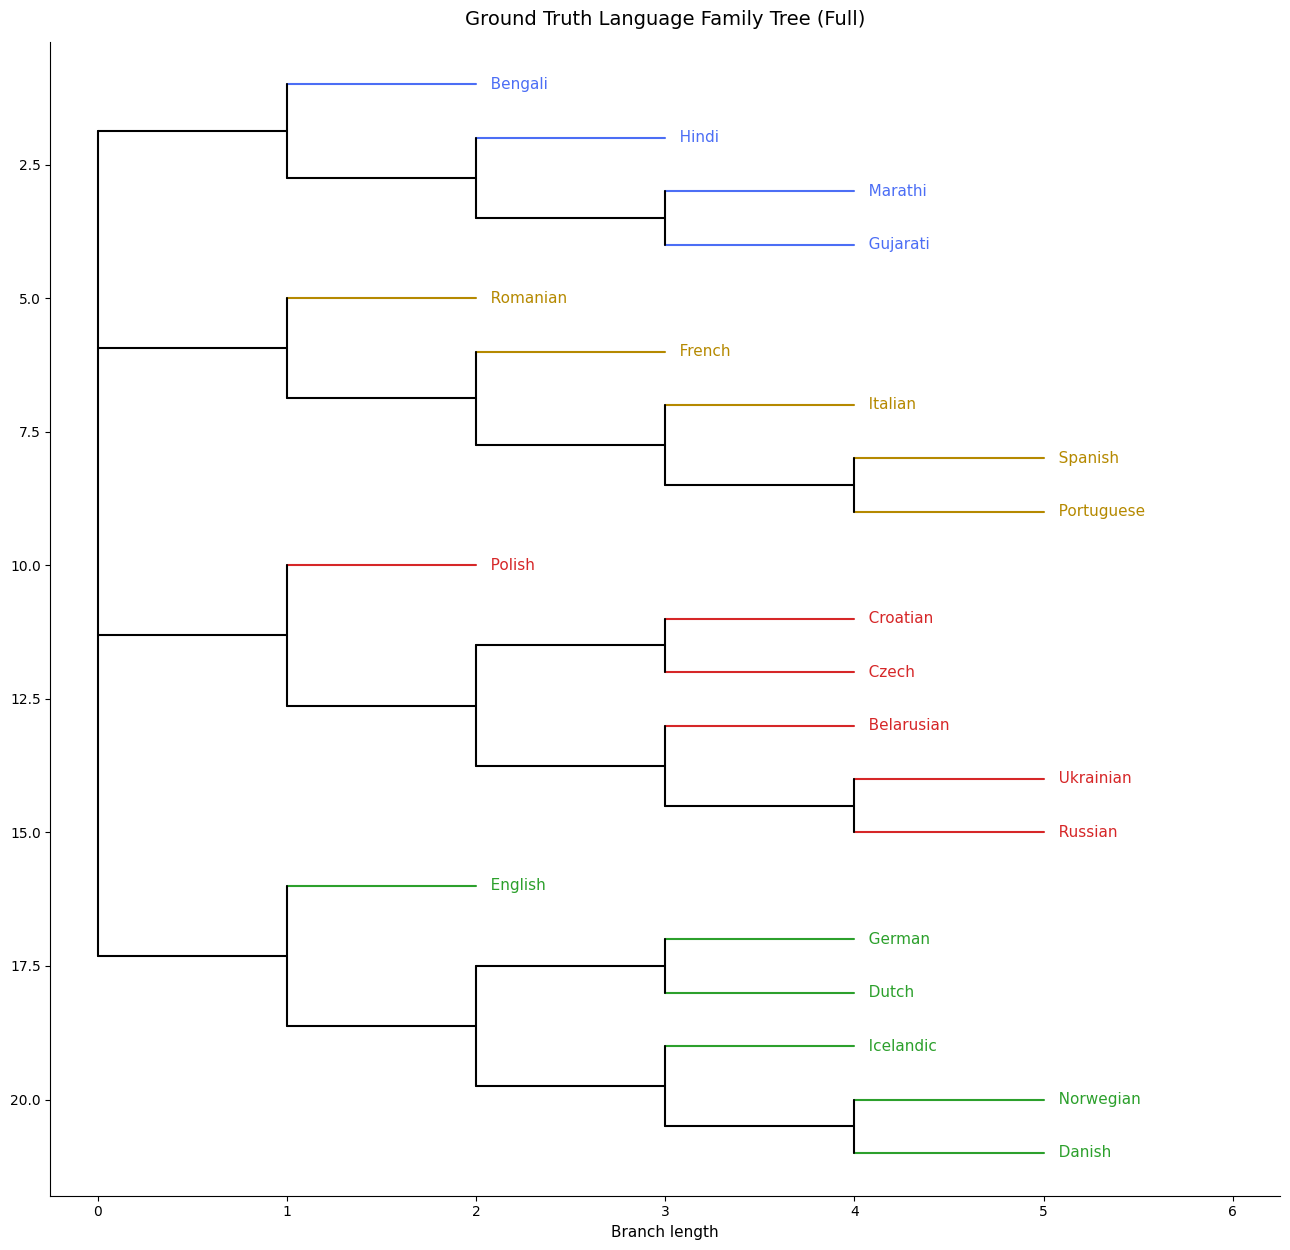

In [20]:
# ground truth generation
ground_truth_newick = """
(
    (Bengali,(Hindi,(Marathi,Gujarati))),
    (Polish,((Croatian,Czech),(Belarusian,(Ukrainian,Russian)))),
    (English,((Icelandic,(Norwegian,Danish)),(German,Dutch))),
    (Romanian,(French,(Italian,(Spanish,Portuguese))))
);
"""

ground_truth_tree = Phylo.read(StringIO(ground_truth_newick), "newick")
ground_truth_tree.ladderize()

draw_clean_tree(
    ground_truth_tree,
    "Ground Truth Language Family Tree (Full)",
    save_path="ground_truth_full.png"
)

## Analysis 

### 1) load UD data-set

In [21]:
language_sentences = load_ud_by_language(".")

print("Languages loaded:", list(language_sentences.keys()))
for lang, sents in language_sentences.items():
    print(f"  {lang}: {len(sents)} sentences")

Languages loaded: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian', 'Nepali']
  Ukrainian: 7092 sentences
  Polish: 22152 sentences
  Portuguese: 18714 sentences
  Croatian: 9010 sentences
  Italian: 14167 sentences
  Norwegian: 20044 sentences
  Spanish: 16014 sentences
  English: 33244 sentences
  Russian: 87337 sentences
  Czech: 222835 sentences
  Marathi: 1335 sentences
  Romanian: 9524 sentences
  Icelandic: 7168 sentences
  Hindi: 16649 sentences
  Bengali: 56 sentences
  German: 15589 sentences
  Danish: 5512 sentences
  Gujarati: 187 sentences
  French: 16342 sentences
  Dutch: 13603 sentences
  Belarusian: 25231 sentences
  Nepali: 0 sentences


###  Lexicalized Representations 
 

#### Word-length frequencies - frequencies of words with a given length.

Word-length features: ['len_1', 'len_2', 'len_3', 'len_4', 'len_5', 'len_6', 'len_7', 'len_8', 'len_9', 'len_10plus', 'mean_len']
Ukrainian (1, 11)
[[0.26893003 0.09773067 0.06647051 0.08927759 0.08695299 0.08648969
  0.0791664  0.06764907 0.05457117 0.10276188 4.72581117]]
Languages used: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian']

Cosine Similarity:
            Ukrainian  Polish  Portuguese  Croatian  Italian  Norwegian  \
Ukrainian       1.000   1.000       0.999     1.000    0.999      0.999   
Polish          1.000   1.000       0.999     1.000    0.999      0.999   
Portuguese      0.999   0.999       1.000     0.999    1.000      0.999   
Croatian        1.000   1.000       0.999     1.000    0.999      0.999   
Italian         0.999   0.999       1.000     0.999    1.000      0.999   
No

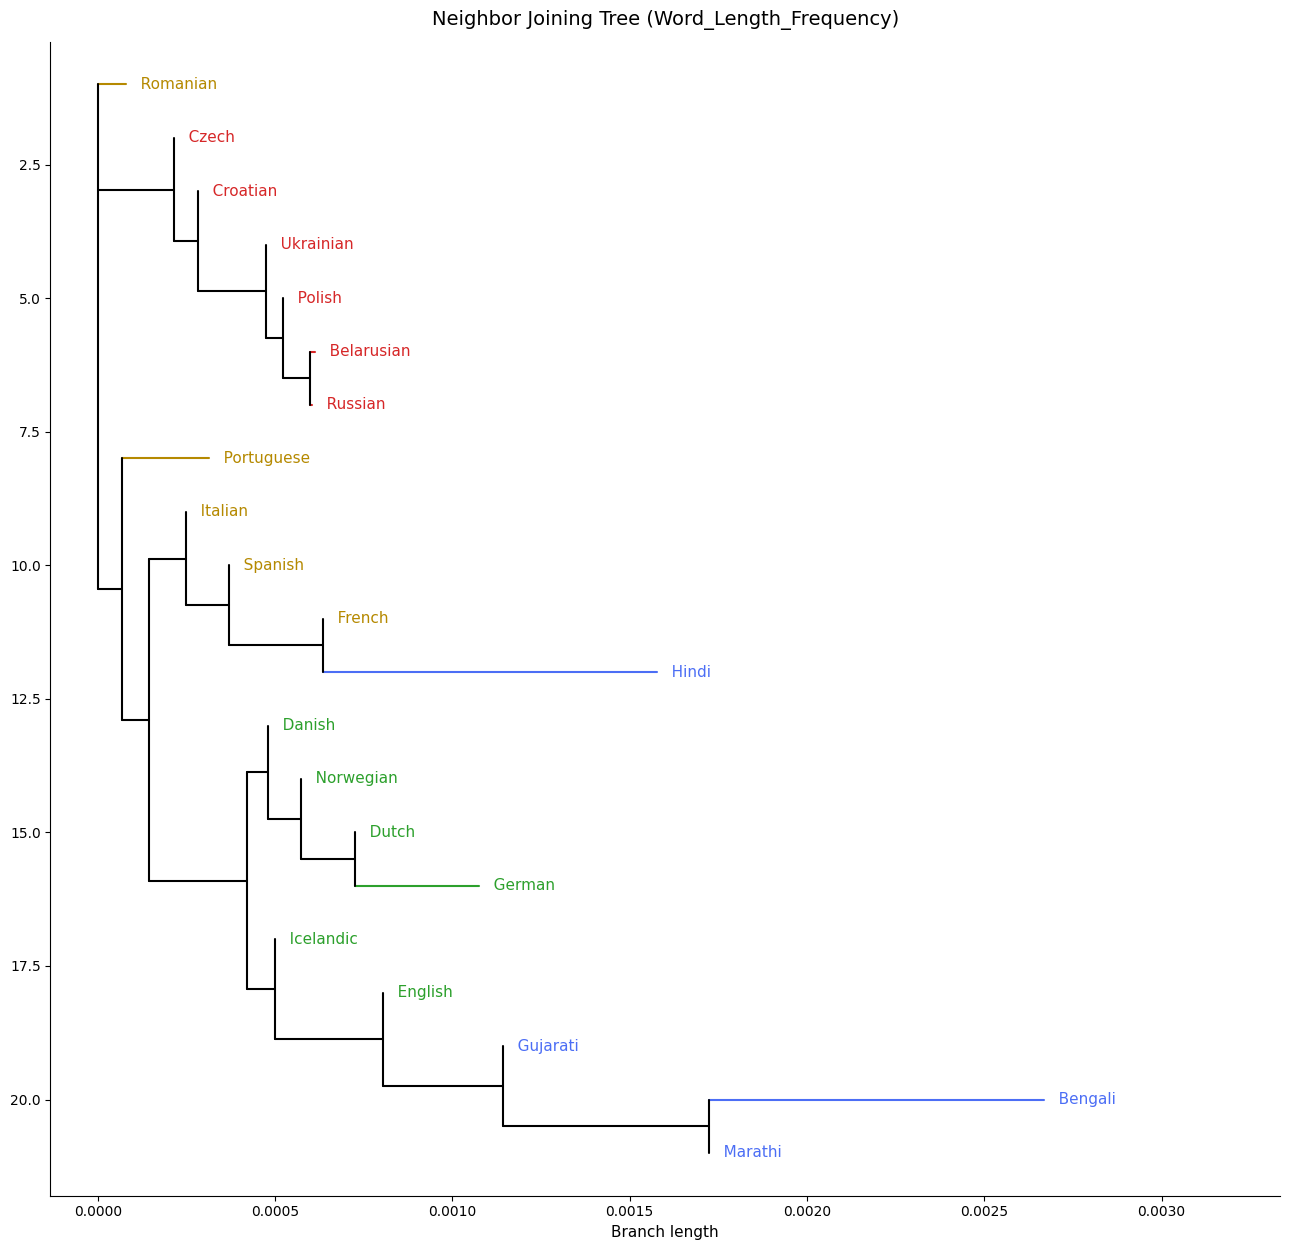

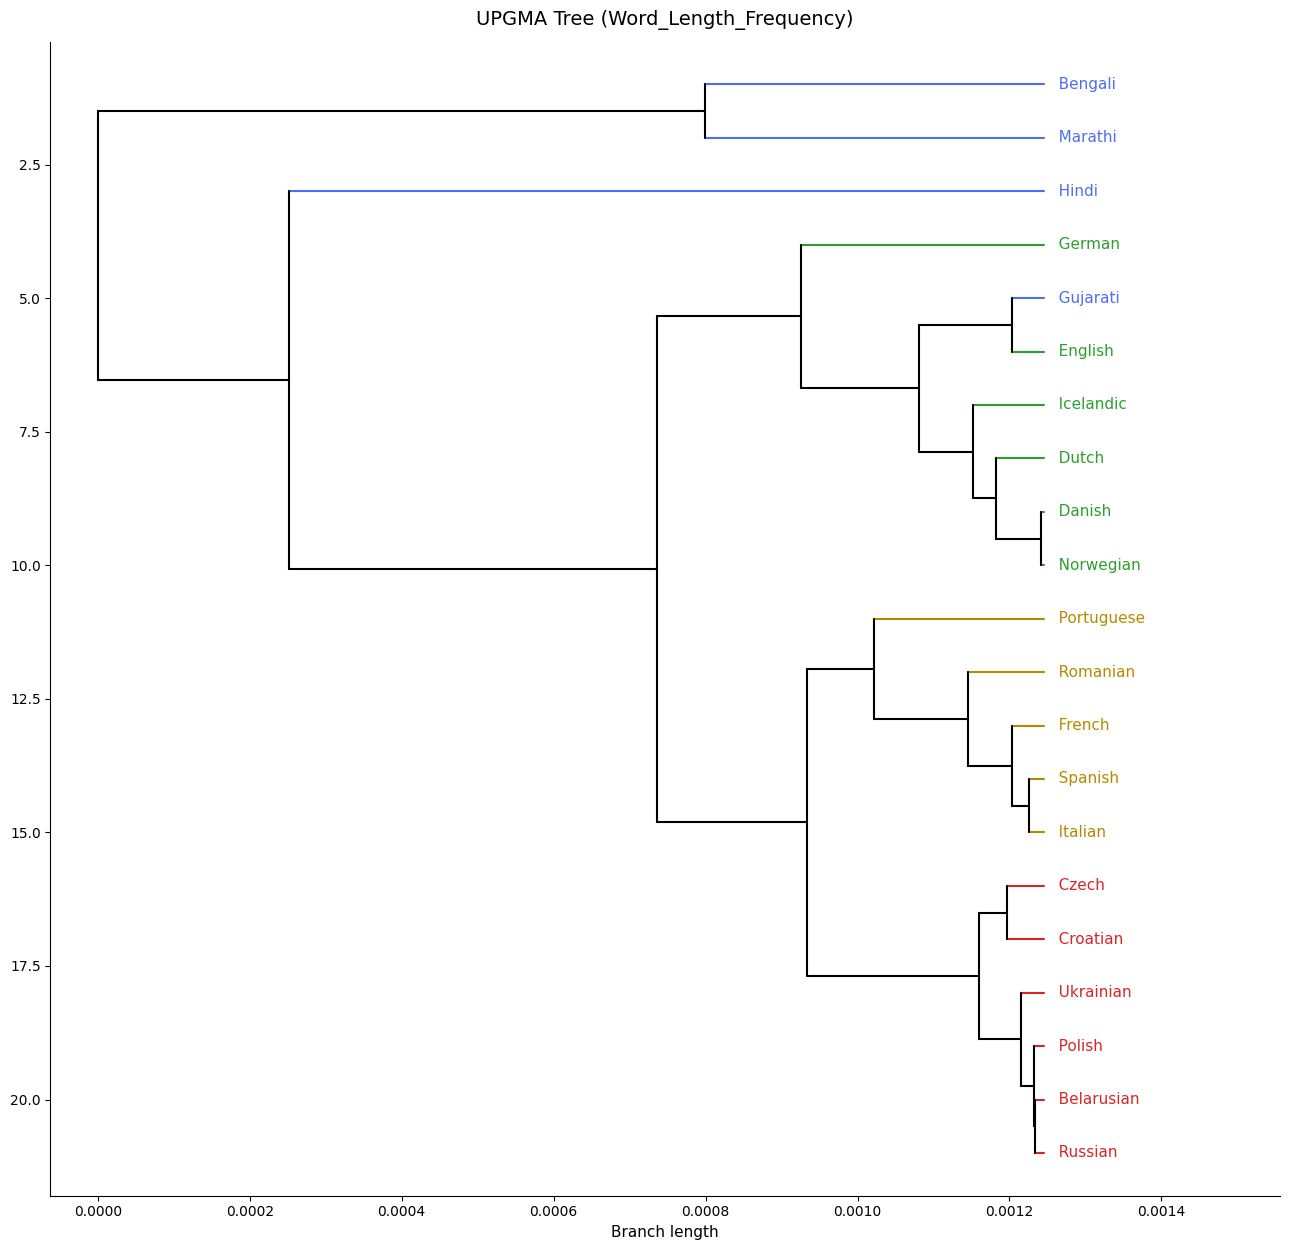

In [22]:
from collections import Counter

length_features = [
    "len_1",
    "len_2",
    "len_3",
    "len_4",
    "len_5",
    "len_6",
    "len_7",
    "len_8",
    "len_9",
    "len_10plus",
    "mean_len"
]

print("Word-length features:", length_features)

language_vectors_word_length = {}

for lang, sentences in language_sentences.items():
    counter = Counter()
    word_lengths = []

    for sentence in sentences:
        for word in sentence:
            if not word:
                continue

            length = len(word)
            word_lengths.append(length)

            if length == 1:
                counter["len_1"] += 1
            elif length == 2:
                counter["len_2"] += 1
            elif length == 3:
                counter["len_3"] += 1
            elif length == 4:
                counter["len_4"] += 1
            elif length == 5:
                counter["len_5"] += 1
            elif length == 6:
                counter["len_6"] += 1
            elif length == 7:
                counter["len_7"] += 1
            elif length == 8:
                counter["len_8"] += 1
            elif length == 9:
                counter["len_9"] += 1
            else:
                counter["len_10plus"] += 1

    total_words = len(word_lengths)

    vector = []
    for feat in length_features[:-1]:
        freq = counter[feat] / total_words if total_words > 0 else 0
        vector.append(freq)

    mean_len = np.mean(word_lengths) if total_words > 0 else 0
    vector.append(mean_len)

  
    language_vectors_word_length[lang] = np.array([vector])

for lang, vec in language_vectors_word_length.items():
    print(lang, vec.shape)
    print(vec)
    break

nj_tree_word_length, upgma_tree_word_length = build_tree_mean_cos_distance(language_vectors_word_length, method_name="Word_Length_Frequency")

#### Frequencies of the 50 most frequent words, by rank (Zipf's law).

Ukrainian (1, 50)
[[0.07995481 0.05293745 0.01819039 0.01531309 0.01282593 0.01215131
  0.01184245 0.01152546 0.01023311 0.00776221 0.00751837 0.0074696
  0.00702256 0.00600657 0.0056977  0.00566519 0.00512875 0.0050556
  0.00482801 0.00443787 0.00440536 0.00410462 0.00388517 0.00359256
  0.00349503 0.00333247 0.00329995 0.00321867 0.00318616 0.00303986
  0.00269036 0.00258469 0.00251154 0.00243839 0.00222706 0.00210514
  0.00201574 0.00200761 0.0019751  0.00195071 0.00181254 0.00180441
  0.00176377 0.00175564 0.001715   0.00166623 0.00157683 0.00147929
  0.00147929 0.00147929]]
Languages used: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian']

Cosine Similarity:
            Ukrainian  Polish  Portuguese  Croatian  Italian  Norwegian  \
Ukrainian       1.000   0.977       0.910     0.933    0.909      

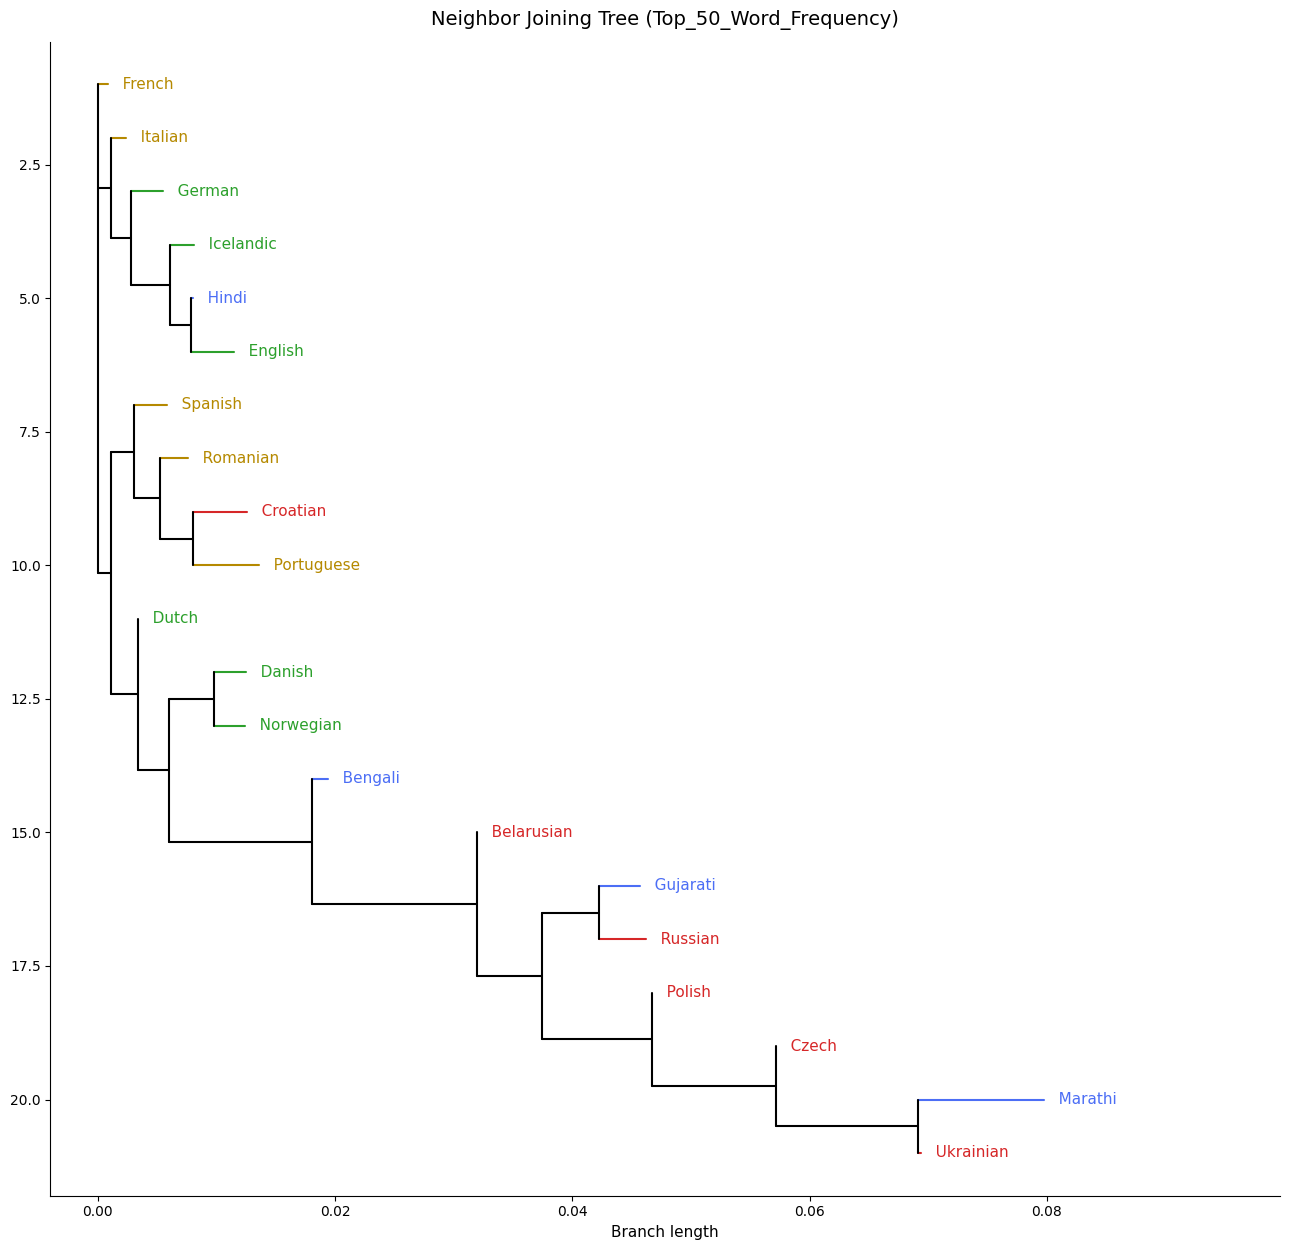

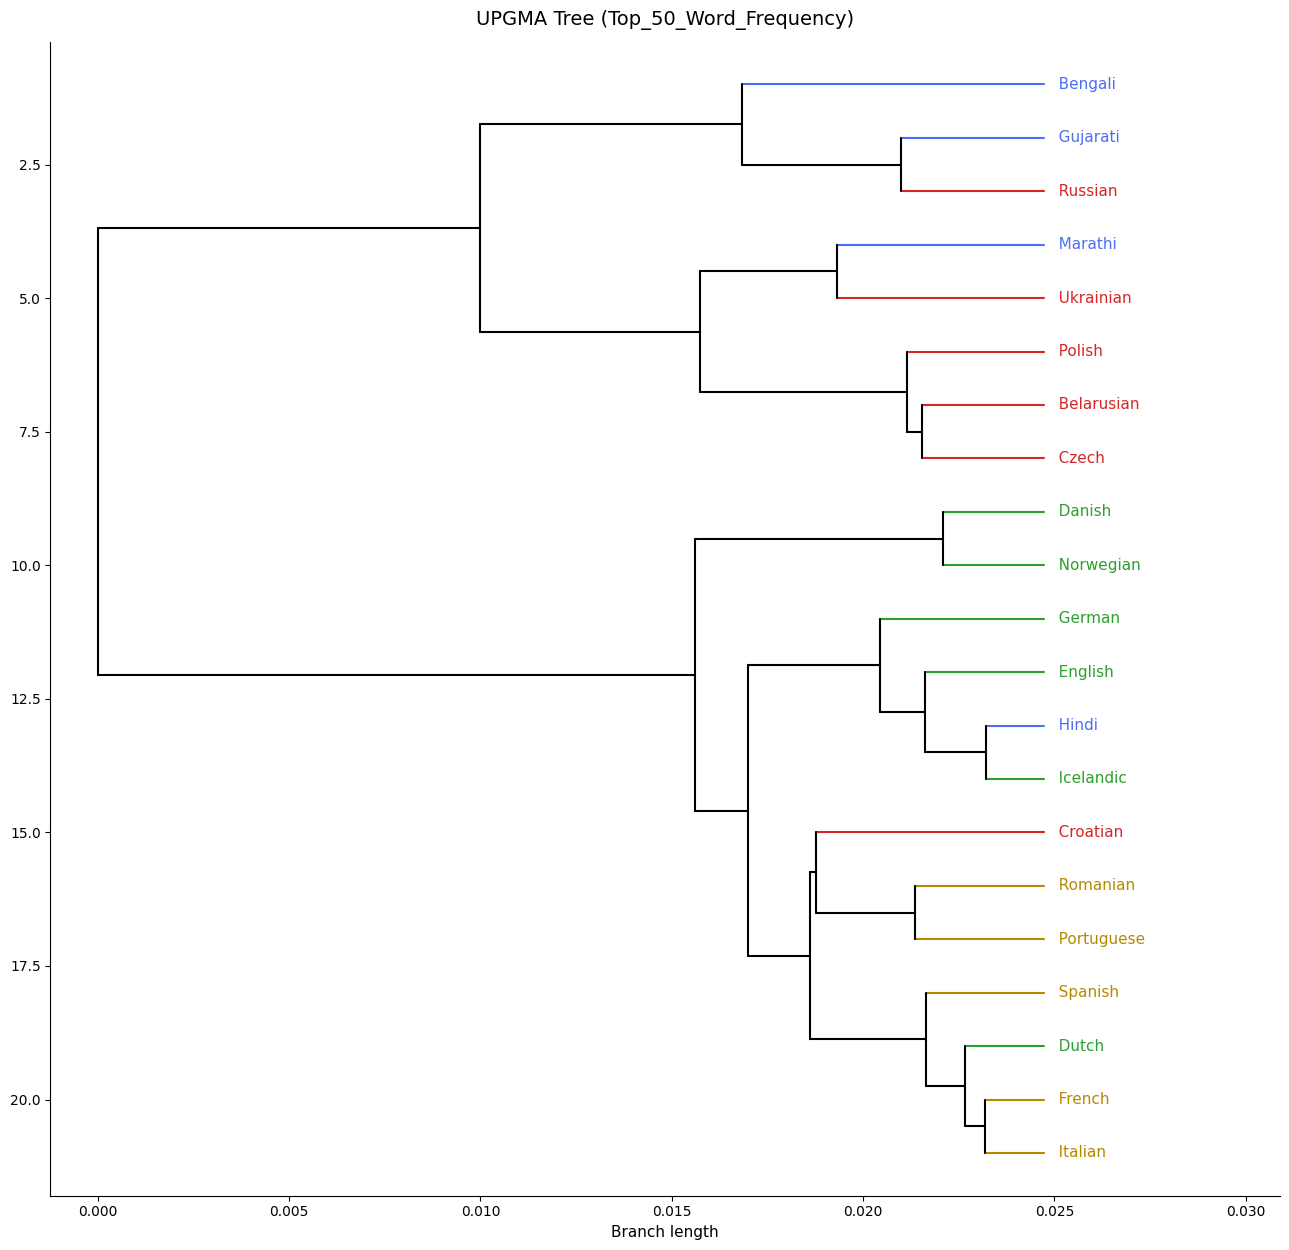

In [23]:
from collections import Counter
import numpy as np


language_vectors_top50_rankfreq = {}

for lang, sentences in language_sentences.items():
    counter = Counter()
    total_words = 0

    for sentence in sentences:
        counter.update(sentence)
        total_words += len(sentence)

    # get the 50 most frequent words for this language
    top_50 = counter.most_common(50)

    # convert counts to frequencies
    vector = []
    for word, count in top_50:
        freq = count / total_words if total_words > 0 else 0
        vector.append(freq)

    # if fewer than 50 words, pad with zeros
    while len(vector) < 50:
        vector.append(0)

   
    language_vectors_top50_rankfreq[lang] = np.array([vector])


for lang, vec in language_vectors_top50_rankfreq.items():
    print(lang, vec.shape)
    print(vec)
    break


nj_tree_top50, upgma_tree_top50 = build_tree_mean_cos_distance(language_vectors_top50_rankfreq, method_name="Top_50_Word_Frequency")

#### Overlap between the top 50 character trigrams for each language

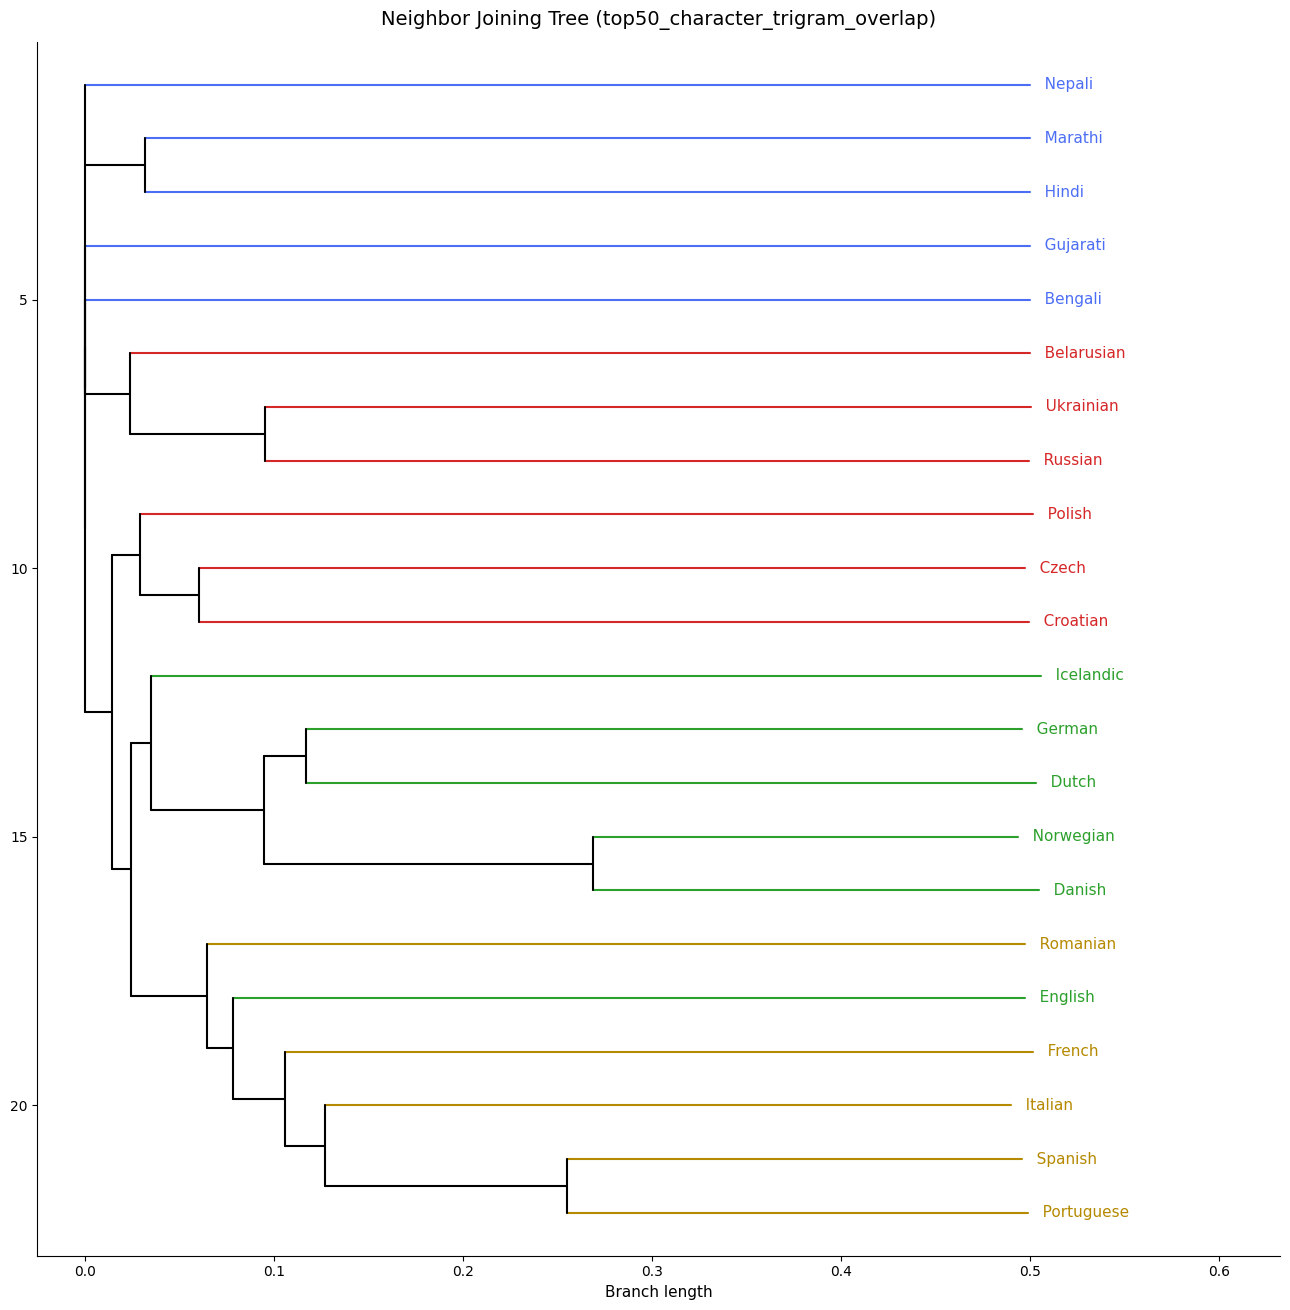

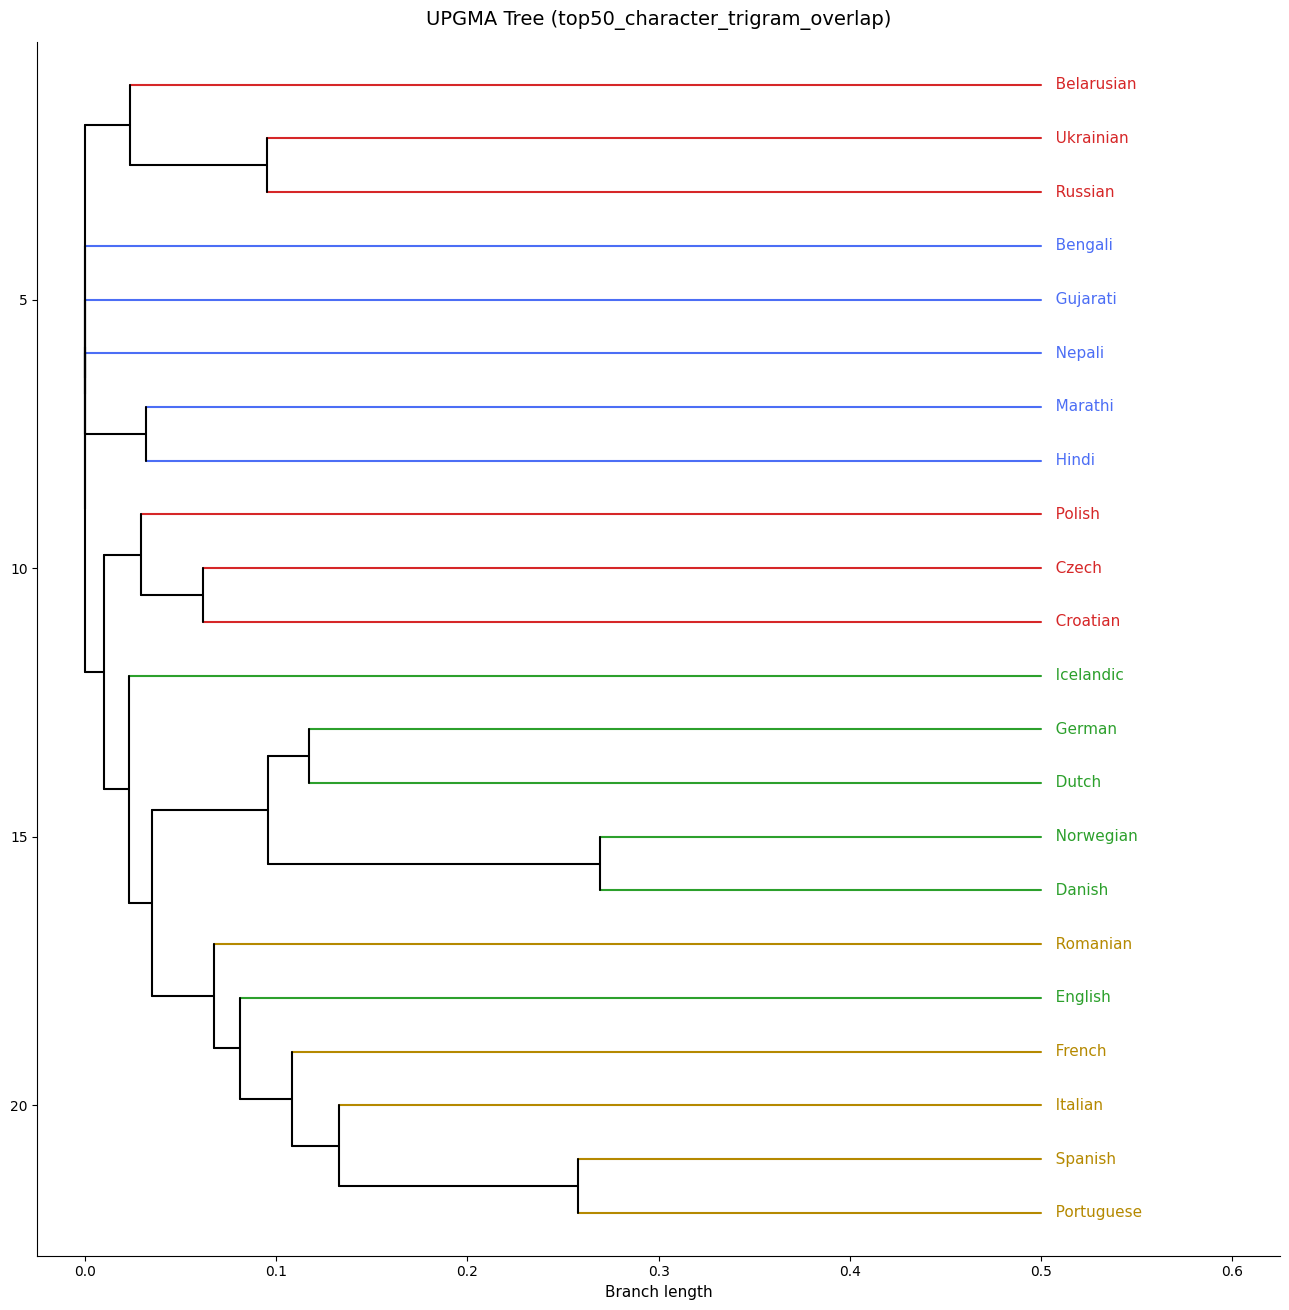

Saved NJ tree to: tree_outputs/top50_character_trigram_overlap/top50_character_trigram_overlap_nj.png
Saved UPGMA tree to: tree_outputs/top50_character_trigram_overlap/top50_character_trigram_overlap_upgma.png


In [24]:

def get_char_trigrams(word):
    if len(word) < 3:
        return []
    return [word[i:i+3] for i in range(len(word) - 2)]



language_top50_trigrams = {}

for lang, sentences in language_sentences.items():
    trigram_counter = Counter()

    for sentence in sentences:
        for word in sentence:
            trigram_counter.update(get_char_trigrams(word))

    top_50 = [trigram for trigram, count in trigram_counter.most_common(50)]
    language_top50_trigrams[lang] = set(top_50)



dist_df_trigram_overlap = build_jaccard_distance_df(language_top50_trigrams)

dist_df_trigram_overlap.head()

nj_tree_trigram_overlap, upgma_tree_trigram_overlap = build_tree_from_distance_df(
    dist_df_trigram_overlap,
    method_name="top50_character_trigram_overlap"
)

#### Multilingual Word2Vec Embeddings

In [25]:
from gensim.models import Word2Vec

all_sentences = []
for sentences in language_sentences.values():
    all_sentences.extend(sentences)

model_word2vec = Word2Vec(
    all_sentences,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'
Exception ignored in: 'gensim.models.word2vec_inner.our_dot_float'


In [26]:
import numpy as np

language_vectors_word2vec = {}

for lang, sentences in language_sentences.items():
    vectors = []

    for sentence in sentences:
        for word in sentence:
            if word in model_word2vec.wv:
                vectors.append(model_word2vec.wv[word])

    language_vectors_word2vec[lang] = np.array(vectors)

In [27]:
for lang, vecs in language_vectors_word2vec.items():
    print(f"{lang}: {vecs.shape}")

Ukrainian: (103996, 100)
Polish: (317367, 100)
Portuguese: (489390, 100)
Croatian: (181101, 100)
Italian: (307160, 100)
Norwegian: (294841, 100)
Spanish: (419463, 100)
English: (516376, 100)
Russian: (1446864, 100)
Czech: (3628034, 100)
Marathi: (11767, 100)
Romanian: (203577, 100)
Icelandic: (162493, 100)
Hindi: (343675, 100)
Bengali: (231, 100)
German: (269087, 100)
Danish: (92365, 100)
Gujarati: (1154, 100)
French: (392210, 100)
Dutch: (195290, 100)
Belarusian: (276453, 100)
Nepali: (0,)


Languages used: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian']

Cosine Similarity:
            Ukrainian  Polish  Portuguese  Croatian  Italian  Norwegian  \
Ukrainian       1.000   0.353       0.198     0.157    0.185      0.244   
Polish          0.353   1.000       0.381     0.758    0.271      0.384   
Portuguese      0.198   0.381       1.000     0.448    0.548      0.295   
Croatian        0.157   0.758       0.448     1.000    0.407      0.338   
Italian         0.185   0.271       0.548     0.407    1.000      0.345   
Norwegian       0.244   0.384       0.295     0.338    0.345      1.000   
Spanish         0.172   0.143       0.797     0.282    0.640      0.290   
English         0.205   0.470       0.418     0.473    0.463      0.573   
Russian         0.767   0.218       0.134     0.158 

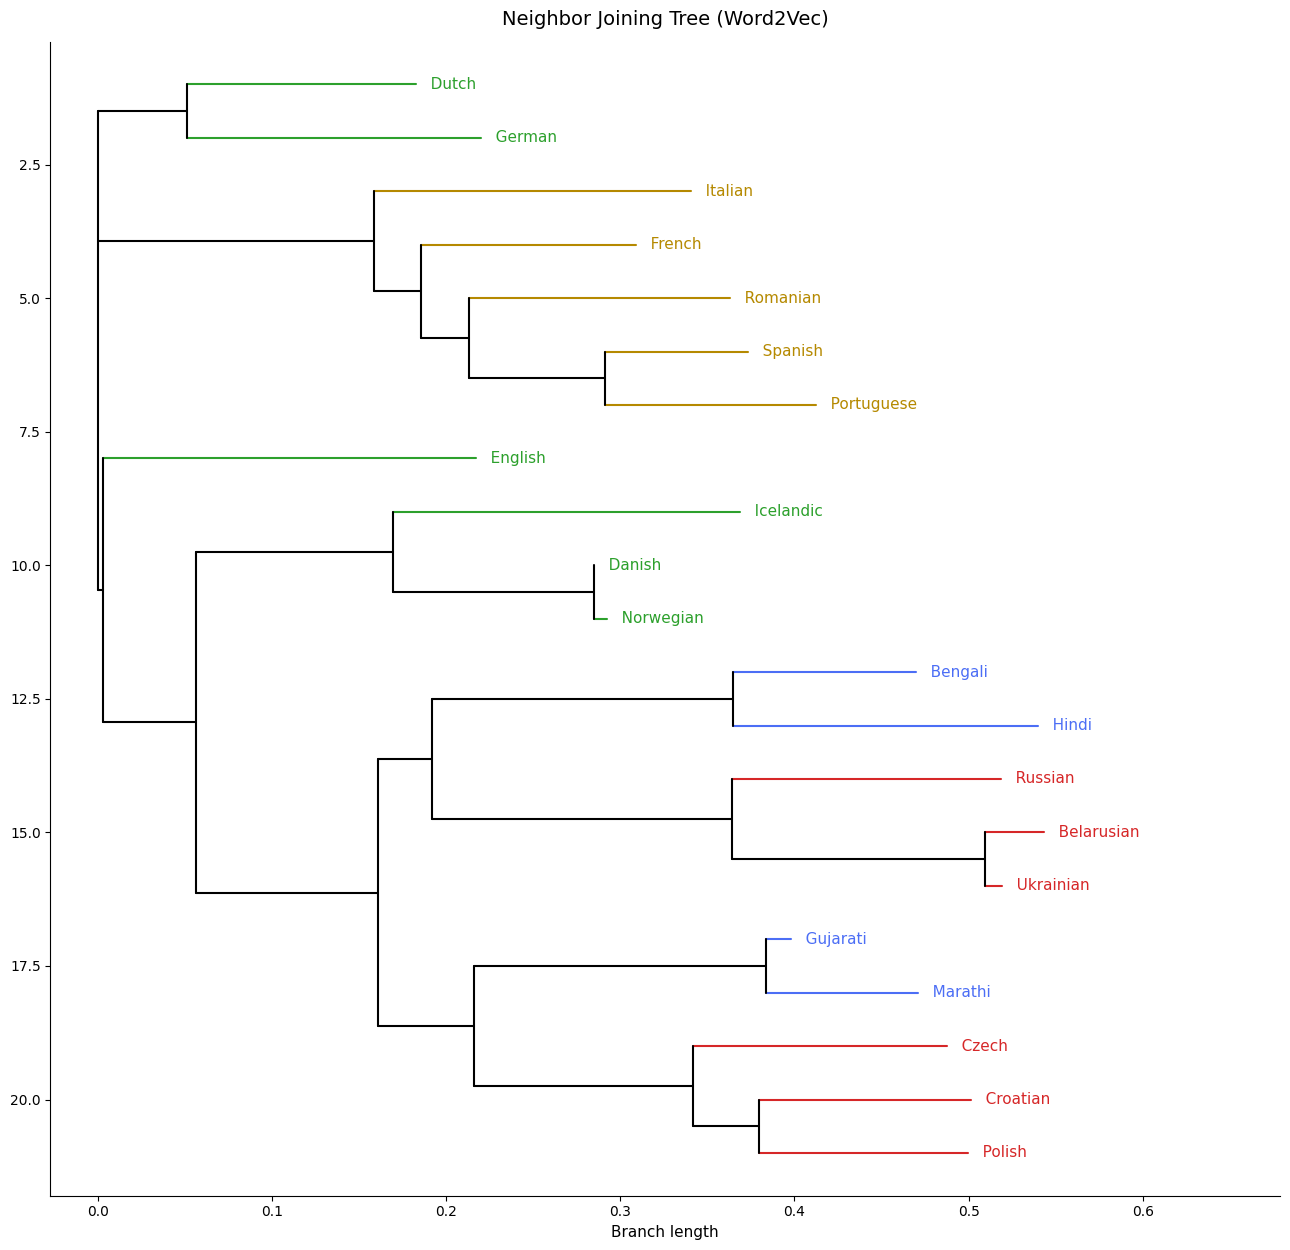

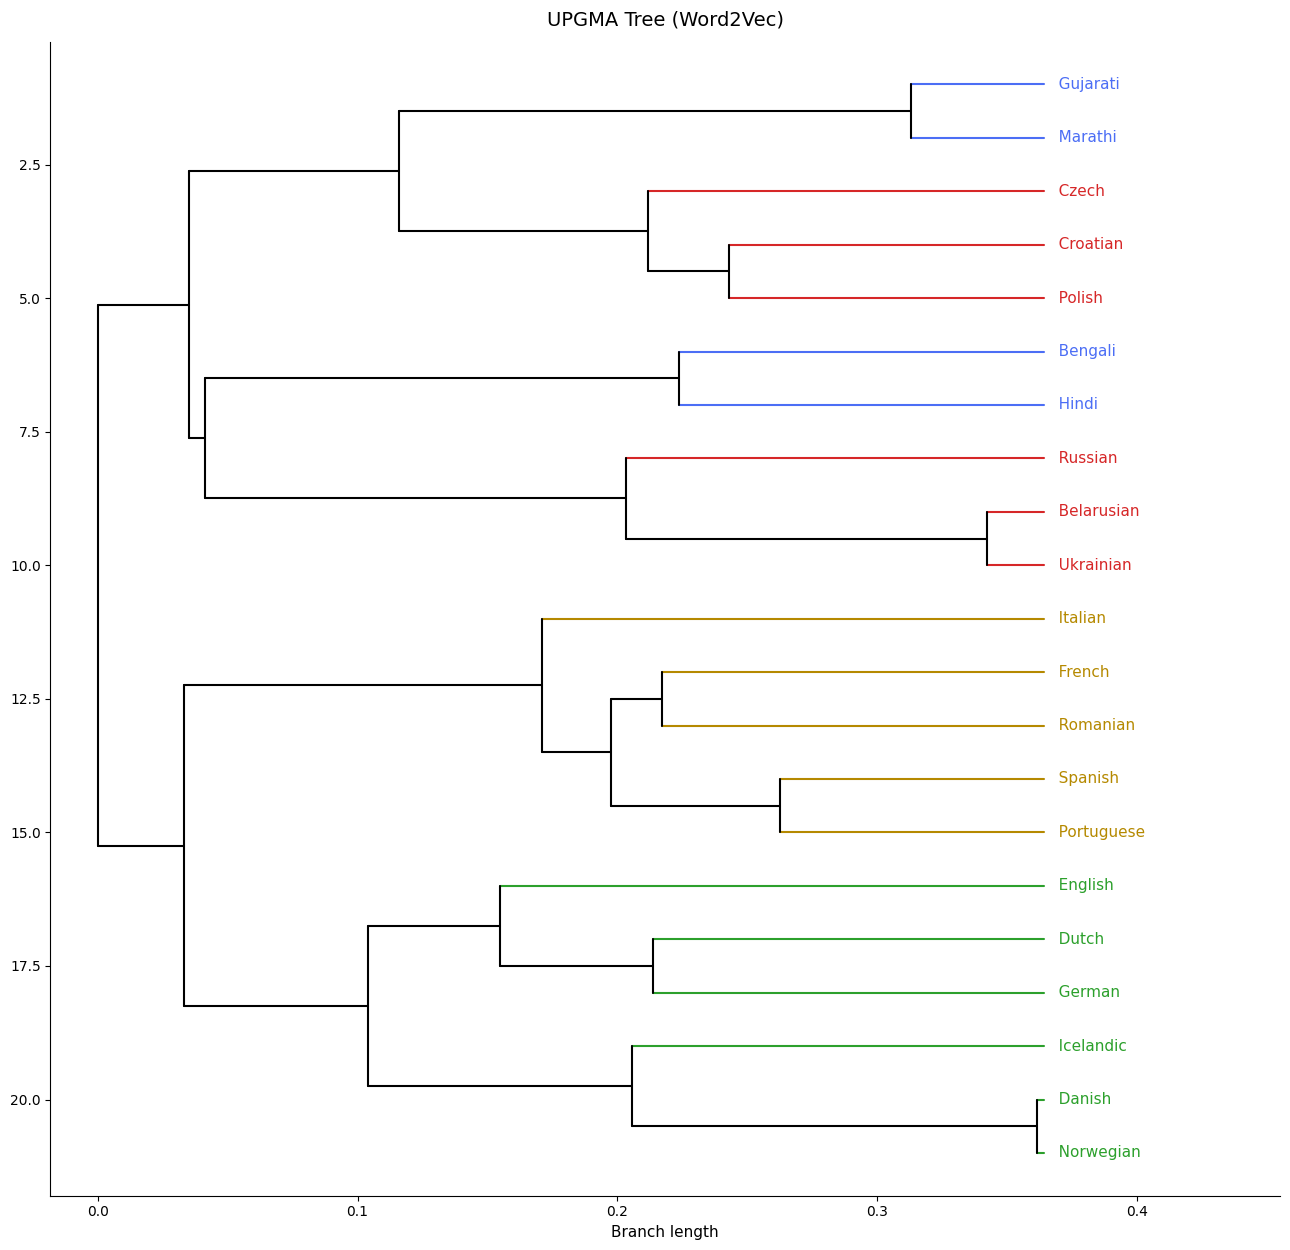

In [28]:
nj_tree_word2vec, upgma_tree_word2vec = build_tree_mean_cos_distance(language_vectors_word2vec, method_name="Word2Vec")

#### Word2Vec with PCA

Languages used: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian']

Cosine Similarity:
            Ukrainian  Polish  Portuguese  Croatian  Italian  Norwegian  \
Ukrainian       1.000   0.154      -0.242    -0.048   -0.306     -0.249   
Polish          0.154   1.000       0.007     0.656   -0.211     -0.038   
Portuguese     -0.242   0.007       1.000     0.067    0.186     -0.277   
Croatian       -0.048   0.656       0.067     1.000   -0.014     -0.113   
Italian        -0.306  -0.211       0.186    -0.014    1.000     -0.162   
Norwegian      -0.249  -0.038      -0.277    -0.113   -0.162      1.000   
Spanish        -0.321  -0.404       0.633    -0.199    0.362     -0.293   
English        -0.253   0.069      -0.046     0.120    0.008      0.169   
Russian         0.684  -0.048      -0.318    -0.044 

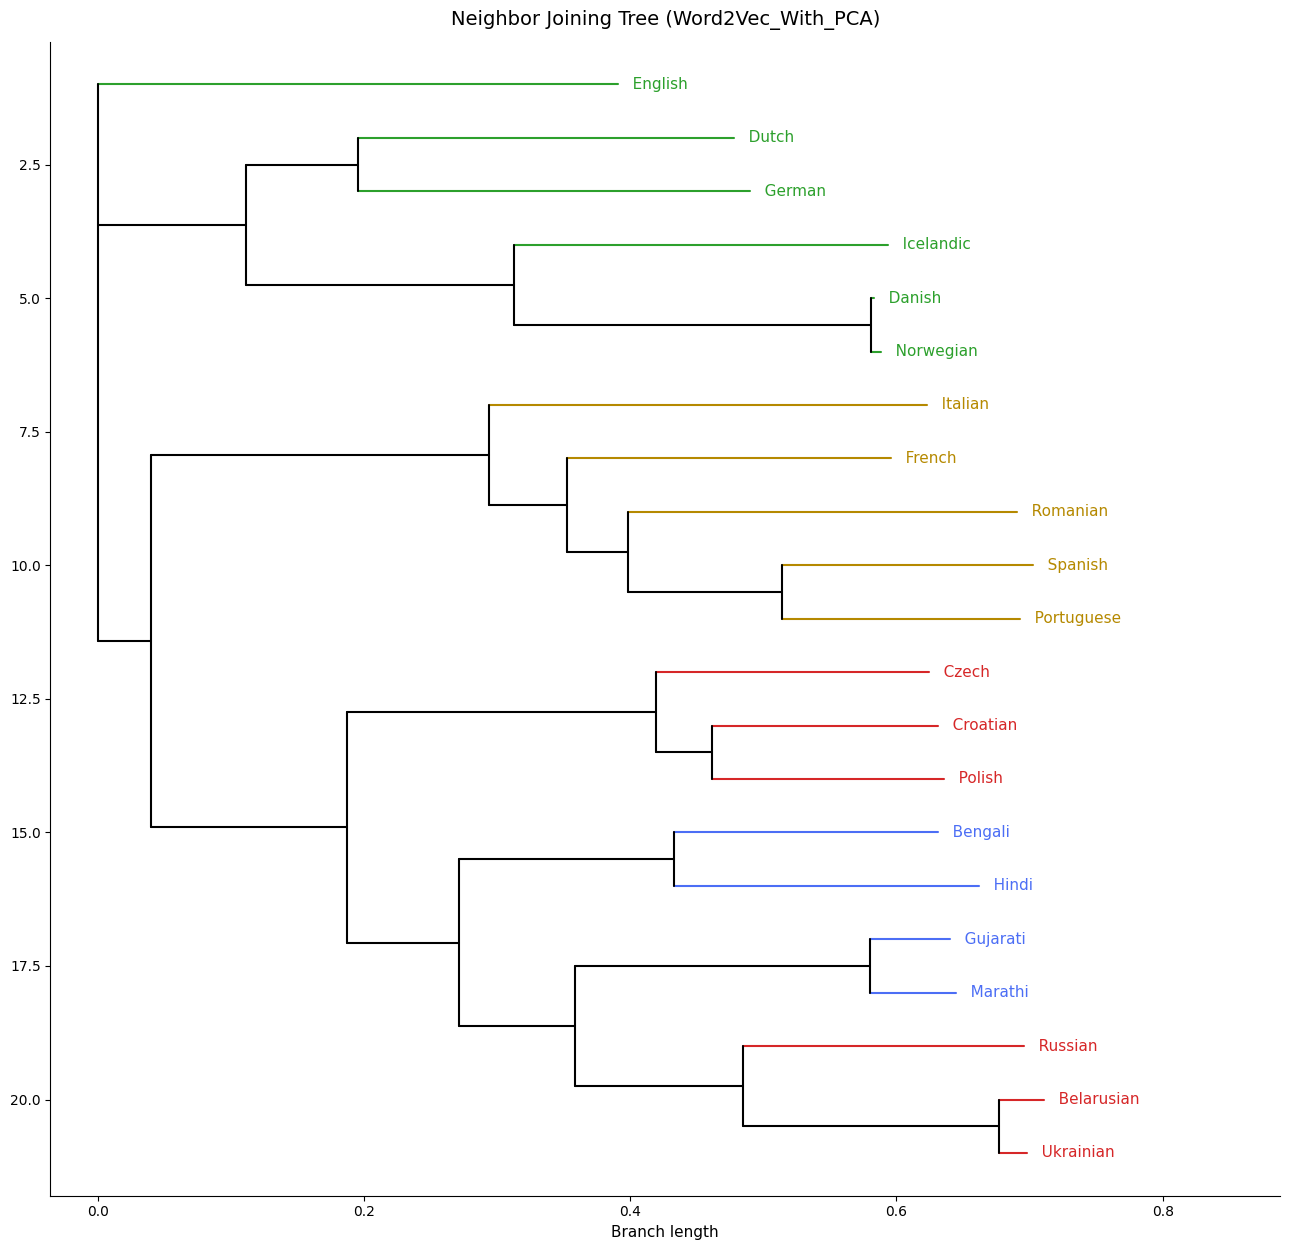

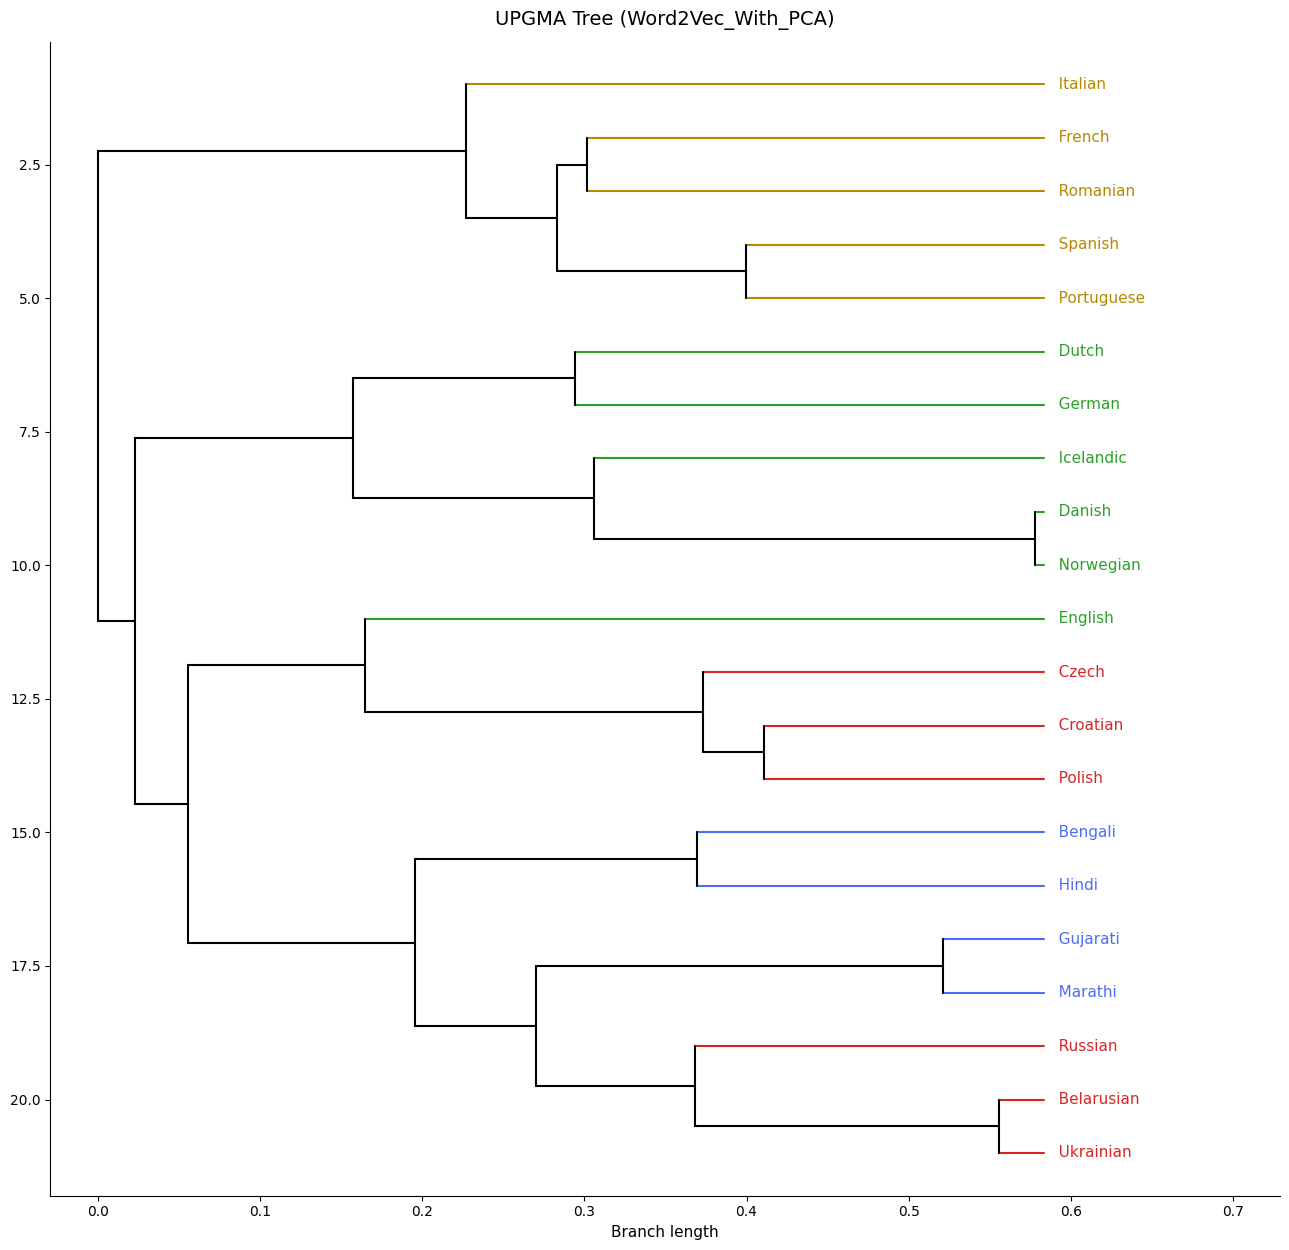

In [29]:
lang_word2vec_pca_vectors, _, _ = compute_language_pca_vectors_sampled(language_vectors_word2vec)
nj_tree_pca, upgma_tree_pca = build_tree_mean_cos_distance(lang_word2vec_pca_vectors, method_name="Word2Vec_With_PCA")

In [30]:
# compare with ground truth
result_nj_gt = compare_trees(nj_tree_pca, ground_truth_tree)
result_upgma_gt = compare_trees(upgma_tree_pca, ground_truth_tree)

print("=== NJ vs Ground Truth ===")
print("Shared leaves:", result_nj_gt["shared_leaves"])
print("RF distance:", result_nj_gt["rf_distance"])
print("Normalized RF:", result_nj_gt["normalized_rf"])
print("Shared splits:", result_nj_gt["shared_splits"])
print("Only in NJ:", result_nj_gt["only_in_tree1"])
print("Only in Ground Truth:", result_nj_gt["only_in_tree2"])

print("\n=== UPGMA vs Ground Truth ===")
print("Shared leaves:", result_upgma_gt["shared_leaves"])
print("RF distance:", result_upgma_gt["rf_distance"])
print("Normalized RF:", result_upgma_gt["normalized_rf"])
print("Shared splits:", result_upgma_gt["shared_splits"])
print("Only in UPGMA:", result_upgma_gt["only_in_tree1"])
print("Only in Ground Truth:", result_upgma_gt["only_in_tree2"])

=== NJ vs Ground Truth ===
Shared leaves: ['Belarusian', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English', 'French', 'German', 'Gujarati', 'Hindi', 'Icelandic', 'Italian', 'Marathi', 'Norwegian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Spanish', 'Ukrainian']
RF distance: 17
Normalized RF: 0.4857142857142857
Shared splits: {frozenset({'Gujarati', 'Marathi'}), frozenset({'Spanish', 'Portuguese'}), frozenset({'Icelandic', 'Dutch', 'Norwegian', 'English', 'Danish', 'German'}), frozenset({'Icelandic', 'Dutch', 'Norwegian', 'Danish', 'German'}), frozenset({'Dutch', 'German'}), frozenset({'Norwegian', 'Danish'}), frozenset({'Russian', 'Belarusian', 'Ukrainian'}), frozenset({'Romanian', 'Spanish', 'French', 'Portuguese', 'Italian'}), frozenset({'Norwegian', 'Icelandic', 'Danish'})}
Only in NJ: {frozenset({'Belarusian', 'Ukrainian'}), frozenset({'French', 'Portuguese', 'Romanian', 'Spanish'}), frozenset({'Hindi', 'Bengali'}), frozenset({'Romanian', 'Portuguese', 'Spanish'}),

#### Unaligned FastText:


Sampling sentences for training...
  Ukrainian: Using 3,000 / 7,092 sentences
  Polish: Using 3,000 / 22,152 sentences
  Portuguese: Using 3,000 / 18,714 sentences
  Croatian: Using 3,000 / 9,010 sentences
  Italian: Using 3,000 / 14,167 sentences
  Norwegian: Using 3,000 / 20,044 sentences
  Spanish: Using 3,000 / 16,014 sentences
  English: Using 3,000 / 33,244 sentences
  Russian: Using 3,000 / 87,337 sentences
  Czech: Using 3,000 / 222,835 sentences
  Marathi: Using all 1,335 sentences
  Romanian: Using 3,000 / 9,524 sentences
  Icelandic: Using 3,000 / 7,168 sentences
  Hindi: Using 3,000 / 16,649 sentences
  Bengali: Using all 56 sentences
  German: Using 3,000 / 15,589 sentences
  Danish: Using 3,000 / 5,512 sentences
  Gujarati: Using all 187 sentences
  French: Using 3,000 / 16,342 sentences
  Dutch: Using 3,000 / 13,603 sentences
  Belarusian: Using 3,000 / 25,231 sentences
  Nepali: Using all 0 sentences

Total training sentences: 55,578
Training FastText (1-2 minutes)...



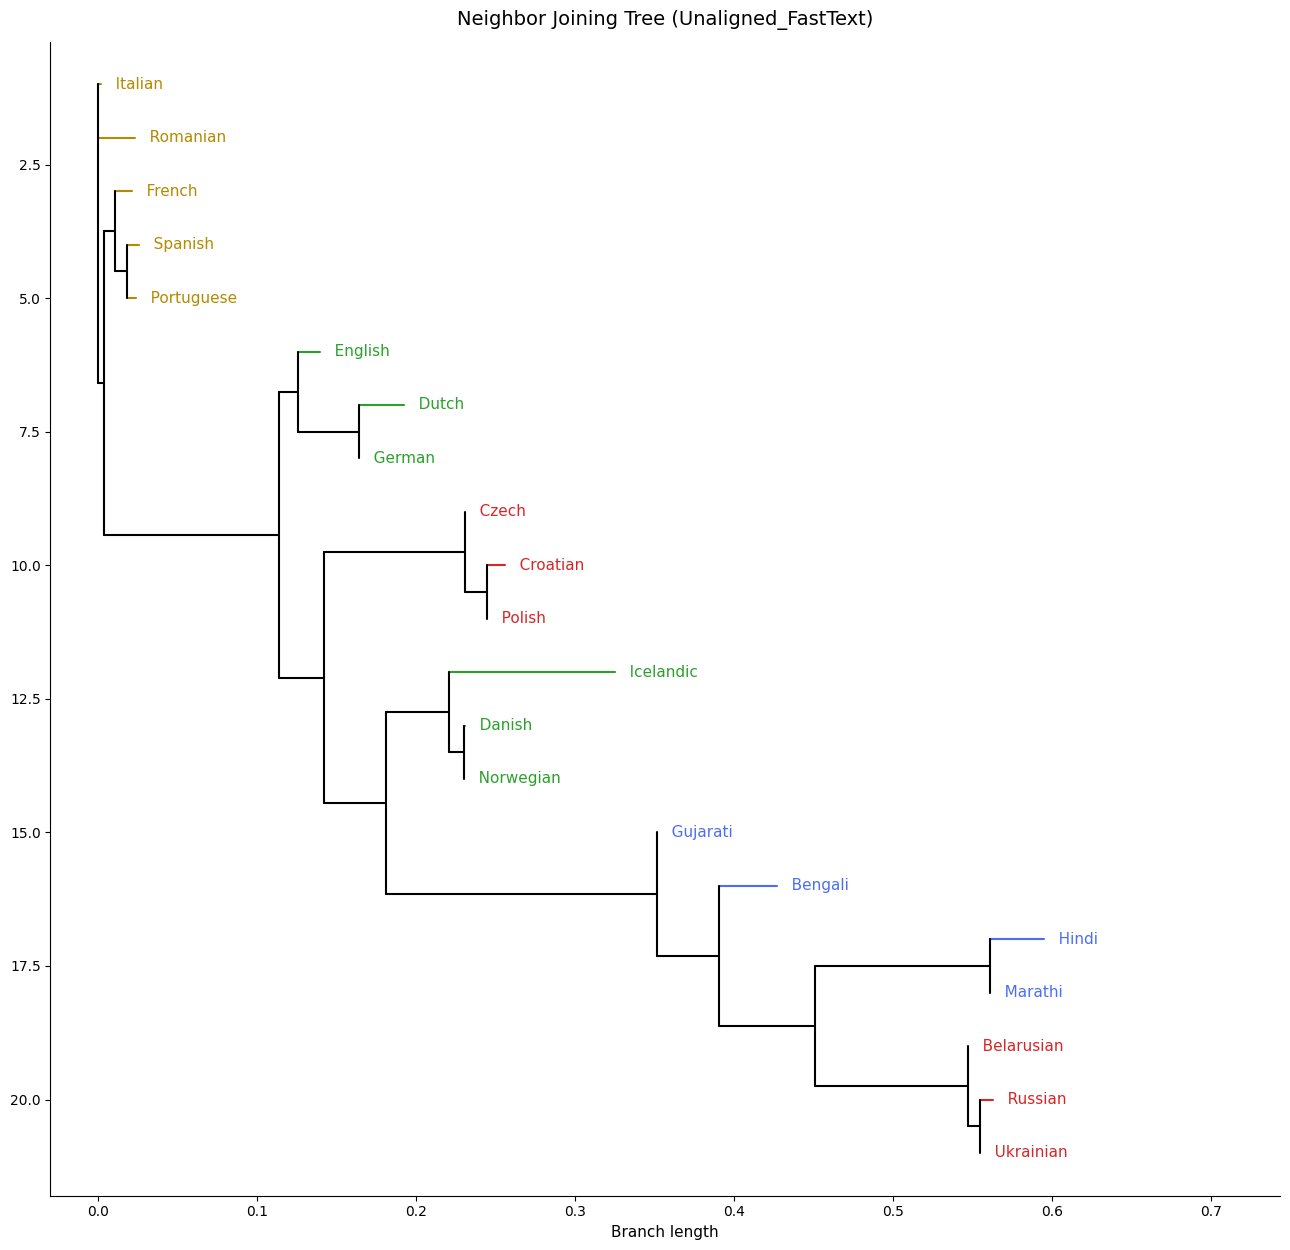

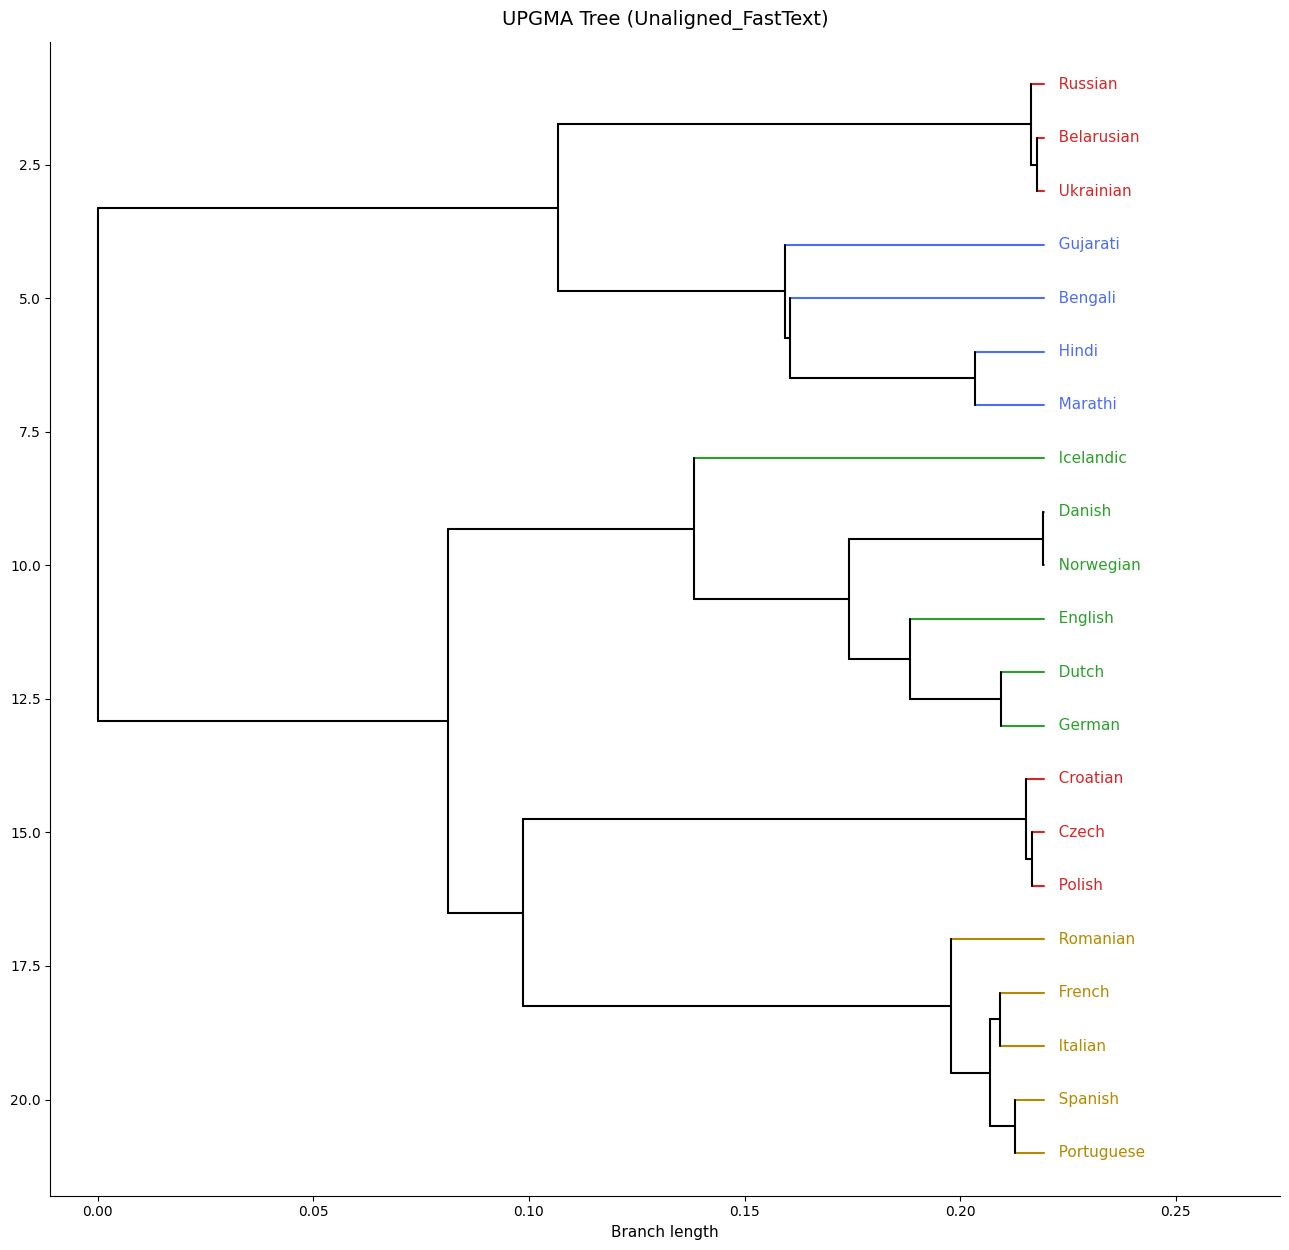

Trees built successfully!


In [31]:

unaligned_fasttext_model = train_fasttext(
    language_sentences,
    max_sentences_per_lang=3000  
)

# Extract language vectors (sampled)
language_vectors_unaligned_fasttext = get_unaligned_vectors(
    language_sentences,
    unaligned_fasttext_model,
    max_words=20000
)

# Build trees
if len(language_vectors_unaligned_fasttext) > 0:
    nj_tree_unaligned_ft, upgma_tree_unaligned_ft = build_tree_mean_cos_distance(language_vectors_unaligned_fasttext, method_name = "Unaligned_FastText")
    print("Trees built successfully!")
else:
    print("No vectors to build trees from")

### Delexicalized representations

#### Load data 

In [32]:
language_structures = load_ud_structure_by_language(ud_path)

first_sentences = {
    lang: sentences[0]
    for lang, sentences in language_structures.items()
    if sentences
}

In [33]:
print(first_sentences["Ukrainian"])

[{'id': 1, 'form': 'Дідусь', 'lemma': 'дідусь', 'upos': 'NOUN', 'xpos': 'Ncmsny', 'feats': {'Animacy': 'Anim', 'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Sing'}, 'head': 7, 'deprel': 'nsubj', 'deps': [('nsubj', 7), ('nsubj', 9)]}, {'id': 2, 'form': ',', 'lemma': ',', 'upos': 'PUNCT', 'xpos': 'U', 'feats': None, 'head': 3, 'deprel': 'punct', 'deps': [('punct', 3)]}, {'id': 3, 'form': 'той', 'lemma': 'той', 'upos': 'DET', 'xpos': 'Pd--m-sna', 'feats': {'Case': 'Nom', 'Gender': 'Masc', 'Number': 'Sing', 'PronType': 'Dem'}, 'head': 7, 'deprel': 'dislocated', 'deps': [('nsubj', 5), ('dislocated', 7), ('dislocated', 9)]}, {'id': 4, 'form': 'що', 'lemma': 'що', 'upos': 'SCONJ', 'xpos': 'Css', 'feats': None, 'head': 5, 'deprel': 'mark', 'deps': [('mark', 5)]}, {'id': 5, 'form': 'атестував', 'lemma': 'атестувати', 'upos': 'VERB', 'xpos': 'Vmpis-sm', 'feats': {'Aspect': 'Imp', 'Gender': 'Masc', 'Mood': 'Ind', 'Number': 'Sing', 'Tense': 'Past', 'VerbForm': 'Fin'}, 'head': 3, 'deprel': 'acl:relcl

#### Feature Extractions (POS-TAG FREQUENCIES)

In [34]:
from collections import Counter
import numpy as np


all_upos = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            if token.get("upos") is not None:
                all_upos.add(token["upos"])

# sort to fix feature order
all_upos = sorted(all_upos)

print("POS features:", all_upos)



language_vectors_pos = {}

for lang, sentences in language_structures.items():
    pos_counter = Counter()
    total_tokens = 0

    for sentence in sentences:
        for token in sentence:
            upos = token.get("upos")
            if upos is not None:
                pos_counter[upos] += 1
                total_tokens += 1

    # build vector in SAME ORDER for all languages
    vector = []
    for tag in all_upos:
        freq = pos_counter[tag] / total_tokens if total_tokens > 0 else 0
        vector.append(freq)

   
    language_vectors_pos[lang] = np.array([vector])



for lang, vec in language_vectors_pos.items():
    print(lang, vec.shape)
    print(vec)
    break

POS features: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'None', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', '_']
Belarusian (1, 19)
[[0.08789318 0.09724721 0.03617724 0.00682707 0.02950093 0.02206097
  0.00029498 0.23826239 0.01916037 0.         0.01601723 0.03383053
  0.06680563 0.18686764 0.01115011 0.00856087 0.10187507 0.03746858
  0.        ]]


Languages used: ['Belarusian', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English', 'French', 'German', 'Gujarati', 'Hindi', 'Icelandic', 'Italian', 'Marathi', 'Norwegian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Spanish', 'Ukrainian']

Cosine Similarity:
            Belarusian  Bengali  Croatian  Czech  Danish  Dutch  English  \
Belarusian       1.000    0.849     0.958  0.980   0.947  0.891    0.916   
Bengali          0.849    1.000     0.776  0.836   0.861  0.791    0.874   
Croatian         0.958    0.776     1.000  0.986   0.949  0.915    0.935   
Czech            0.980    0.836     0.986  1.000   0.967  0.922    0.945   
Danish           0.947    0.861     0.949  0.967   1.000  0.967    0.979   
Dutch            0.891    0.791     0.915  0.922   0.967  1.000    0.973   
English          0.916    0.874     0.935  0.945   0.979  0.973    1.000   
French           0.869    0.714     0.890  0.897   0.925  0.980    0.928   
German           0.895    0.745     0.912  

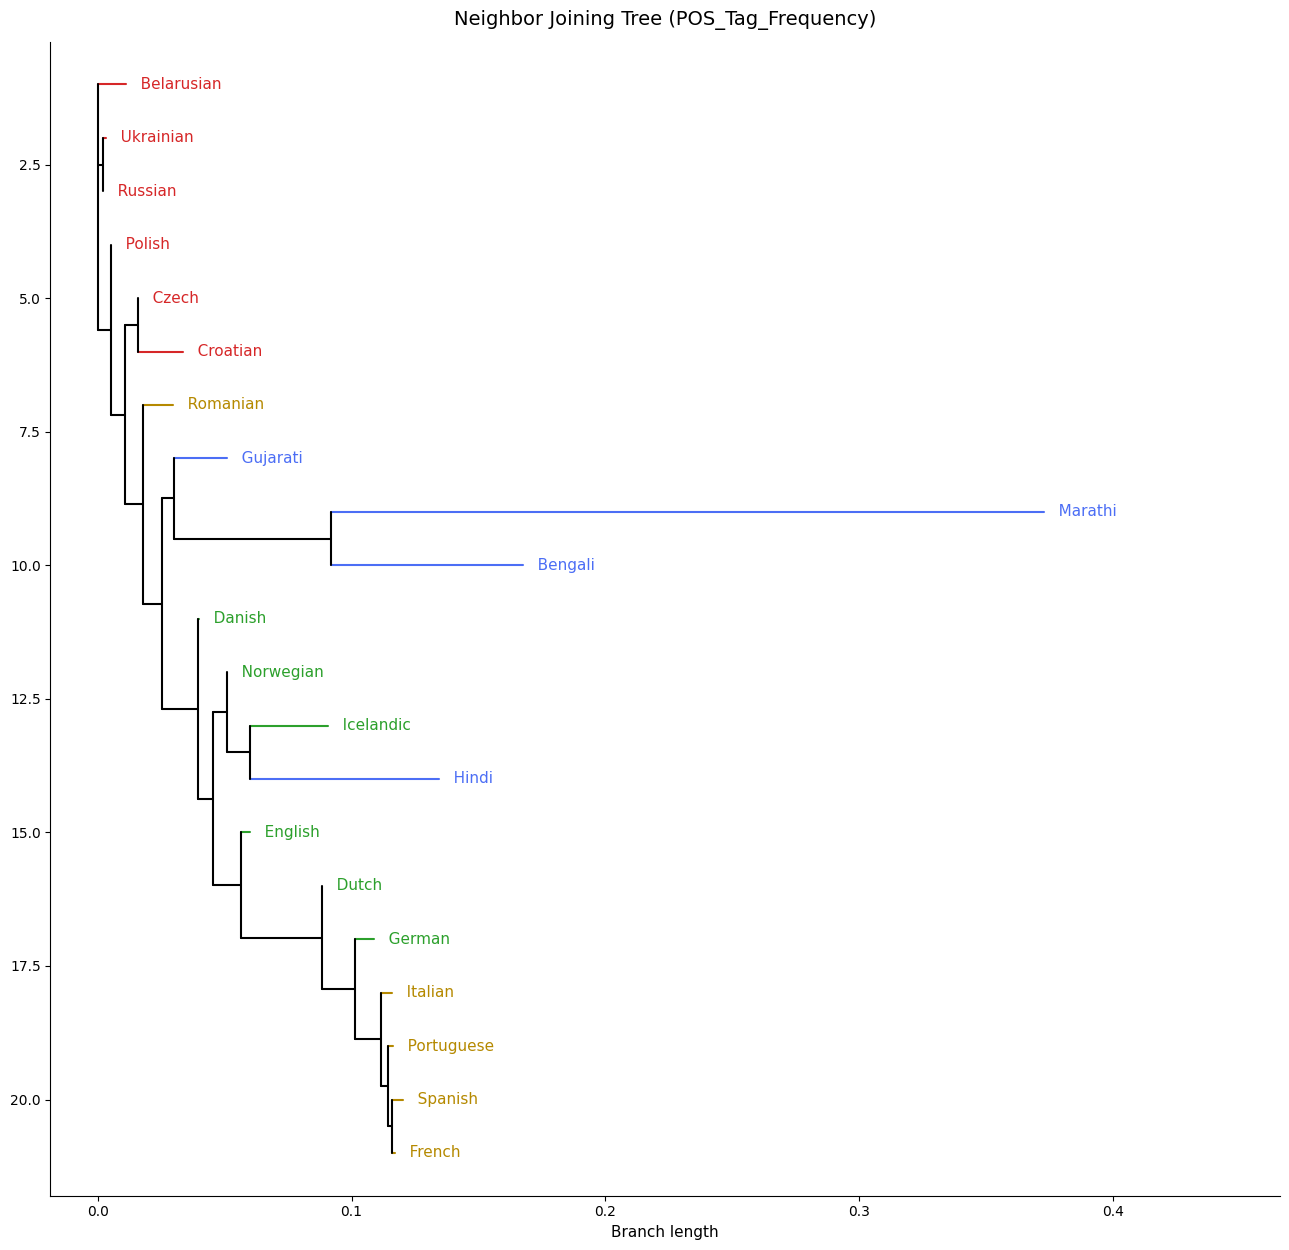

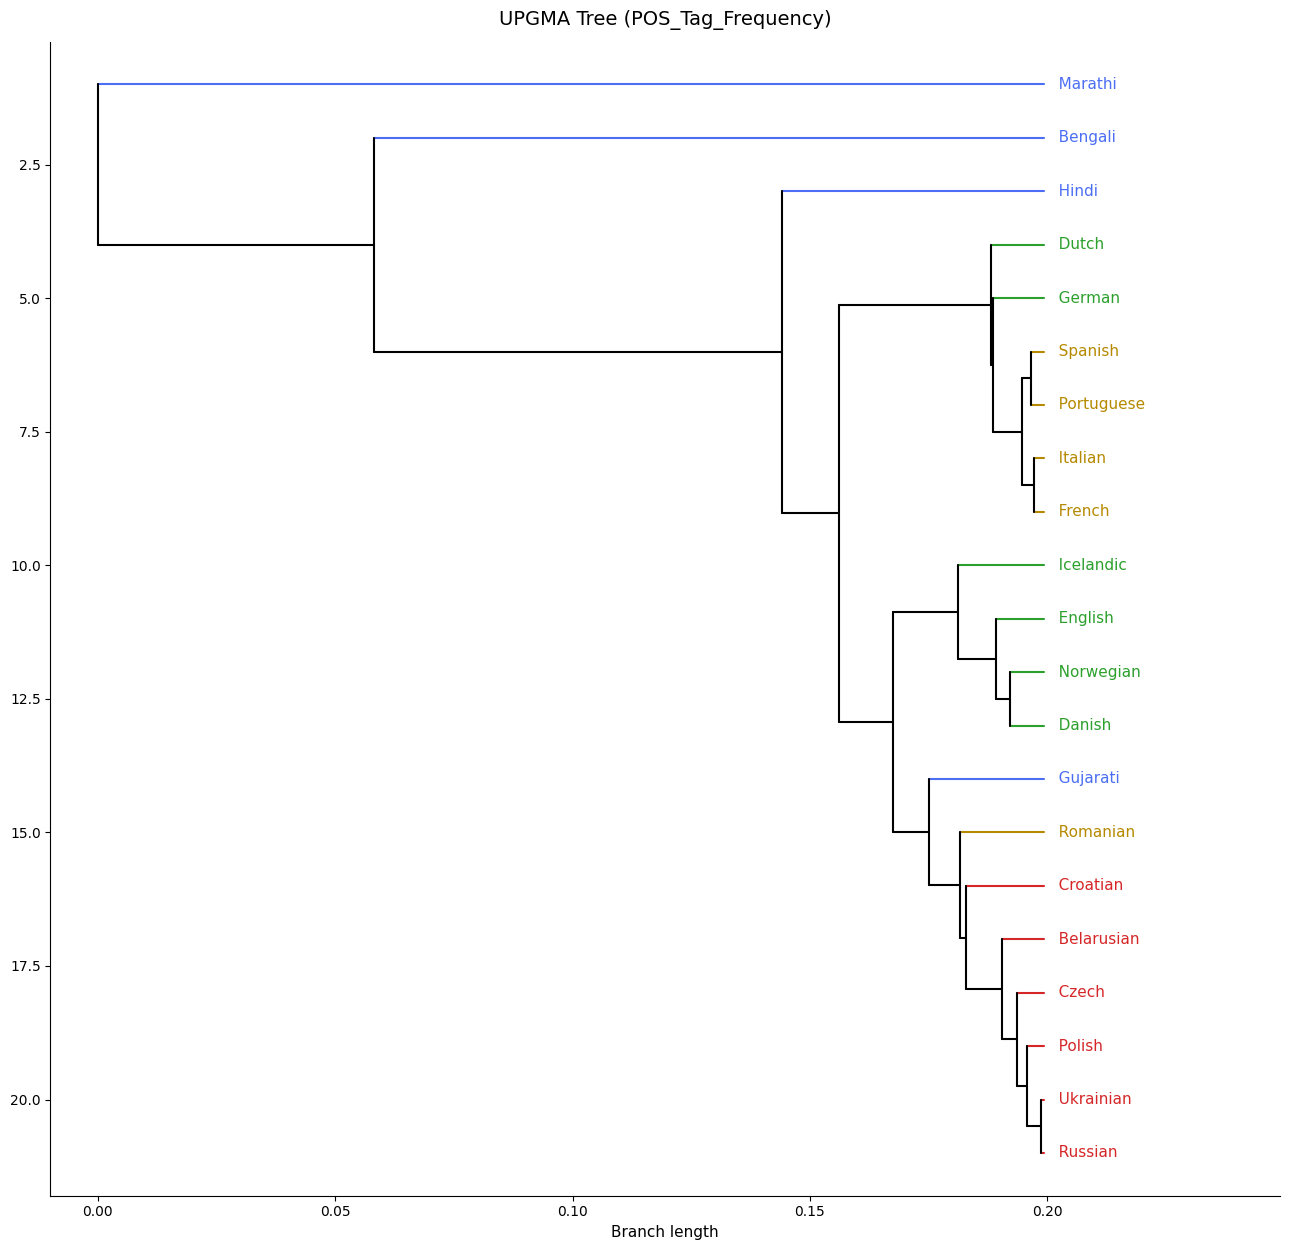

In [35]:
nj_tree_pos, upgma_tree_pos = build_tree_mean_cos_distance(language_vectors_pos, method_name = "POS_Tag_Frequency")

#### Feature extractions ependencies_Frequency

In [36]:

all_deprels = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            if token.get("deprel") is not None:
                all_deprels.add(token["deprel"])

# sort to fix feature order
all_deprels = sorted(all_deprels)

print("Dependency-relation features:", all_deprels)


language_vectors_deprel = {}

for lang, sentences in language_structures.items():
    deprel_counter = Counter()
    total_tokens = 0

    for sentence in sentences:
        for token in sentence:
            deprel = token.get("deprel")
            if deprel is not None:
                deprel_counter[deprel] += 1
                total_tokens += 1

    # build vector in SAME ORDER for all languages
    vector = []
    for rel in all_deprels:
        freq = deprel_counter[rel] / total_tokens if total_tokens > 0 else 0
        vector.append(freq)

    
    language_vectors_deprel[lang] = np.array([vector])



for lang, vec in language_vectors_deprel.items():
    print(lang, vec.shape)
    print(vec)
    break

Dependency-relation features: ['acl', 'acl:adv', 'acl:relcl', 'advcl', 'advcl:cleft', 'advcl:cmpr', 'advcl:pred', 'advcl:relcl', 'advcl:svc', 'advcl:tcl', 'advmod', 'advmod:arg', 'advmod:det', 'advmod:emph', 'advmod:lmod', 'advmod:neg', 'advmod:tmod', 'amod', 'amod:flat', 'appos', 'aux', 'aux:caus', 'aux:clitic', 'aux:cnd', 'aux:imp', 'aux:pass', 'aux:tense', 'case', 'cc', 'cc:preconj', 'ccomp', 'ccomp:cleft', 'ccomp:obj', 'ccomp:pmod', 'compoun:svc', 'compound', 'compound:lvb', 'compound:lvc', 'compound:prt', 'compound:redup', 'compound:svc', 'conj', 'conj:svc', 'cop', 'cop:own', 'csubj', 'csubj:outer', 'csubj:pass', 'dep', 'dep:comp', 'det', 'det:numgov', 'det:nummod', 'det:poss', 'det:predet', 'dicourse', 'discourse', 'discourse:intj', 'dislocated', 'expl', 'expl:comp', 'expl:impers', 'expl:pass', 'expl:poss', 'expl:pv', 'expl:subj', 'fixed', 'flat', 'flat:abs', 'flat:foreign', 'flat:name', 'flat:range', 'flat:repeat', 'flat:sibl', 'flat:title', 'goeswith', 'iobj', 'iobj:agent', 'li

Languages used: ['Belarusian', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English', 'French', 'German', 'Gujarati', 'Hindi', 'Icelandic', 'Italian', 'Marathi', 'Norwegian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Spanish', 'Ukrainian']

Cosine Similarity:
            Belarusian  Bengali  Croatian  Czech  Danish  Dutch  English  \
Belarusian       1.000    0.789     0.932  0.969   0.924  0.848    0.882   
Bengali          0.789    1.000     0.661  0.737   0.773  0.711    0.808   
Croatian         0.932    0.661     1.000  0.964   0.932  0.852    0.886   
Czech            0.969    0.737     0.964  1.000   0.936  0.864    0.894   
Danish           0.924    0.773     0.932  0.936   1.000  0.943    0.968   
Dutch            0.848    0.711     0.852  0.864   0.943  1.000    0.954   
English          0.882    0.808     0.886  0.894   0.968  0.954    1.000   
French           0.776    0.547     0.769  0.799   0.821  0.914    0.844   
German           0.877    0.678     0.868  

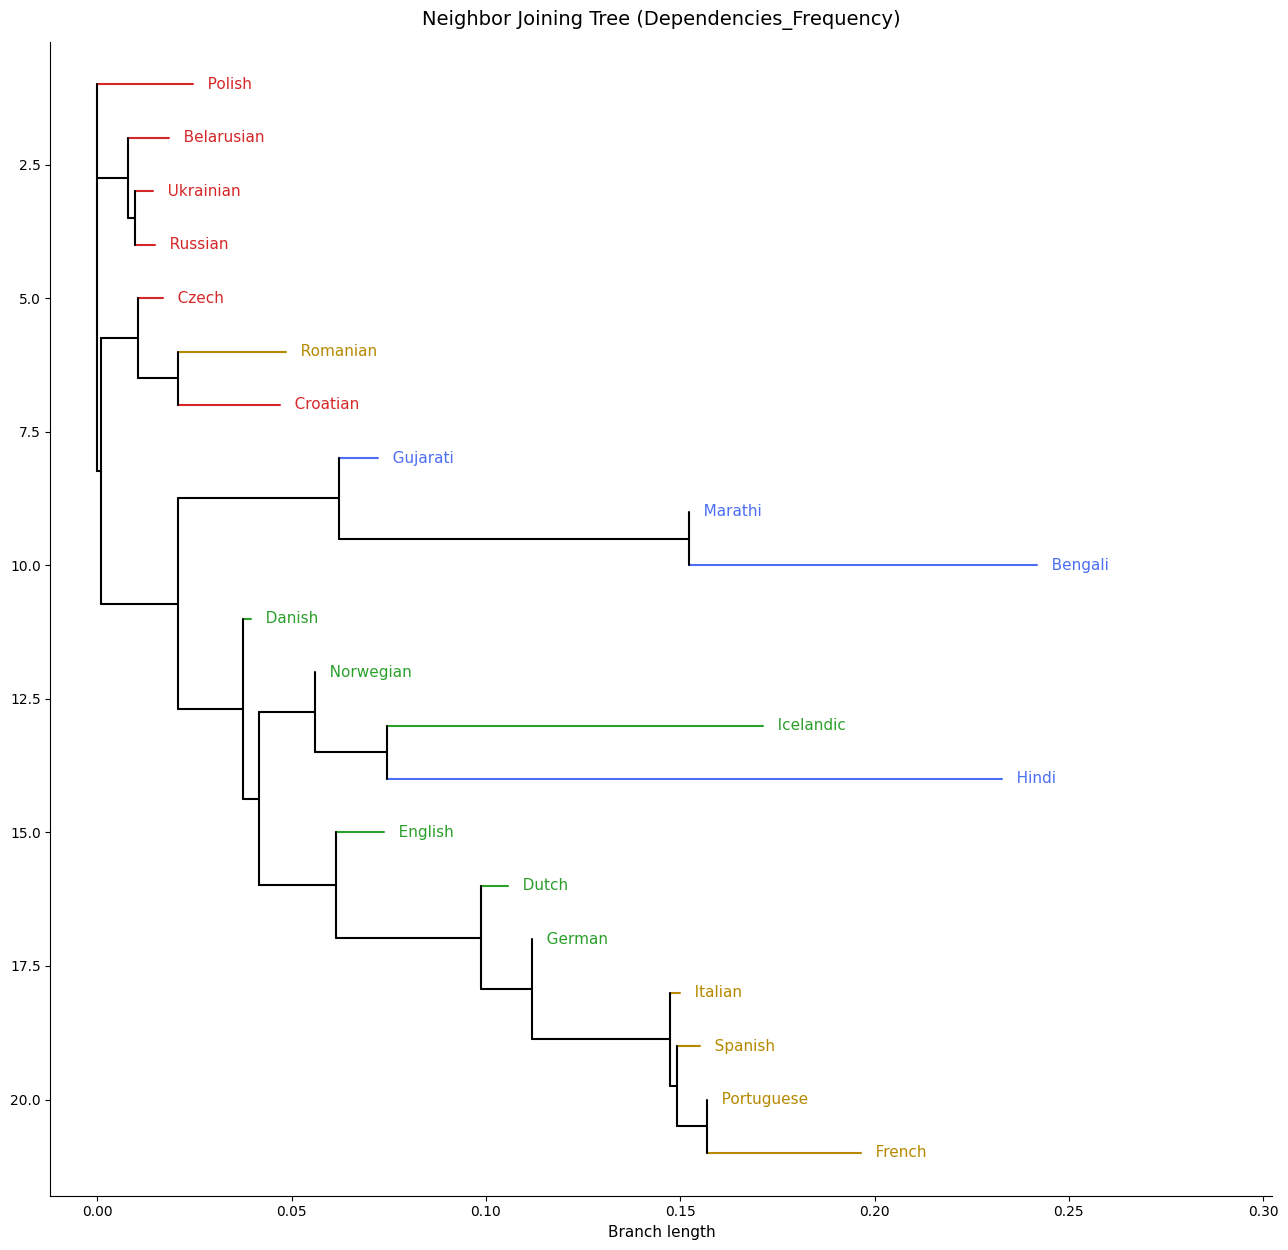

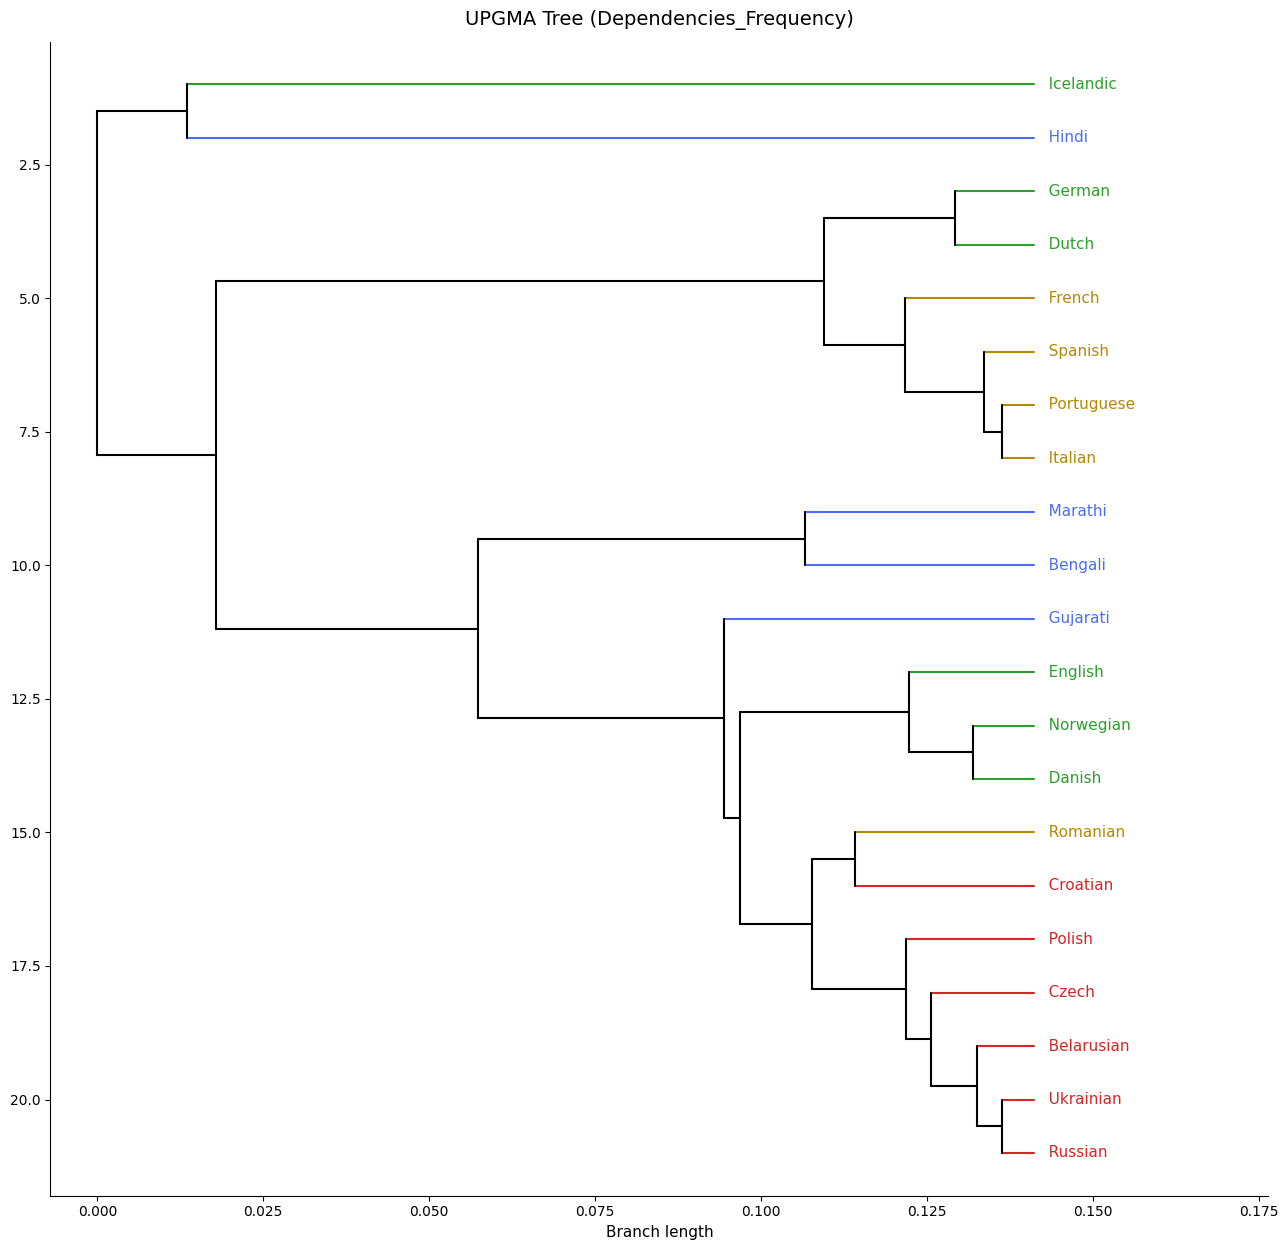

In [37]:
nj_tree_deprel, upgma_tree_deprel = build_tree_mean_cos_distance(language_vectors_deprel, method_name = "Dependencies_Frequency")

#### Feature Extractions POS And Dependency Frequency

In [38]:
from collections import Counter
import numpy as np

all_upos = set()

all_deprels = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            upos = token.get("upos")
            deprel = token.get("deprel")

            if upos is not None:
                all_upos.add(upos)

            if deprel is not None:
                all_deprels.add(deprel)


all_upos = sorted(all_upos)
all_deprels = sorted(all_deprels)

print("POS features:", all_upos)
print("Dependency features:", all_deprels)


language_vectors_pos_deprel = {}

for lang, sentences in language_structures.items():
    upos_counter = Counter()
    deprel_counter = Counter()
    total_tokens = 0

    for sentence in sentences:
        for token in sentence:
            upos = token.get("upos")
            deprel = token.get("deprel")

            if upos is not None:
                upos_counter[upos] += 1

            if deprel is not None:
                deprel_counter[deprel] += 1

            # count token once
            total_tokens += 1

    
    if total_tokens == 0:
        continue

    
    pos_vector = []
    for tag in all_upos:
        pos_vector.append(upos_counter[tag] / total_tokens)

    # deprel frequency part
    deprel_vector = []
    for rel in all_deprels:
        deprel_vector.append(deprel_counter[rel] / total_tokens)

    # Final combined vector
    full_vector = pos_vector + deprel_vector

    
    language_vectors_pos_deprel[lang] = np.array([full_vector])



print("\nTotal number of features:", len(all_upos) + len(all_deprels))

for lang, vec in language_vectors_pos_deprel.items():
    print(lang, vec.shape)
    print(vec)
    break

POS features: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'None', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', '_']
Dependency features: ['acl', 'acl:adv', 'acl:relcl', 'advcl', 'advcl:cleft', 'advcl:cmpr', 'advcl:pred', 'advcl:relcl', 'advcl:svc', 'advcl:tcl', 'advmod', 'advmod:arg', 'advmod:det', 'advmod:emph', 'advmod:lmod', 'advmod:neg', 'advmod:tmod', 'amod', 'amod:flat', 'appos', 'aux', 'aux:caus', 'aux:clitic', 'aux:cnd', 'aux:imp', 'aux:pass', 'aux:tense', 'case', 'cc', 'cc:preconj', 'ccomp', 'ccomp:cleft', 'ccomp:obj', 'ccomp:pmod', 'compoun:svc', 'compound', 'compound:lvb', 'compound:lvc', 'compound:prt', 'compound:redup', 'compound:svc', 'conj', 'conj:svc', 'cop', 'cop:own', 'csubj', 'csubj:outer', 'csubj:pass', 'dep', 'dep:comp', 'det', 'det:numgov', 'det:nummod', 'det:poss', 'det:predet', 'dicourse', 'discourse', 'discourse:intj', 'dislocated', 'expl', 'expl:comp', 'expl:impers', 'expl:pass', 'expl:poss', 'expl:pv', 'expl:subj', 'f

Languages used: ['Belarusian', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English', 'French', 'German', 'Gujarati', 'Hindi', 'Icelandic', 'Italian', 'Marathi', 'Norwegian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Spanish', 'Ukrainian']

Cosine Similarity:
            Belarusian  Bengali  Croatian  Czech  Danish  Dutch  English  \
Belarusian       1.000    0.825     0.948  0.976   0.938  0.874    0.903   
Bengali          0.825    1.000     0.730  0.796   0.825  0.758    0.847   
Croatian         0.948    0.730     1.000  0.978   0.942  0.891    0.917   
Czech            0.976    0.796     0.978  1.000   0.955  0.900    0.926   
Danish           0.938    0.825     0.942  0.955   1.000  0.957    0.975   
Dutch            0.874    0.758     0.891  0.900   0.957  1.000    0.966   
English          0.903    0.847     0.917  0.926   0.975  0.966    1.000   
French           0.832    0.645     0.843  0.859   0.884  0.954    0.895   
German           0.888    0.718     0.895  

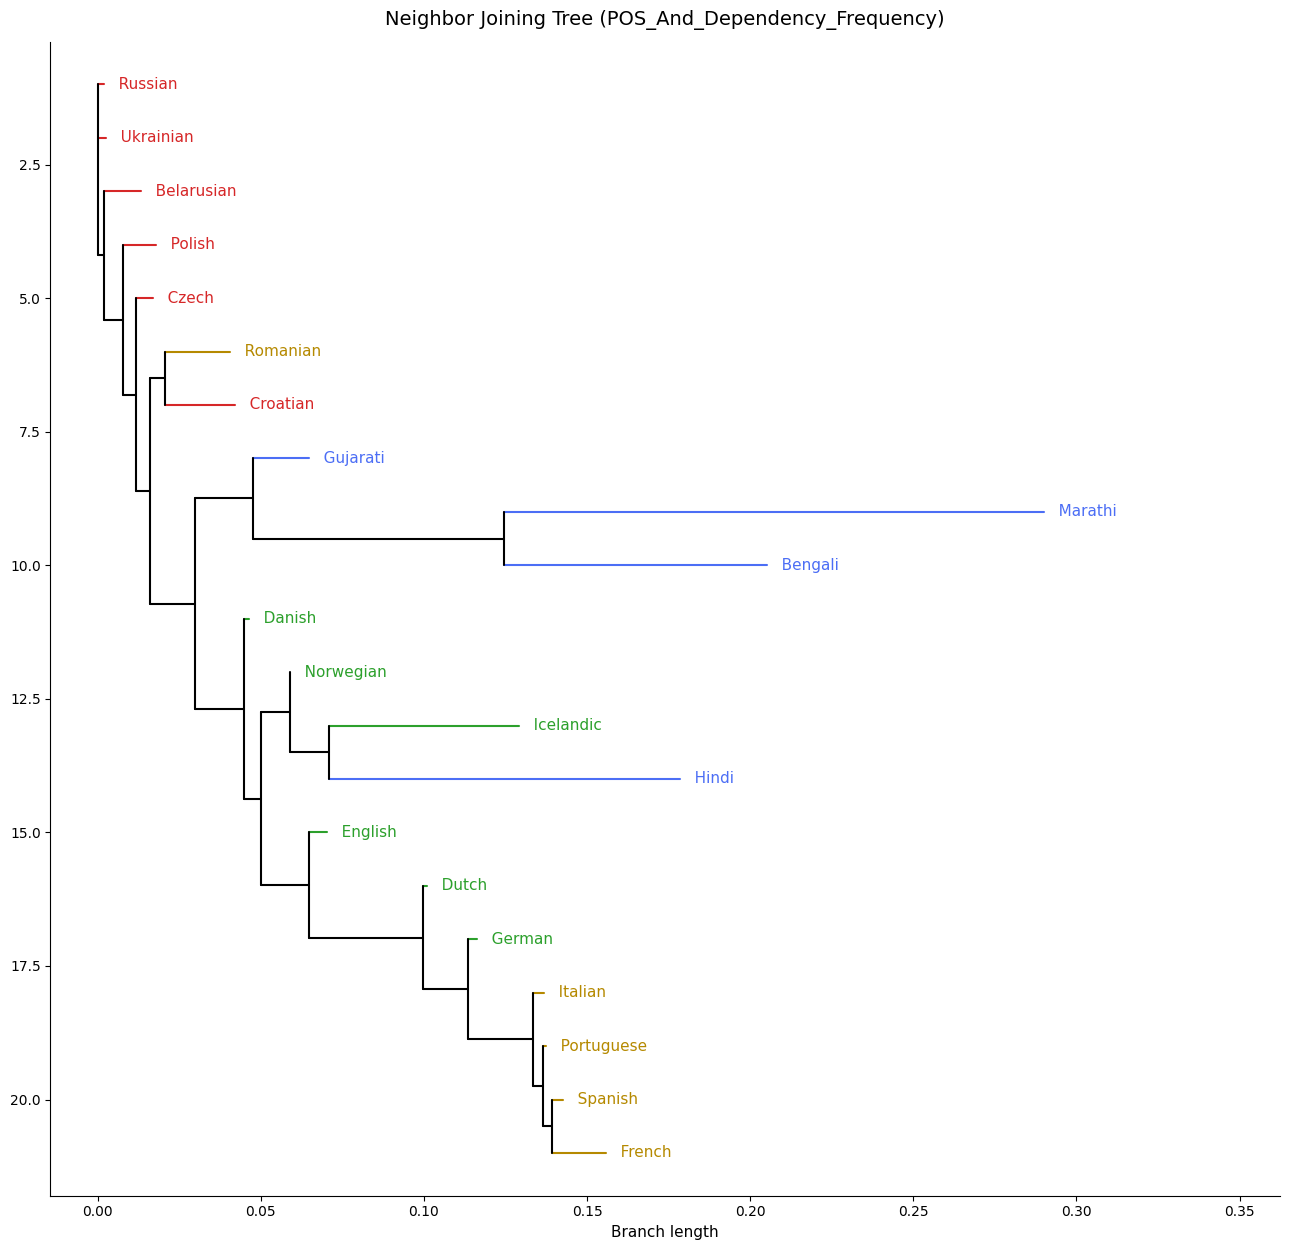

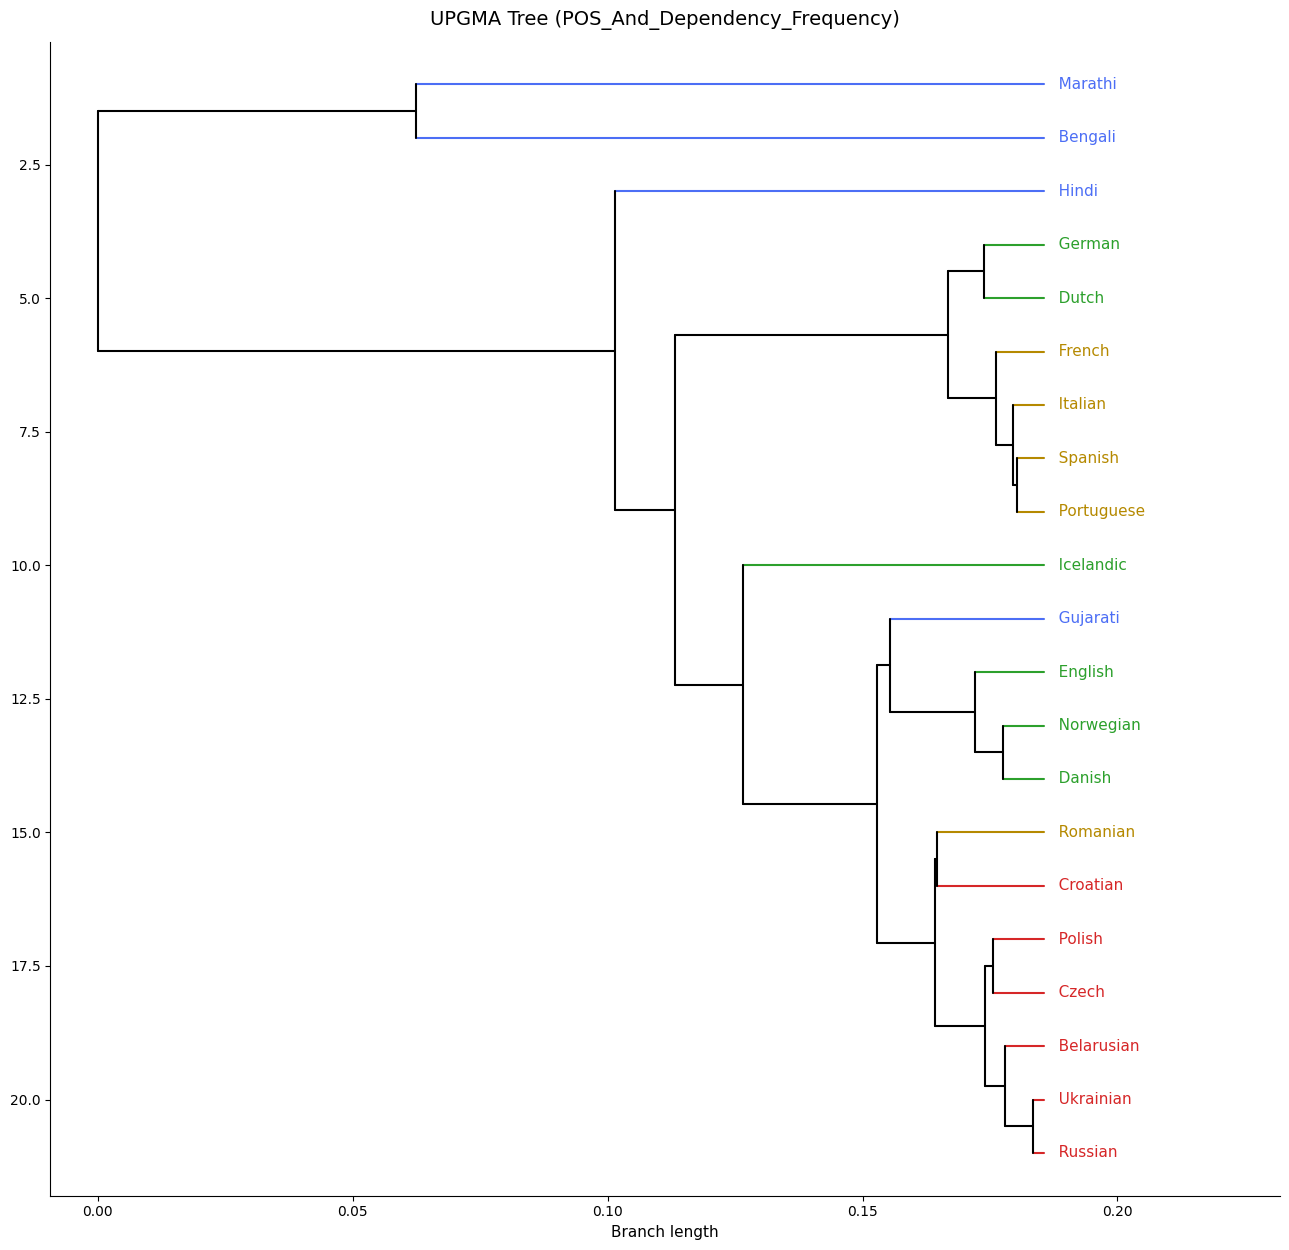

In [39]:
nj_tree_pos_deprel, upgma_tree_pos_deprel = build_tree_mean_cos_distance(language_vectors_pos_deprel, method_name = "POS_And_Dependency_Frequency")

#### Feature Extractions POS_Transitions

In [40]:
from collections import Counter, defaultdict
import numpy as np


all_upos = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            upos = token.get("upos")
            if upos is not None:
                all_upos.add(upos)

# fixed global order
all_upos = sorted(all_upos)

print("POS tags:", all_upos)



all_pos_transitions = []

for tag1 in all_upos:
    for tag2 in all_upos:
        all_pos_transitions.append((tag1, tag2))

print("Number of POS transition features:", len(all_pos_transitions))



language_vectors_pos_transitions = {}

for lang, sentences in language_structures.items():
    # count bigrams: (tag1, tag2)
    bigram_counter = Counter()

    # count how many times each tag appears as the FIRST element of a transition
    outgoing_counter = Counter()

    for sentence in sentences:
        pos_seq = [token.get("upos") for token in sentence if token.get("upos") is not None]

        for i in range(len(pos_seq) - 1):
            tag1 = pos_seq[i]
            tag2 = pos_seq[i + 1]

            bigram_counter[(tag1, tag2)] += 1
            outgoing_counter[tag1] += 1

    vector = []

    for tag1, tag2 in all_pos_transitions:
        if outgoing_counter[tag1] > 0:
            prob = bigram_counter[(tag1, tag2)] / outgoing_counter[tag1]
        else:
            prob = 0.0
        vector.append(prob)

    language_vectors_pos_transitions[lang] = np.array([vector])



for lang, vec in language_vectors_pos_transitions.items():
    print(lang, vec.shape)
    print(vec)
    break

POS tags: ['ADJ', 'ADP', 'ADV', 'AUX', 'CCONJ', 'DET', 'INTJ', 'NOUN', 'NUM', 'None', 'PART', 'PRON', 'PROPN', 'PUNCT', 'SCONJ', 'SYM', 'VERB', 'X', '_']
Number of POS transition features: 361
Belarusian (1, 361)
[[6.49272755e-02 2.36917079e-02 2.51162093e-03 3.18638477e-03
  2.16674164e-02 2.66156845e-03 0.00000000e+00 7.23759184e-01
  2.96146349e-03 0.00000000e+00 2.47413405e-03 2.96146349e-03
  1.66816614e-02 1.09049333e-01 7.12250712e-04 1.12460639e-03
  1.53696206e-02 6.26030889e-03 0.00000000e+00 1.91297900e-01
  9.77385326e-04 4.48249132e-03 3.37029423e-05 2.02217654e-04
  6.50466786e-02 0.00000000e+00 4.47035826e-01 4.65437633e-02
  0.00000000e+00 3.37029423e-04 6.68329345e-02 1.41788278e-01
  1.73570153e-02 2.02217654e-04 5.05544134e-04 4.98803546e-03
  1.23689798e-02 0.00000000e+00 7.34375000e-02 1.20588235e-01
  6.82904412e-02 1.42463235e-02 1.51654412e-02 2.03125000e-02
  0.00000000e+00 7.68382353e-02 2.71139706e-02 0.00000000e+00
  4.79779412e-02 5.17463235e-02 1.42463235e

Languages used: ['Belarusian', 'Bengali', 'Croatian', 'Czech', 'Danish', 'Dutch', 'English', 'French', 'German', 'Gujarati', 'Hindi', 'Icelandic', 'Italian', 'Marathi', 'Norwegian', 'Polish', 'Portuguese', 'Romanian', 'Russian', 'Spanish', 'Ukrainian']

Cosine Similarity:
            Belarusian  Bengali  Croatian  Czech  Danish  Dutch  English  \
Belarusian       1.000    0.522     0.848  0.925   0.876  0.837    0.827   
Bengali          0.522    1.000     0.390  0.513   0.457  0.501    0.411   
Croatian         0.848    0.390     1.000  0.888   0.765  0.745    0.759   
Czech            0.925    0.513     0.888  1.000   0.787  0.834    0.748   
Danish           0.876    0.457     0.765  0.787   1.000  0.825    0.877   
Dutch            0.837    0.501     0.745  0.834   0.825  1.000    0.824   
English          0.827    0.411     0.759  0.748   0.877  0.824    1.000   
French           0.765    0.386     0.683  0.757   0.722  0.883    0.776   
German           0.794    0.503     0.723  

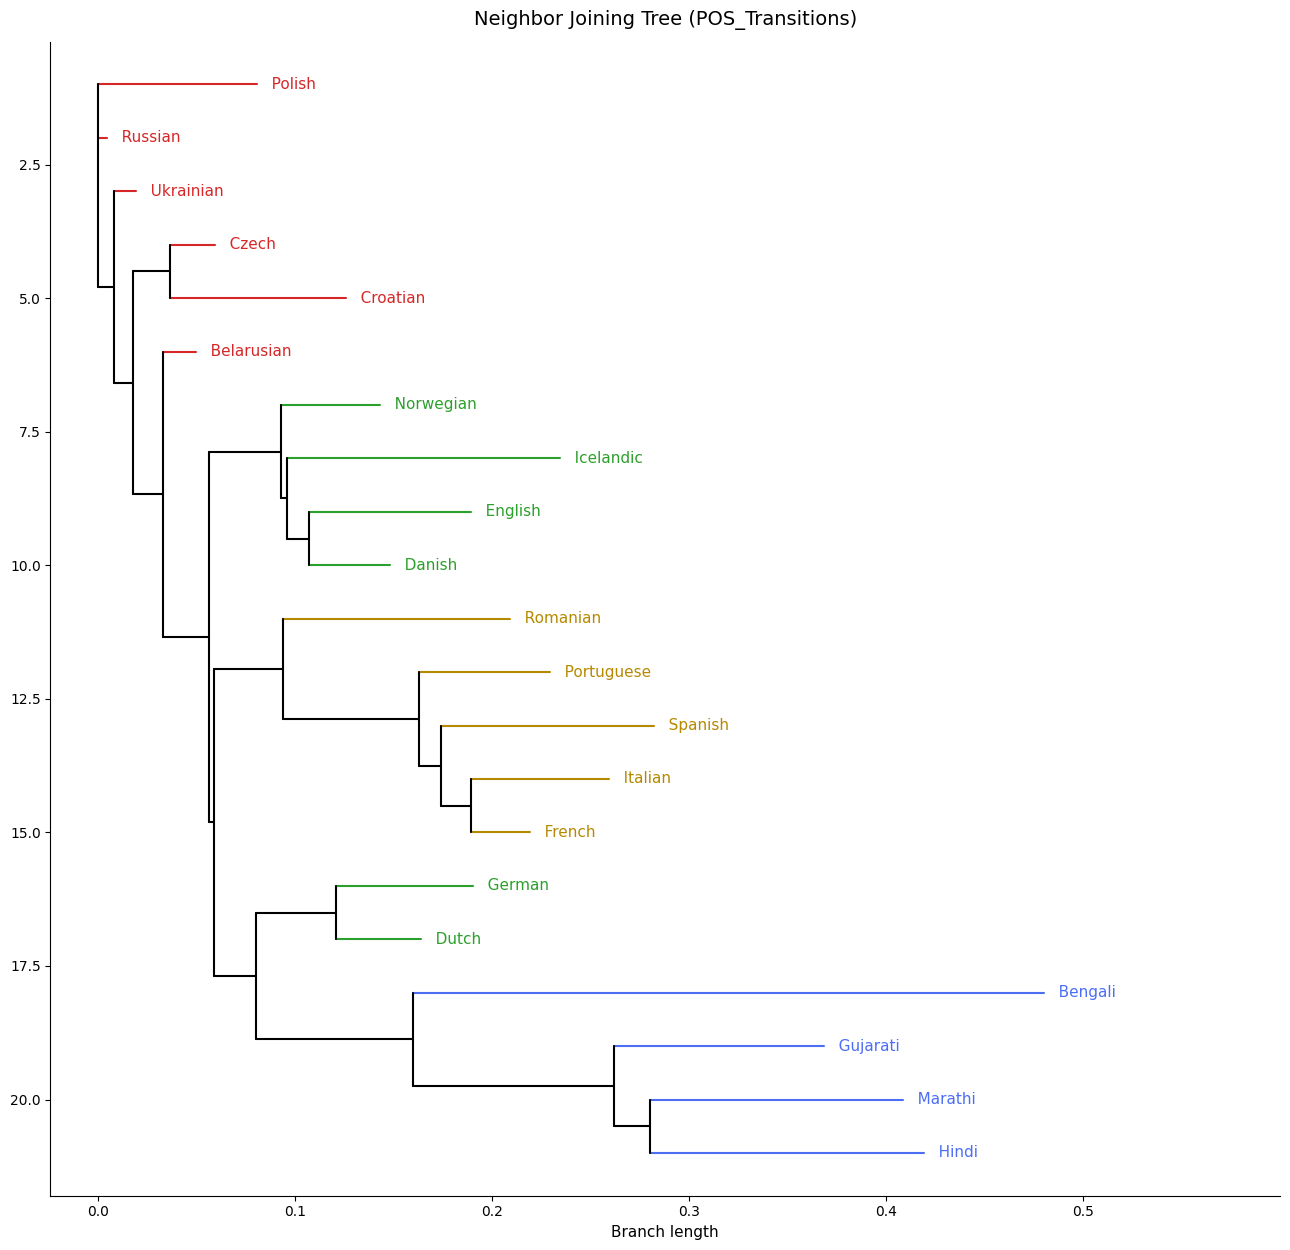

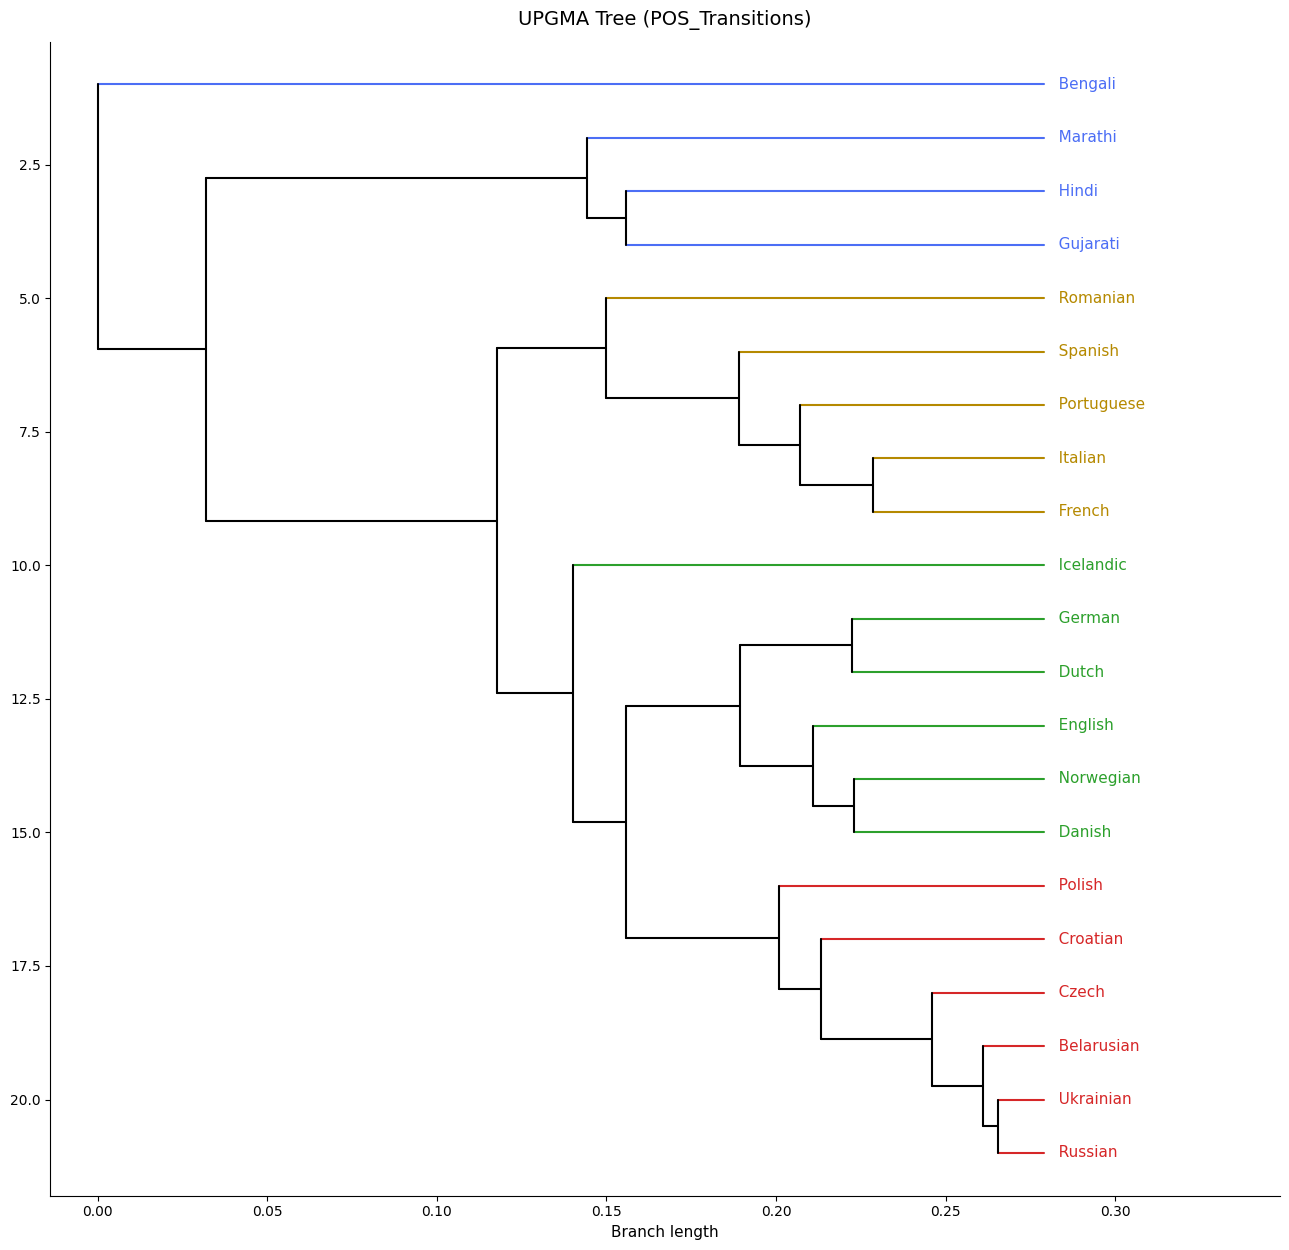

In [41]:
nj_tree_pos_transitions, upgma_tree_pos_transitions = build_tree_mean_cos_distance(language_vectors_pos_transitions, method_name = "POS_Transitions")

#### Feature Extraction Dependncy Trasition

Dependency relations: ['acl', 'acl:adv', 'acl:relcl', 'advcl', 'advcl:cleft', 'advcl:cmpr', 'advcl:pred', 'advcl:relcl', 'advcl:svc', 'advcl:tcl', 'advmod', 'advmod:arg', 'advmod:det', 'advmod:emph', 'advmod:lmod', 'advmod:neg', 'advmod:tmod', 'amod', 'amod:flat', 'appos', 'aux', 'aux:caus', 'aux:clitic', 'aux:cnd', 'aux:imp', 'aux:pass', 'aux:tense', 'case', 'cc', 'cc:preconj', 'ccomp', 'ccomp:cleft', 'ccomp:obj', 'ccomp:pmod', 'compoun:svc', 'compound', 'compound:lvb', 'compound:lvc', 'compound:prt', 'compound:redup', 'compound:svc', 'conj', 'conj:svc', 'cop', 'cop:own', 'csubj', 'csubj:outer', 'csubj:pass', 'dep', 'dep:comp', 'det', 'det:numgov', 'det:nummod', 'det:poss', 'det:predet', 'dicourse', 'discourse', 'discourse:intj', 'dislocated', 'expl', 'expl:comp', 'expl:impers', 'expl:pass', 'expl:poss', 'expl:pv', 'expl:subj', 'fixed', 'flat', 'flat:abs', 'flat:foreign', 'flat:name', 'flat:range', 'flat:repeat', 'flat:sibl', 'flat:title', 'goeswith', 'iobj', 'iobj:agent', 'list', 'ma

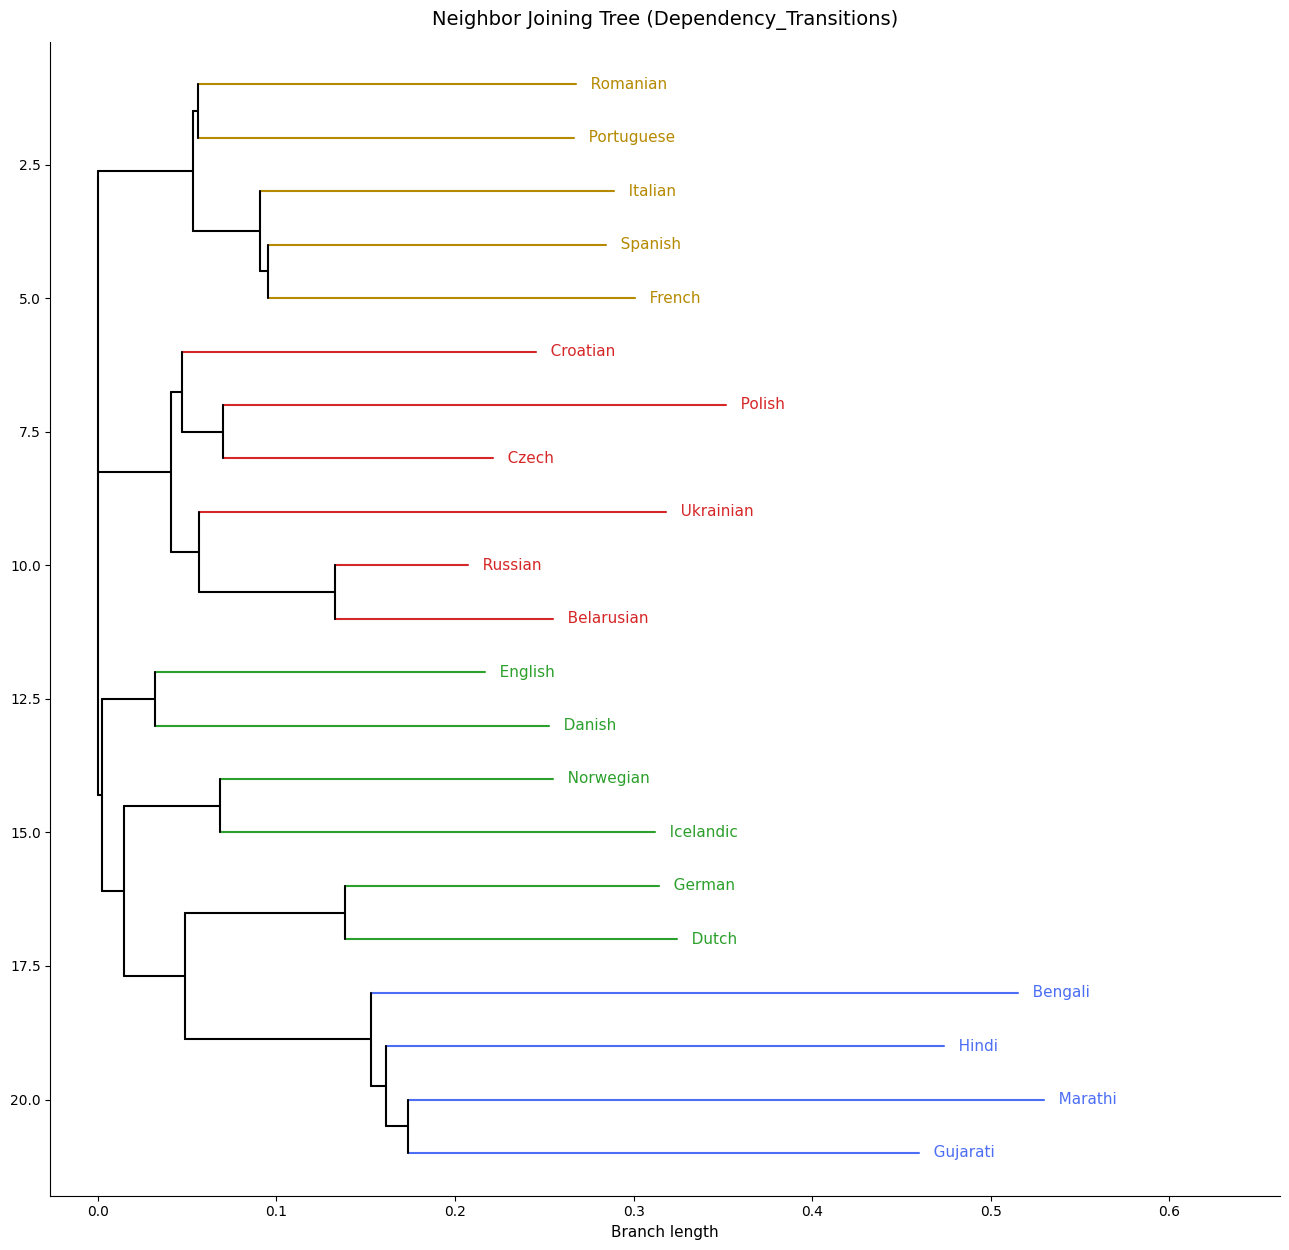

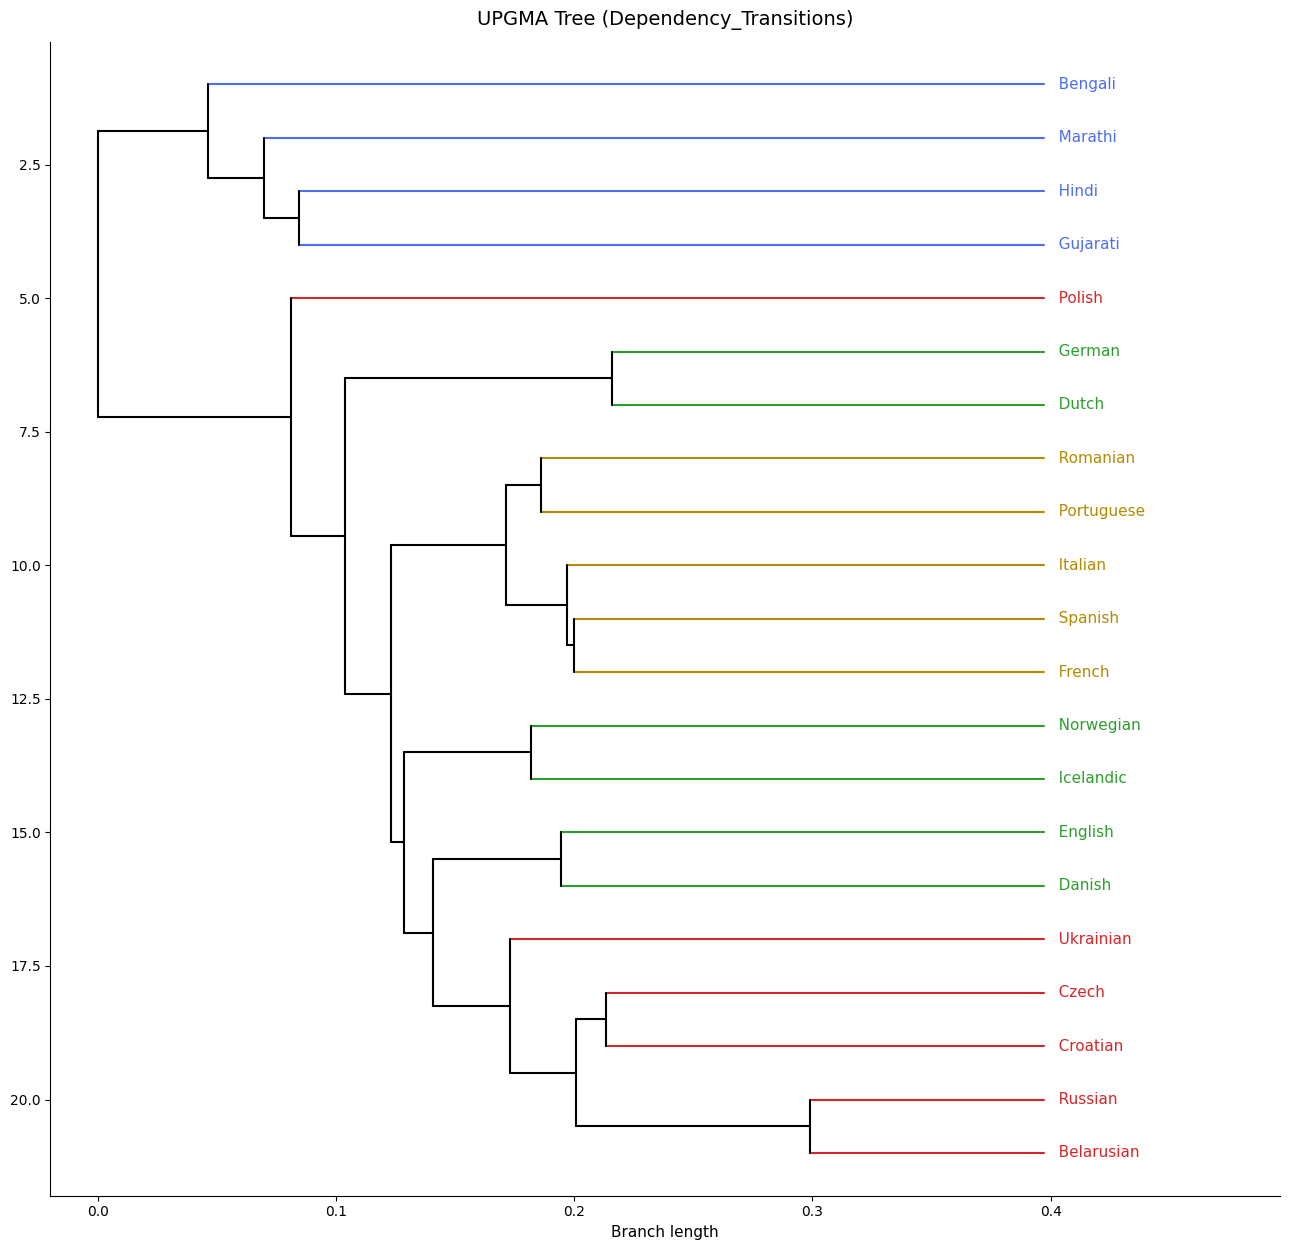

In [42]:
from collections import Counter
import numpy as np


all_deprels = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            deprel = token.get("deprel")
            if deprel is not None:
                all_deprels.add(deprel)

# fixed global order
all_deprels = sorted(all_deprels)

print("Dependency relations:", all_deprels)
print("Number of dependency relations:", len(all_deprels))



all_deprel_transitions = []

for rel1 in all_deprels:
    for rel2 in all_deprels:
        all_deprel_transitions.append((rel1, rel2))

print("Number of dependency transition features:", len(all_deprel_transitions))



language_vectors_deprel_transitions = {}

for lang, sentences in language_structures.items():
    bigram_counter = Counter()
    outgoing_counter = Counter()

    for sentence in sentences:
        rel_seq = [token.get("deprel") for token in sentence if token.get("deprel") is not None]

        for i in range(len(rel_seq) - 1):
            rel1 = rel_seq[i]
            rel2 = rel_seq[i + 1]

            bigram_counter[(rel1, rel2)] += 1
            outgoing_counter[rel1] += 1

    vector = []

    for rel1, rel2 in all_deprel_transitions:
        if outgoing_counter[rel1] > 0:
            prob = bigram_counter[(rel1, rel2)] / outgoing_counter[rel1]
        else:
            prob = 0.0
        vector.append(prob)

    
    language_vectors_deprel_transitions[lang] = np.array([vector])



for lang, vec in language_vectors_deprel_transitions.items():
    print(lang, vec.shape)
    print(vec)
    break

nj_tree_deprel_transitions, upgma_tree_deprel_transitions = build_tree_mean_cos_distance(language_vectors_deprel_transitions, method_name = "Dependency_Transitions")

#### Feature Extractions Dependency_Distance_Direction

Dependency relations: ['acl', 'acl:adv', 'acl:relcl', 'advcl', 'advcl:cleft', 'advcl:cmpr', 'advcl:pred', 'advcl:relcl', 'advcl:svc', 'advcl:tcl', 'advmod', 'advmod:arg', 'advmod:det', 'advmod:emph', 'advmod:lmod', 'advmod:neg', 'advmod:tmod', 'amod', 'amod:flat', 'appos', 'aux', 'aux:caus', 'aux:clitic', 'aux:cnd', 'aux:imp', 'aux:pass', 'aux:tense', 'case', 'cc', 'cc:preconj', 'ccomp', 'ccomp:cleft', 'ccomp:obj', 'ccomp:pmod', 'compoun:svc', 'compound', 'compound:lvb', 'compound:lvc', 'compound:prt', 'compound:redup', 'compound:svc', 'conj', 'conj:svc', 'cop', 'cop:own', 'csubj', 'csubj:outer', 'csubj:pass', 'dep', 'dep:comp', 'det', 'det:numgov', 'det:nummod', 'det:poss', 'det:predet', 'dicourse', 'discourse', 'discourse:intj', 'dislocated', 'expl', 'expl:comp', 'expl:impers', 'expl:pass', 'expl:poss', 'expl:pv', 'expl:subj', 'fixed', 'flat', 'flat:abs', 'flat:foreign', 'flat:name', 'flat:range', 'flat:repeat', 'flat:sibl', 'flat:title', 'goeswith', 'iobj', 'iobj:agent', 'list', 'ma

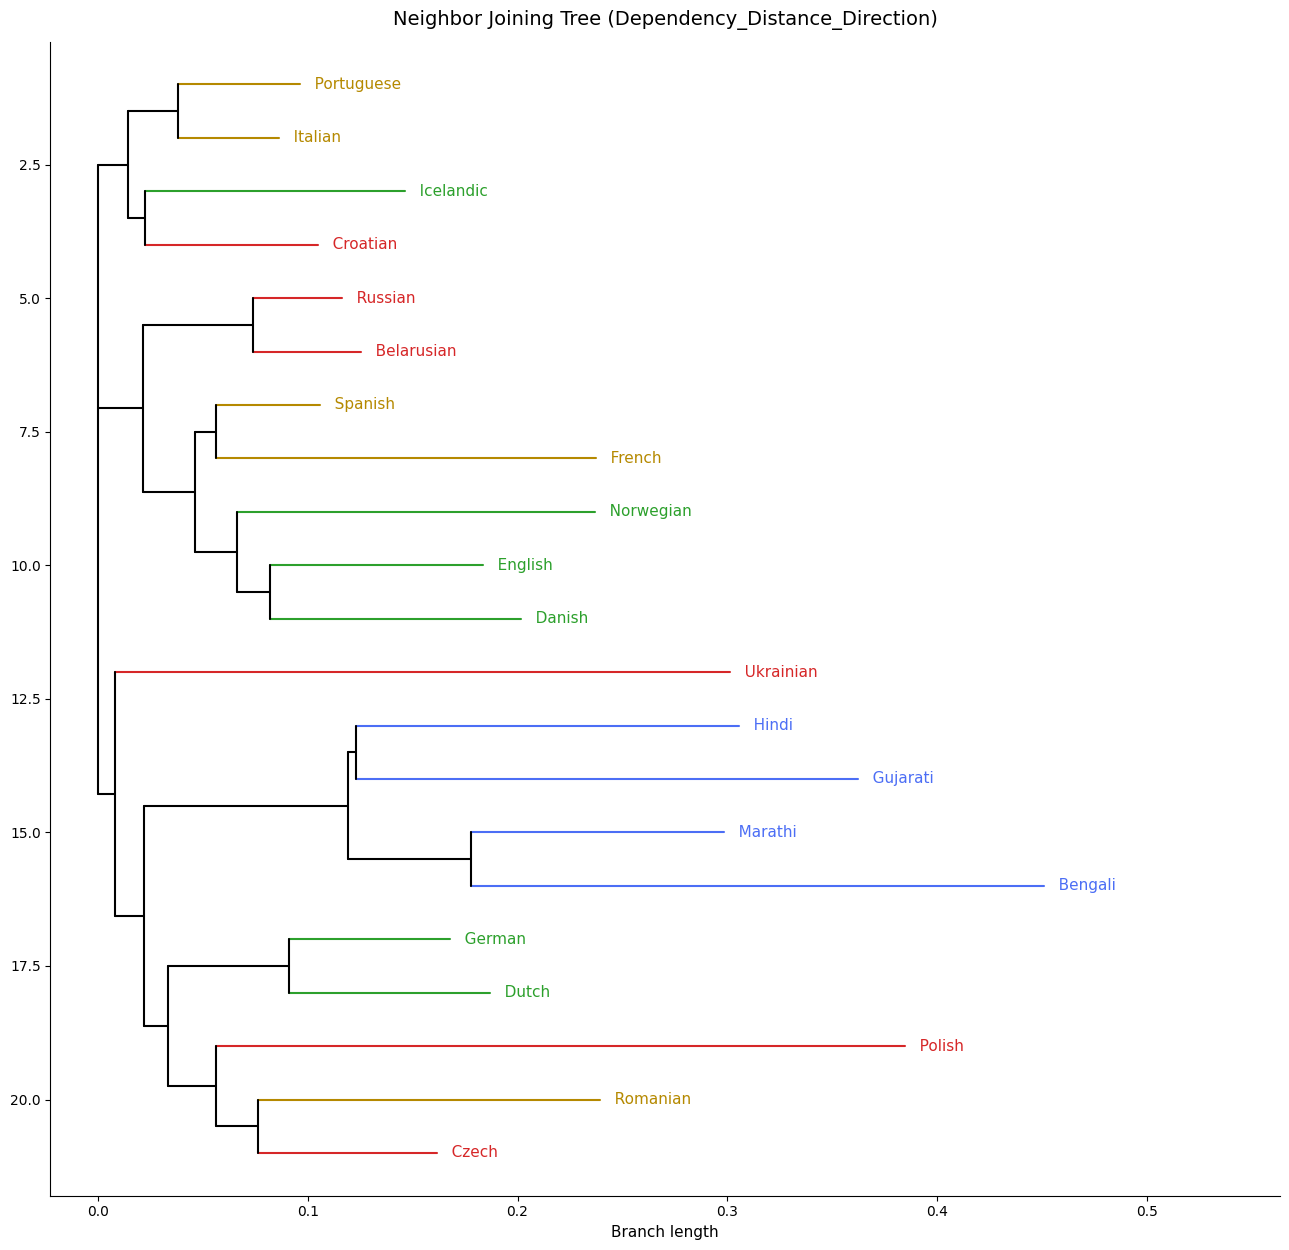

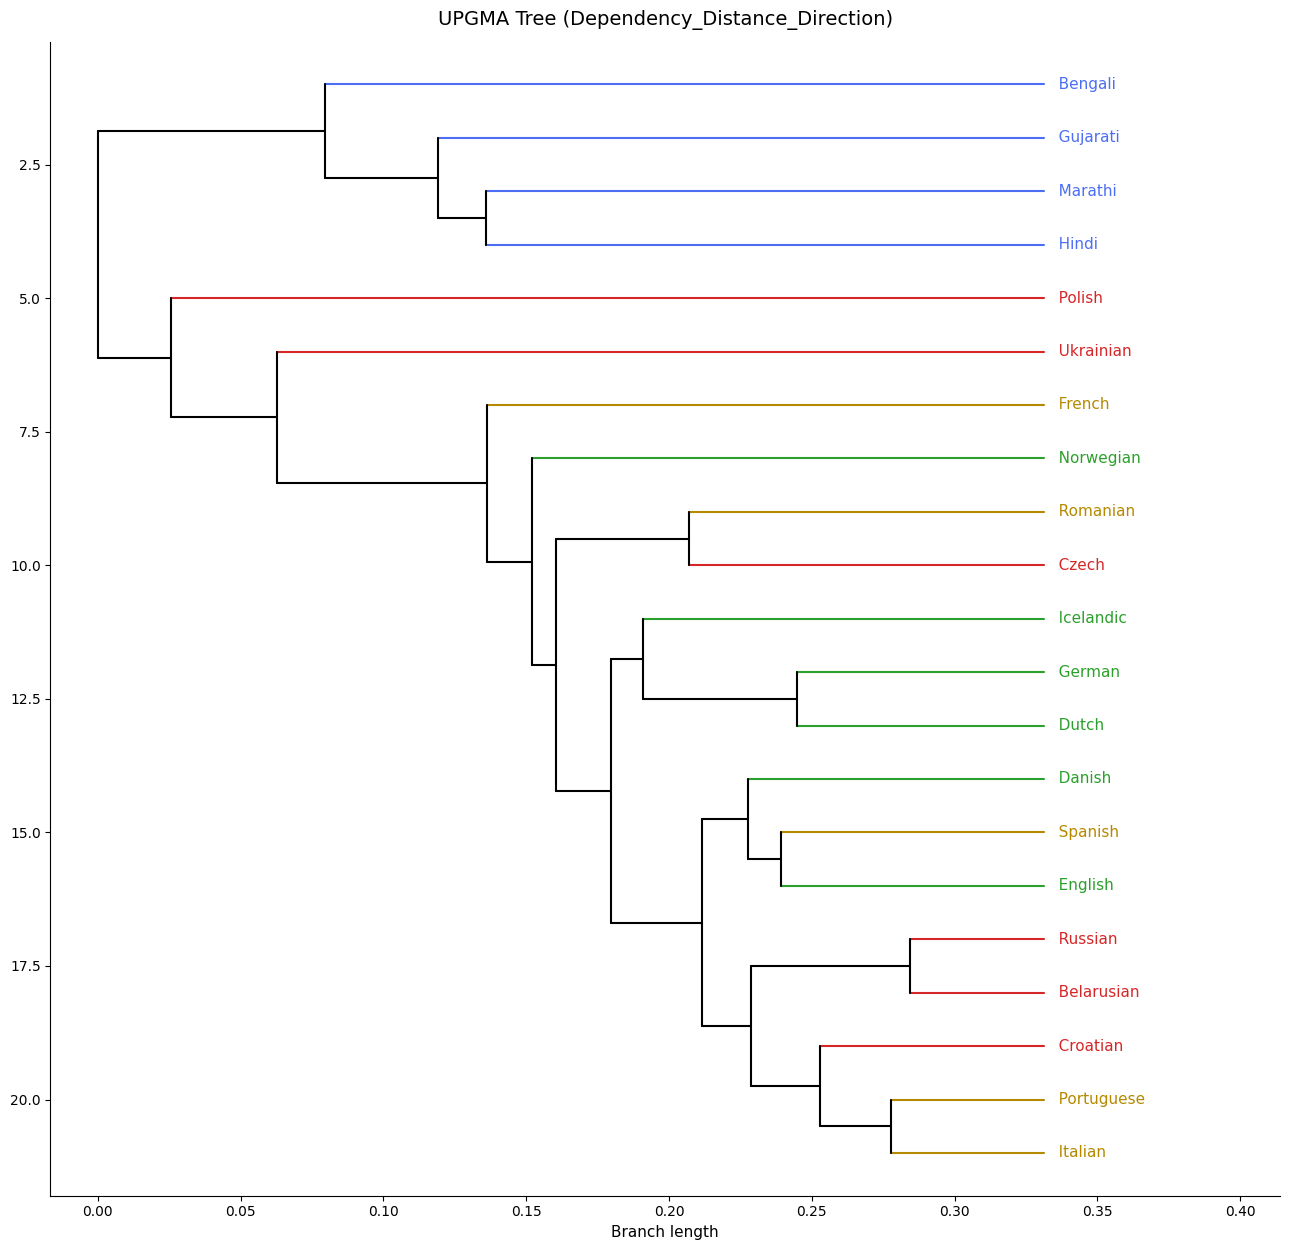

In [43]:
from collections import defaultdict
import numpy as np


all_deprels = set()

for lang, sentences in language_structures.items():
    for sentence in sentences:
        for token in sentence:
            deprel = token.get("deprel")
            if deprel is not None:
                all_deprels.add(deprel)


all_deprels = sorted(all_deprels)

print("Dependency relations:", all_deprels)
print("Number of dependency relations:", len(all_deprels))



language_vectors_deprel_distance_direction = {}

for lang, sentences in language_structures.items():
    signed_distances = defaultdict(list)
    abs_distances = defaultdict(list)

    for sentence in sentences:
        for token in sentence:
            deprel = token.get("deprel")
            token_id = token.get("id")
            head = token.get("head")

            # skip unusable tokens
            if deprel is None or token_id is None or head is None:
                continue

            # skip root, because head = 0 is artificial
            if head == 0:
                continue

            signed_dist = head - token_id
            abs_dist = abs(signed_dist)

            signed_distances[deprel].append(signed_dist)
            abs_distances[deprel].append(abs_dist)

    vector = []

    for rel in all_deprels:
        # mean signed distance
        if len(signed_distances[rel]) > 0:
            mean_signed = np.mean(signed_distances[rel])
        else:
            mean_signed = 0.0

        # mean absolute distance
        if len(abs_distances[rel]) > 0:
            mean_abs = np.mean(abs_distances[rel])
        else:
            mean_abs = 0.0

        vector.append(mean_signed)
        vector.append(mean_abs)

    
    language_vectors_deprel_distance_direction[lang] = np.array([vector])



print("Embedding size:", len(all_deprels) * 2)

for lang, vec in language_vectors_deprel_distance_direction.items():
    print(lang, vec.shape)
    print(vec)
    break

nj_tree_deprel_dist_dir, upgma_tree_deprel_dist_dir = build_tree_mean_cos_distance(language_vectors_deprel_distance_direction, method_name = "Dependency_Distance_Direction")


                       Method Vector Size  NJ Similarity  UPGMA Similarity
                  Word Length          11         0.1143            0.2286
            Top-50 Word Ranks          50         0.0571            0.0571
              Trigram Overlap         N/A         0.5714            0.5143
                     Word2Vec         100         0.4000            0.4571
               Word2Vec + PCA          34         0.5143            0.4571
           Unaligned FastText         300         0.4000            0.4571
                     POS Tags          19         0.2857            0.2778
         Dependency Relations         131         0.1714            0.3429
                 POS + DepRel         150         0.1714            0.4000
              POS Transitions         361         0.4000            0.5556
           DepRel Transitions       17161         0.4000            0.3429
DepRel + Distance + Direction         262         0.1143            0.1714


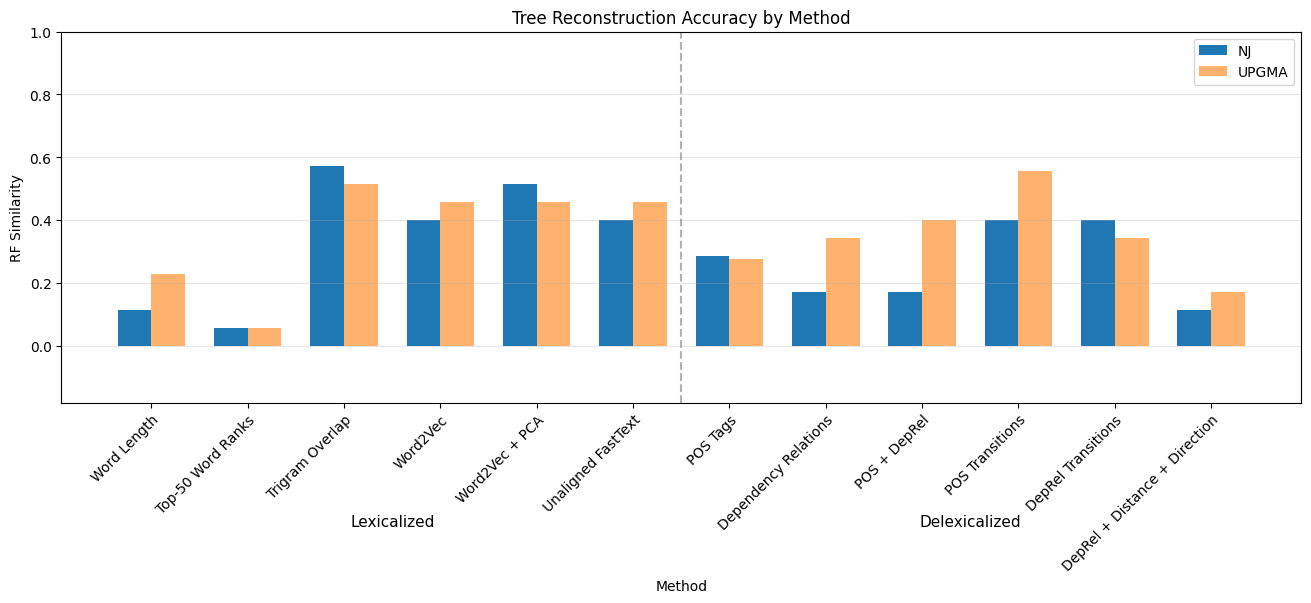

In [44]:
def get_vector_size(d):
    first = list(d.keys())[0]
    v = d[first]
    return v.shape[1] if len(v.shape) > 1 else v.shape[0]


vector_sizes = {
    "Word Length": get_vector_size(language_vectors_word_length),
    "Top-50 Word Ranks": get_vector_size(language_vectors_top50_rankfreq),
    "Trigram Overlap": "N/A",
    "Word2Vec": get_vector_size(language_vectors_word2vec),
    "Word2Vec + PCA": get_vector_size(lang_word2vec_pca_vectors),
    "POS Tags": get_vector_size(language_vectors_pos),
    "Dependency Relations": get_vector_size(language_vectors_deprel),
    "POS + DepRel": get_vector_size(language_vectors_pos_deprel),
    "POS Transitions": get_vector_size(language_vectors_pos_transitions),
    "DepRel Transitions": get_vector_size(language_vectors_deprel_transitions),
    "DepRel + Distance + Direction": get_vector_size(language_vectors_deprel_distance_direction),
    "Unaligned FastText": get_vector_size(language_vectors_unaligned_fasttext)
}

methods = [
    ("Word Length", nj_tree_word_length, upgma_tree_word_length),
    ("Top-50 Word Ranks", nj_tree_top50, upgma_tree_top50),
    ("Trigram Overlap", nj_tree_trigram_overlap, upgma_tree_trigram_overlap),
    ("Word2Vec", nj_tree_word2vec, upgma_tree_word2vec),
    ("Word2Vec + PCA", nj_tree_pca, upgma_tree_pca),
    ("POS Tags", nj_tree_pos, upgma_tree_pos),
    ("Dependency Relations", nj_tree_deprel, upgma_tree_deprel),
    ("POS + DepRel", nj_tree_pos_deprel, upgma_tree_pos_deprel),
    ("POS Transitions", nj_tree_pos_transitions, upgma_tree_pos_transitions),
    ("DepRel Transitions", nj_tree_deprel_transitions, upgma_tree_deprel_transitions),
    ("DepRel + Distance + Direction", nj_tree_deprel_dist_dir, upgma_tree_deprel_dist_dir),
    ("Unaligned FastText", nj_tree_unaligned_ft, upgma_tree_unaligned_ft)
]

rows = []

for name, nj_tree, upgma_tree in methods:
    try:
        nj = compare_trees(nj_tree, ground_truth_tree)
        upgma = compare_trees(upgma_tree, ground_truth_tree)

        rows.append({
            "Method": name,
            "Vector Size": vector_sizes[name],
            "NJ Similarity": round(1 - nj["normalized_rf"], 4),
            "UPGMA Similarity": round(1 - upgma["normalized_rf"], 4),
        })
    except:
        rows.append({
            "Method": name,
            "Vector Size": vector_sizes[name],
            "NJ Similarity": np.nan,
            "UPGMA Similarity": np.nan,
        })

df = pd.DataFrame(rows)

lexicalized = [
    "Word Length",
    "Top-50 Word Ranks",
    "Trigram Overlap",
    "Word2Vec",
    "Word2Vec + PCA",
    "Unaligned FastText"
]

method_order = lexicalized + [m for m in df["Method"].tolist() if m not in lexicalized]
df["Method"] = pd.Categorical(df["Method"], categories=method_order, ordered=True)
df = df.sort_values("Method").reset_index(drop=True)

print(df.to_string(index=False))

x = np.arange(len(df))
width = 0.35

fig, ax = plt.subplots(figsize=(16, 7))

ax.bar(x - width/2, df["NJ Similarity"], width, label="NJ")
ax.bar(x + width/2, df["UPGMA Similarity"], width, alpha=0.6, label="UPGMA")

ax.set_xticks(x)
ax.set_xticklabels(df["Method"], rotation=45, ha="right", rotation_mode="anchor")
ax.set_ylabel("RF Similarity")
ax.set_xlabel("Method")
ax.set_title("Tree Reconstruction Accuracy by Method")
ax.set_ylim(-0.18, 1)
ax.grid(axis="y", alpha=0.3)
ax.legend()

n_lex = len(lexicalized)
lex_center = (n_lex - 1) / 2
delex_center = n_lex + (len(df) - n_lex - 1) / 2

ax.text(lex_center, -0.3, "Lexicalized", ha="center", va="top",
        transform=ax.get_xaxis_transform(), fontsize=11)
ax.text(delex_center, -0.3, "Delexicalized", ha="center", va="top",
        transform=ax.get_xaxis_transform(), fontsize=11)

ax.axvline(n_lex - 0.5, color="gray", linestyle="--", alpha=0.6)

fig.subplots_adjust(bottom=0.35)
fig.savefig("tree_comparison.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

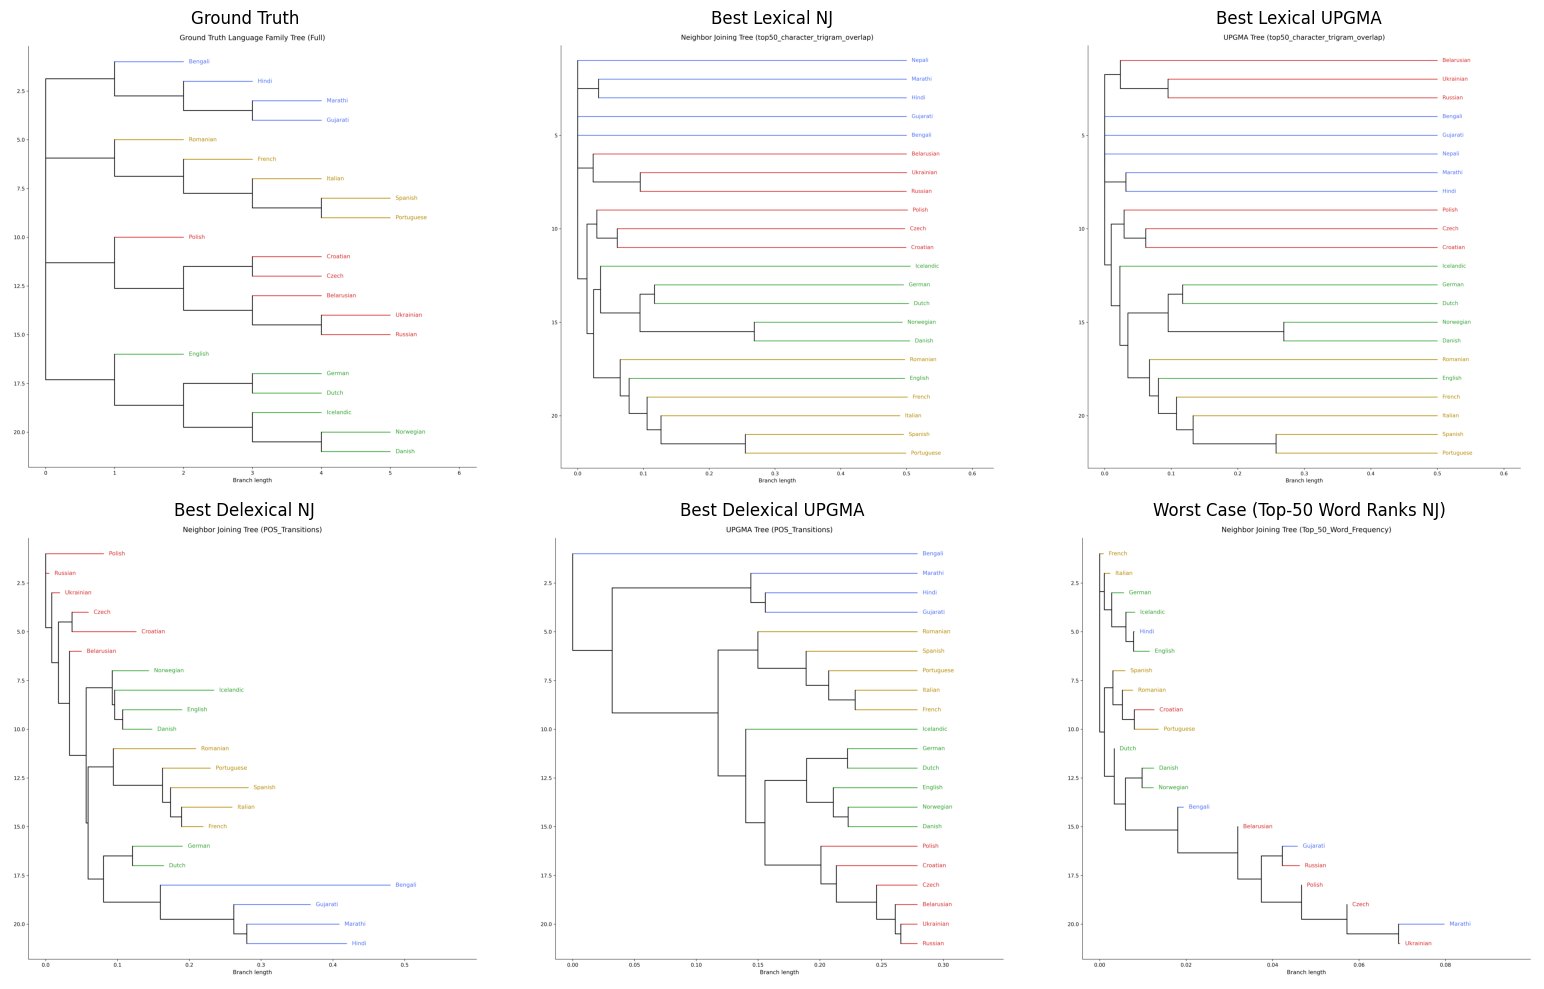

In [45]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

base = "tree_outputs"

paths = {
    "Ground Truth": "ground_truth_full.png",
    "Best Lexical NJ": os.path.join(base, "top50_character_trigram_overlap/top50_character_trigram_overlap_nj.png"),
    "Best Lexical UPGMA": os.path.join(base, "top50_character_trigram_overlap/top50_character_trigram_overlap_upgma.png"),
    "Best Delexical NJ": os.path.join(base, "POS_Transitions/POS_Transitions_nj.png"),
    "Best Delexical UPGMA": os.path.join(base, "POS_Transitions/POS_Transitions_upgma.png"),
    "Worst Case (Top-50 Word Ranks NJ)": os.path.join(base, "Top_50_Word_Frequency/Top_50_Word_Frequency_nj.png"),
}

fig, axes = plt.subplots(2, 3, figsize=(16, 10))

titles = list(paths.keys())
images = list(paths.values())

for ax, title, img_path in zip(axes.flatten(), titles, images):
    if os.path.exists(img_path):
        img = mpimg.imread(img_path)
        ax.imshow(img)
    ax.set_title(title, fontsize=12)
    ax.axis("off")

plt.tight_layout()
plt.savefig("figure2_tree_comparison.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

CLOSEST AND FARTHEST PAIRS

In [46]:


# reusing existing dist_df from each method

def closest_farthest(dist_df):
    df = dist_df.copy()
    # mask diagonal
    df = df.mask(np.eye(len(df), dtype=bool))
    
    min_idx = np.unravel_index(np.nanargmin(df.values), df.shape)
    max_idx = np.unravel_index(np.nanargmax(df.values), df.shape)
    
    closest = (df.index[min_idx[0]], df.columns[min_idx[1]], round(df.values[min_idx], 4))
    farthest = (df.index[max_idx[0]], df.columns[max_idx[1]], round(df.values[max_idx], 4))
    
    print(f"Closest:  {closest[0]} — {closest[1]} (distance: {closest[2]})")
    print(f"Farthest: {farthest[0]} — {farthest[1]} (distance: {farthest[2]})")
    return closest, farthest

WITHIN VS BETWEEN SUBFAMILY DISTANCES

In [47]:


def within_vs_between(dist_df, family_map):
    within, between = [], []
    langs = [l for l in dist_df.index if l in family_map]
    
    for i, l1 in enumerate(langs):
        for j, l2 in enumerate(langs):
            if i >= j:
                continue
            d = dist_df.loc[l1, l2]
            if family_map[l1] == family_map[l2]:
                within.append(d)
            else:
                between.append(d)
    w, b = round(float(np.mean(within)), 4), round(float(np.mean(between)), 4)
    ratio = round(b / w, 4) if w > 0 else 0
    print(f"Avg within-subfamily distance:  {round(np.mean(within), 4)}")
    print(f"Avg between-subfamily distance: {round(np.mean(between), 4)}")
    print(f"Separation ratio (between/within): {round(np.mean(between)/np.mean(within), 4)}")
    return w, b, ratio

In [48]:


dist_matrices = {}

for method_name, vecs in {
    "Word Length Frequency" :    language_vectors_word_length,
    "Word2Vec (PCA)":            lang_word2vec_pca_vectors,
    "Word2Vec":                  language_vectors_word2vec,
    "Unaligned FastText":        language_vectors_unaligned_fasttext,
    "POS Frequency":             language_vectors_pos,
    "Deprel Frequency":          language_vectors_deprel,
    "POS + Deprel":              language_vectors_pos_deprel,
    "POS Transitions":           language_vectors_pos_transitions,
    "Deprel Transitions":        language_vectors_deprel_transitions,
    "Deprel Distance Direction": language_vectors_deprel_distance_direction,
    "Top 50 Word Frequency":     language_vectors_top50_rankfreq
    


}.items():
    means, valid = clean_compute_mean(vecs)
    dist_df = build_cos_sim_matrix(means, valid)
    dist_matrices[method_name] = dist_df

Languages used: ['Ukrainian', 'Polish', 'Portuguese', 'Croatian', 'Italian', 'Norwegian', 'Spanish', 'English', 'Russian', 'Czech', 'Marathi', 'Romanian', 'Icelandic', 'Hindi', 'Bengali', 'German', 'Danish', 'Gujarati', 'French', 'Dutch', 'Belarusian']

Cosine Similarity:
            Ukrainian  Polish  Portuguese  Croatian  Italian  Norwegian  \
Ukrainian       1.000   1.000       0.999     1.000    0.999      0.999   
Polish          1.000   1.000       0.999     1.000    0.999      0.999   
Portuguese      0.999   0.999       1.000     0.999    1.000      0.999   
Croatian        1.000   1.000       0.999     1.000    0.999      0.999   
Italian         0.999   0.999       1.000     0.999    1.000      0.999   
Norwegian       0.999   0.999       0.999     0.999    0.999      1.000   
Spanish         0.999   0.999       1.000     0.999    1.000      1.000   
English         0.999   0.999       0.999     0.999    0.999      1.000   
Russian         1.000   1.000       0.999     1.000 

In [49]:
# ---- CLOSEST AND FARTHEST PAIRS ----

for method, dist_df in dist_matrices.items():
    print(f"\n{method}:")
    closest_farthest(dist_df)


Word Length Frequency:
Closest:  Norwegian — Danish (distance: 0.0)
Farthest: Bengali — Belarusian (distance: 0.0037)

Word2Vec (PCA):
Closest:  Norwegian — Danish (distance: 0.010999999940395355)
Farthest: Polish — French (distance: 1.4930000305175781)

Word2Vec:
Closest:  Norwegian — Danish (distance: 0.004800000227987766)
Farthest: Croatian — Icelandic (distance: 0.9954000115394592)

Unaligned FastText:
Closest:  Norwegian — Danish (distance: 0.0005000000237487257)
Farthest: Russian — Dutch (distance: 0.6169000267982483)

POS Frequency:
Closest:  Russian — Ukrainian (distance: 0.001)
Farthest: Hindi — Marathi (distance: 0.472)

Deprel Frequency:
Closest:  Russian — Ukrainian (distance: 0.0097)
Farthest: Bengali — Hindi (distance: 0.5189)

POS + Deprel:
Closest:  Russian — Ukrainian (distance: 0.0043)
Farthest: Hindi — Marathi (distance: 0.4415)

POS Transitions:
Closest:  Russian — Ukrainian (distance: 0.0266)
Farthest: Bengali — Hindi (distance: 0.6332)

Deprel Transitions:
Closes

In [50]:
for method, dist_df in dist_matrices.items():
    print(f"\n{method}:")
    within_vs_between(dist_df, family_map)


Word Length Frequency:
Avg within-subfamily distance:  0.0004
Avg between-subfamily distance: 0.0012
Separation ratio (between/within): 3.2364

Word2Vec (PCA):
Avg within-subfamily distance:  0.6952000260353088
Avg between-subfamily distance: 1.132200002670288
Separation ratio (between/within): 1.6288000345230103

Word2Vec:
Avg within-subfamily distance:  0.44690001010894775
Avg between-subfamily distance: 0.7056000232696533
Separation ratio (between/within): 1.5789999961853027

Unaligned FastText:
Avg within-subfamily distance:  0.14000000059604645
Avg between-subfamily distance: 0.36399999260902405
Separation ratio (between/within): 2.600399971008301

POS Frequency:
Avg within-subfamily distance:  0.0673
Avg between-subfamily distance: 0.1298
Separation ratio (between/within): 1.9293

Deprel Frequency:
Avg within-subfamily distance:  0.0847
Avg between-subfamily distance: 0.1727
Separation ratio (between/within): 2.0386

POS + Deprel:
Avg within-subfamily distance:  0.0746
Avg betwe

COLLECTING RESULTS FOR PLOTTING (closest furthest and within-between)

In [51]:

methods, within_vals, between_vals, ratios = [], [], [], []
closest_data, farthest_data = [], []

for method, dist_df in dist_matrices.items():
    print(f"\n{method}:")
    closest, farthest = closest_farthest(dist_df)
    w, b, ratio = within_vs_between(dist_df, family_map)
    
    methods.append(method)
    within_vals.append(w)
    between_vals.append(b)
    ratios.append(ratio)
    closest_data.append((method, f"{closest[0]}–{closest[1]}", float(closest[2])))
    farthest_data.append((method, f"{farthest[0]}–{farthest[1]}", float(farthest[2])))


Word Length Frequency:
Closest:  Norwegian — Danish (distance: 0.0)
Farthest: Bengali — Belarusian (distance: 0.0037)
Avg within-subfamily distance:  0.0004
Avg between-subfamily distance: 0.0012
Separation ratio (between/within): 3.2364

Word2Vec (PCA):
Closest:  Norwegian — Danish (distance: 0.010999999940395355)
Farthest: Polish — French (distance: 1.4930000305175781)
Avg within-subfamily distance:  0.6952000260353088
Avg between-subfamily distance: 1.132200002670288
Separation ratio (between/within): 1.6288000345230103

Word2Vec:
Closest:  Norwegian — Danish (distance: 0.004800000227987766)
Farthest: Croatian — Icelandic (distance: 0.9954000115394592)
Avg within-subfamily distance:  0.44690001010894775
Avg between-subfamily distance: 0.7056000232696533
Separation ratio (between/within): 1.5789999961853027

Unaligned FastText:
Closest:  Norwegian — Danish (distance: 0.0005000000237487257)
Farthest: Russian — Dutch (distance: 0.6169000267982483)
Avg within-subfamily distance:  0.140

WITHIN VS BETWEEN+SEPARATION RATIO PLOT

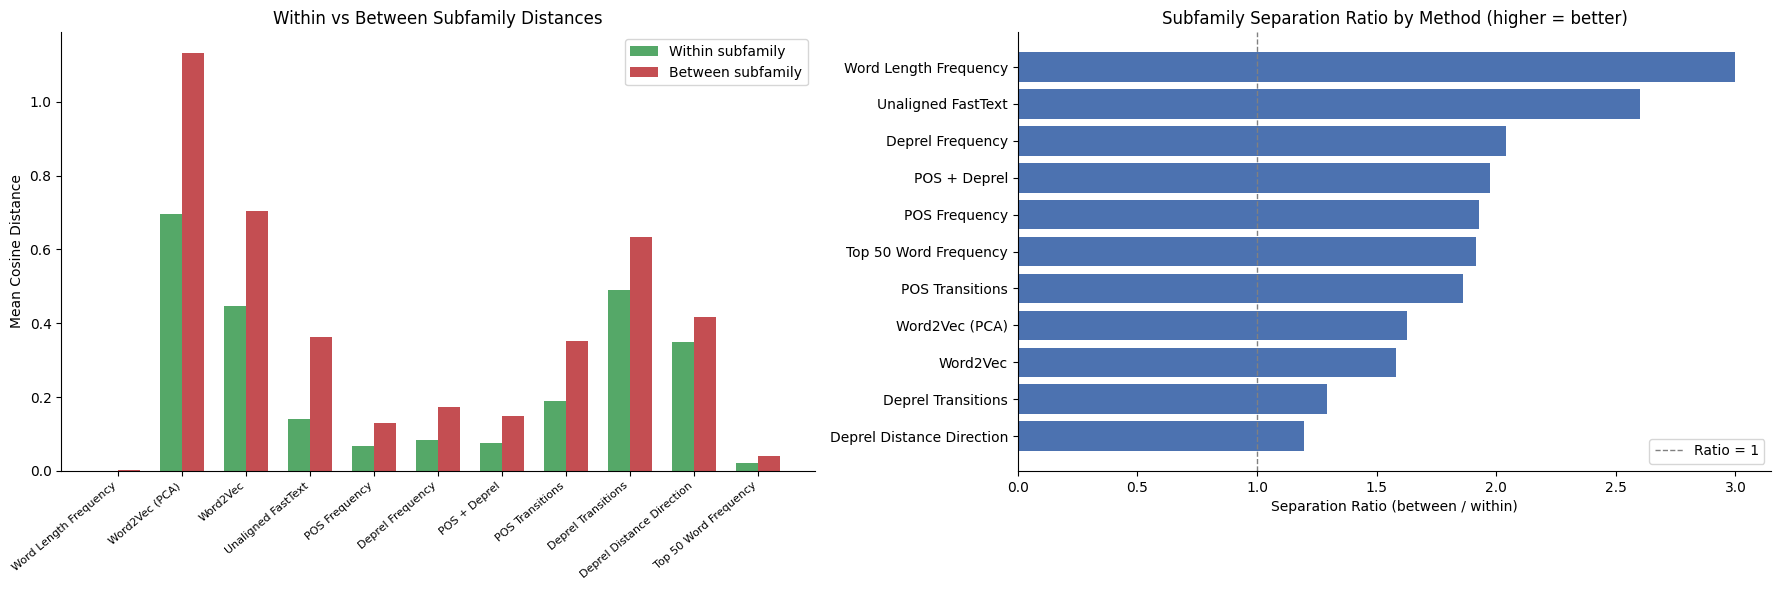

In [52]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

x = np.arange(len(methods))
width = 0.35
axes[0].bar(x - width/2, within_vals,  width, label="Within subfamily",  color="#55A868")
axes[0].bar(x + width/2, between_vals, width, label="Between subfamily", color="#C44E52")
axes[0].set_xticks(x)
axes[0].set_xticklabels(methods, rotation=40, ha="right", fontsize=8)
axes[0].set_ylabel("Mean Cosine Distance")
axes[0].set_title("Within vs Between Subfamily Distances")
axes[0].legend()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

sorted_idx     = np.argsort(ratios)[::-1]
sorted_methods = [methods[i] for i in sorted_idx]
sorted_ratios  = [ratios[i] for i in sorted_idx]

axes[1].barh(sorted_methods, sorted_ratios, color="#4C72B0")
axes[1].axvline(1.0, color="gray", linestyle="--", linewidth=1, label="Ratio = 1")
axes[1].set_xlabel("Separation Ratio (between / within)")
axes[1].set_title("Subfamily Separation Ratio by Method (higher = better)")
axes[1].legend()
axes[1].invert_yaxis()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("within_between_analysis.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

CLOSEST FARTHEST PAIRS PLOT

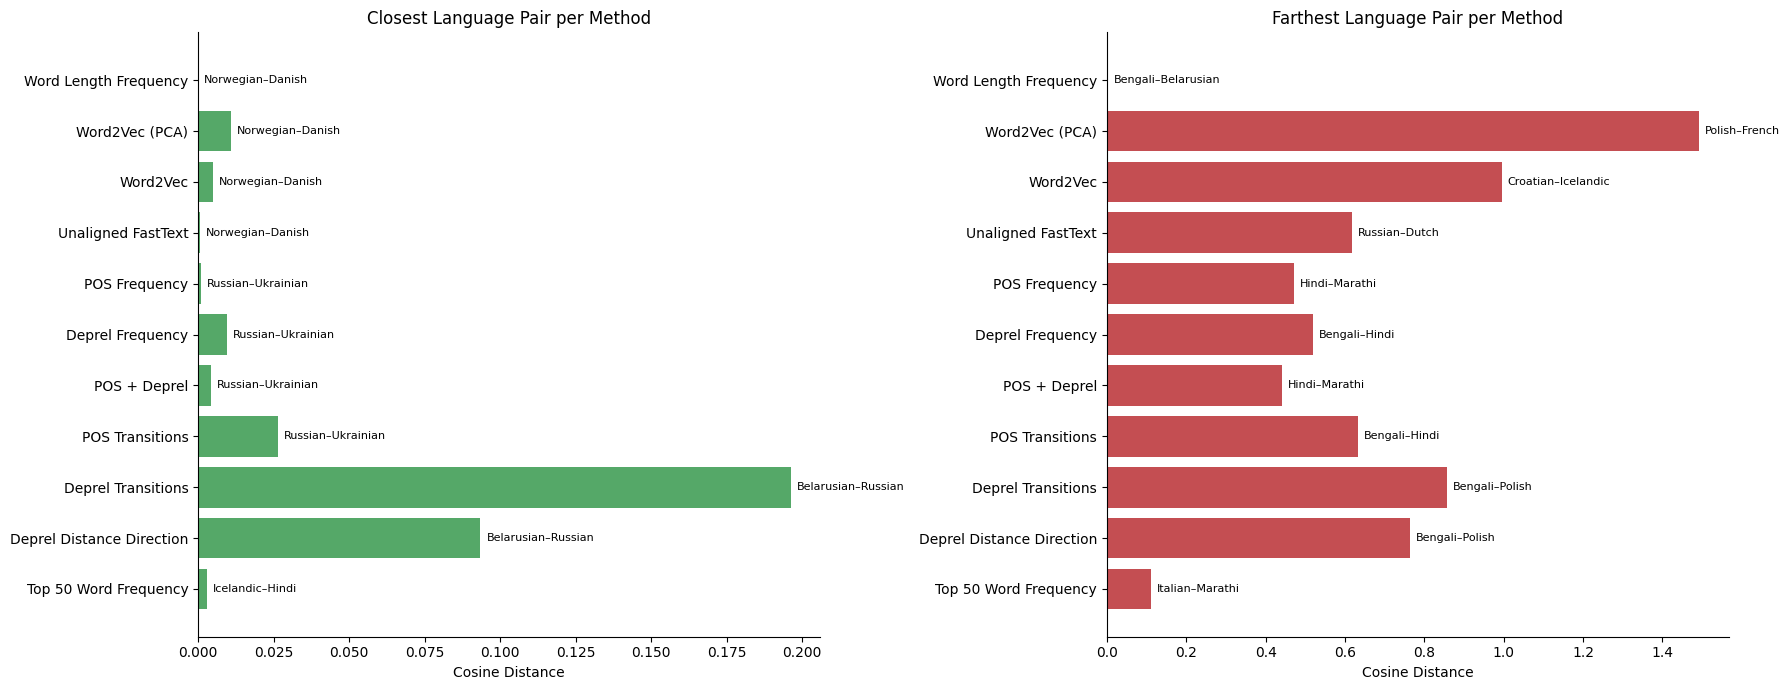

In [53]:
#print(closest_data[0])
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

c_methods = [r[0] for r in closest_data]
c_labels  = [r[1] for r in closest_data]
c_dists   = [float(r[2]) for r in closest_data]

bars = axes[0].barh(c_methods, c_dists, color="#55A868")
for bar, label in zip(bars, c_labels):
    axes[0].text(bar.get_width() + max(c_dists)*0.01, bar.get_y() + bar.get_height()/2,
                 label, va="center", fontsize=8)
axes[0].set_xlabel("Cosine Distance")
axes[0].set_title("Closest Language Pair per Method")
axes[0].invert_yaxis()
axes[0].spines["top"].set_visible(False)
axes[0].spines["right"].set_visible(False)

f_methods = [r[0] for r in farthest_data]
f_labels  = [r[1] for r in farthest_data]
f_dists   = [float(r[2]) for r in farthest_data]

bars = axes[1].barh(f_methods, f_dists, color="#C44E52")
for bar, label in zip(bars, f_labels):
    axes[1].text(bar.get_width() + max(f_dists)*0.01, bar.get_y() + bar.get_height()/2,
                 label, va="center", fontsize=8)
axes[1].set_xlabel("Cosine Distance")
axes[1].set_title("Farthest Language Pair per Method")
axes[1].invert_yaxis()
axes[1].spines["top"].set_visible(False)
axes[1].spines["right"].set_visible(False)

plt.tight_layout()
plt.savefig("closest_farthest_pairs.png", dpi=300, bbox_inches="tight", facecolor="white")
plt.show()

In [ ]:

import graphviz
from graphviz import Digraph

dot = Digraph("pipeline", format="png")
dot.attr(rankdir="LR", splines="ortho", nodesep="0.35", ranksep="0.7", dpi="300")
dot.attr("node", shape="box", style="rounded,filled", fontname="Helvetica", fontsize="11", margin="0.15,0.08")
dot.attr("edge", color="#666666", arrowsize="0.8")

dot.node("A", "Input\nMultilingual Language Data", fillcolor="#E8F1FB", color="#4C78A8")

dot.node(
    "B",
    "Lexicalized\n\n"
    "• Word Length\n"
    "• Top-50 Word Ranks\n"
    "• Trigram Similarities\n"
    "• Word2Vec\n"
    "• Word2Vec + PCA\n"
    "• Unaligned FastText",
    fillcolor="#DDF2DD",
    color="#55A868"
)

dot.node(
    "C",
    "Delexicalized\n\n"
    "• POS Tags\n"
    "• Dependency Relations\n"
    "• POS + Dependency Relations\n"
    "• POS Transitions\n"
    "• Dependency Relation Transitions\n"
    "• Dependency Distance and Direction",
    fillcolor="#FCE8C3",
    color="#C98E1C"
)

dot.node("D", "Language-Level Representation", fillcolor="#F3E8FB", color="#9C6ACF")
dot.node("E", "Distance Matrix\nCosine Distance", fillcolor="#F9E3E3", color="#D65F5F")
dot.node("F", "Neighbor Joining", fillcolor="#E6F4EA", color="#4E9F6D")
dot.node("G", "UPGMA", fillcolor="#E6F4EA", color="#4E9F6D")
dot.node("H", "Phylogenetic Trees", fillcolor="#E8F1FB", color="#4C78A8")
dot.node("I", "Ground Truth Tree", fillcolor="#EFEFEF", color="#7A7A7A")

dot.node(
    "J",
    "Evaluation\n\n"
    "• RF Similarity\n"
    "• Closest and Farthest Language Pair\n"
    "• Average Within- vs Between-Subfamily Distance",
    fillcolor="#FDECC8",
    color="#D4A017"
)

dot.edge("A", "B")
dot.edge("A", "C")
dot.edge("B", "D")
dot.edge("C", "D")
dot.edge("D", "E")
dot.edge("E", "F")
dot.edge("E", "G")
dot.edge("F", "H")
dot.edge("G", "H")
dot.edge("H", "J")
dot.edge("I", "J")


dot.render("pipeline_figure", format="png", cleanup=True)
dot.render("pipeline_figure", format="svg", cleanup=True)